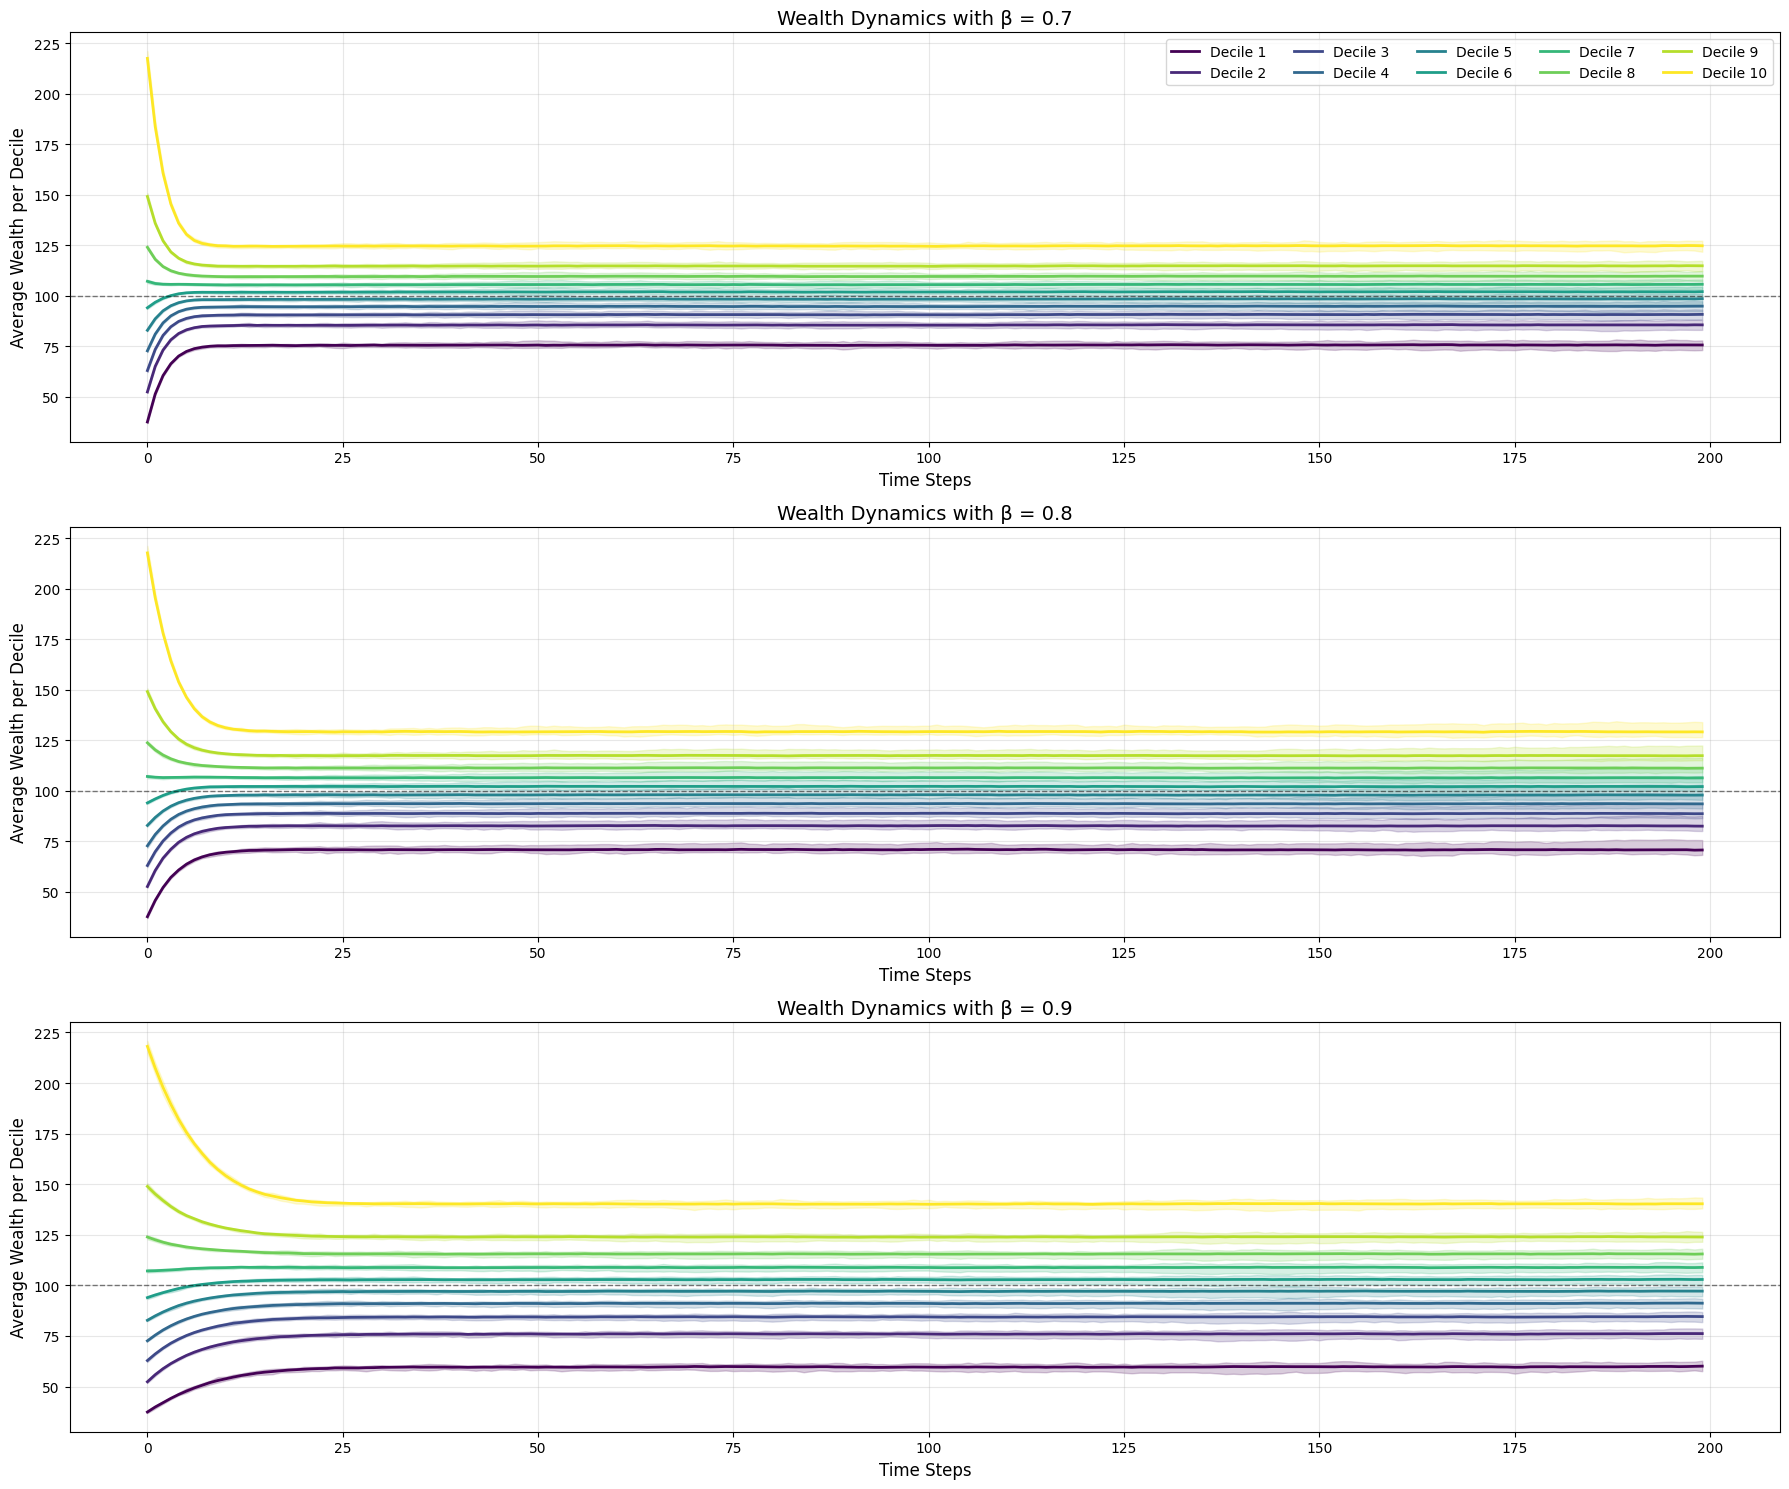

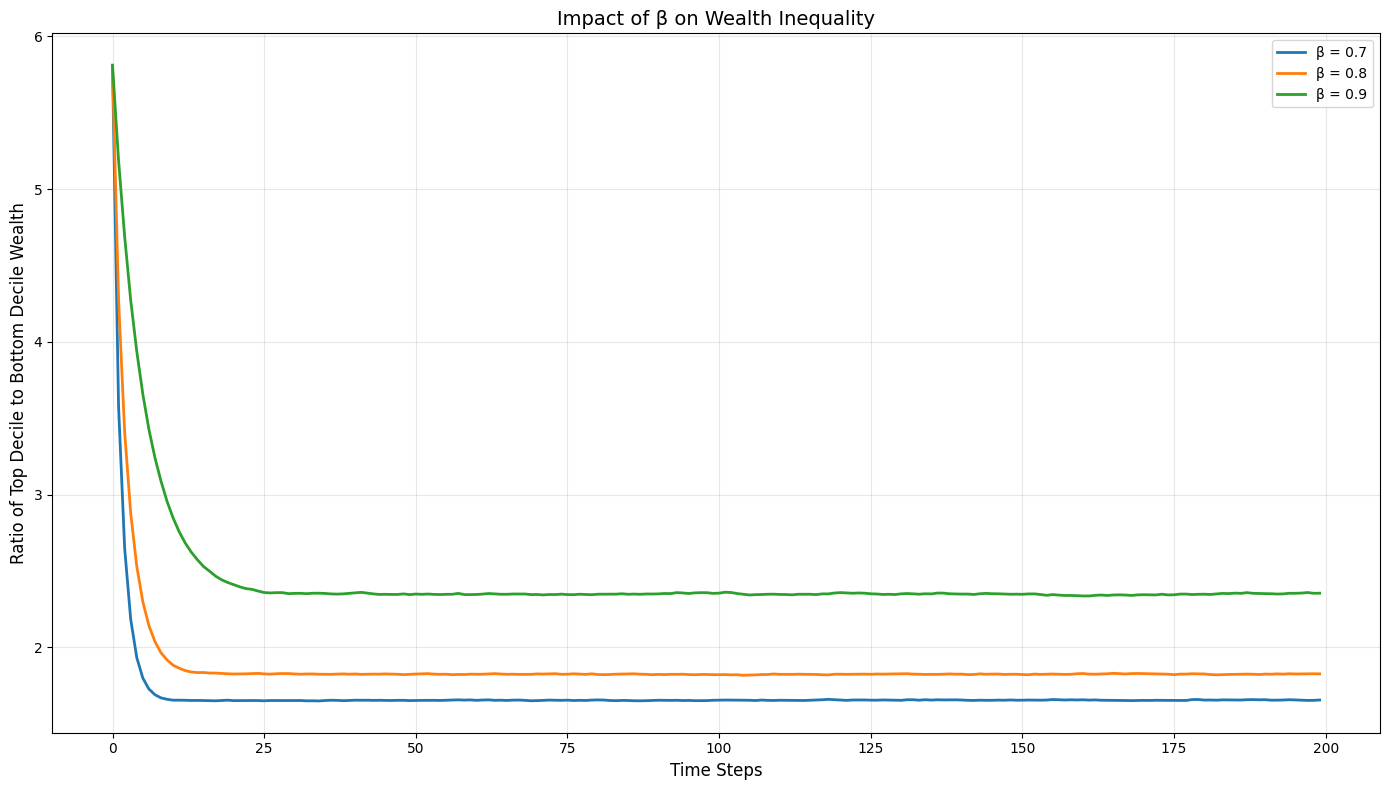

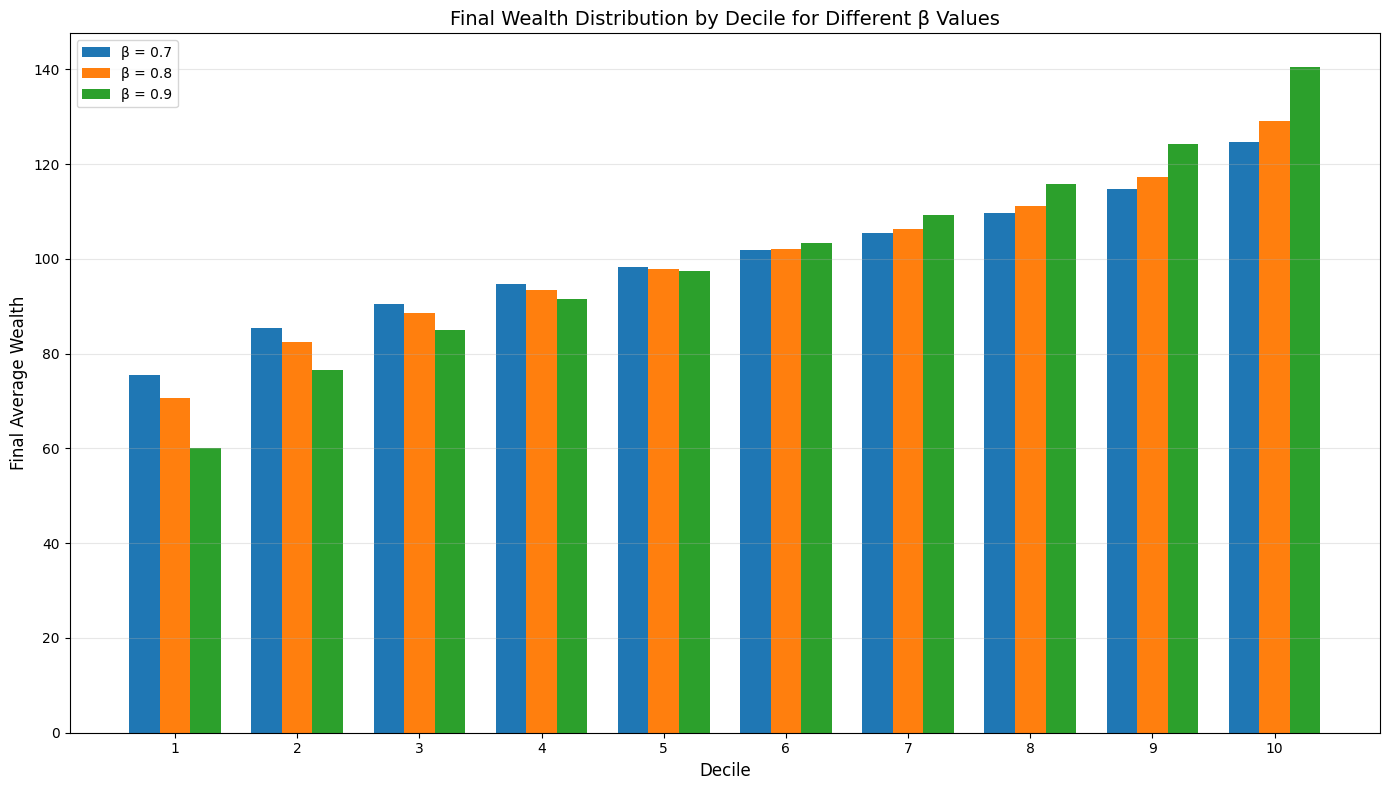

In [2]:
import numpy as np
import matplotlib.pyplot as plt

# Simulation parameters
n_agents = 10000  # number of agents
n_deciles = 10  # number of deciles to track
n_timesteps = 200  # number of iterations
n_runs = 20  # number of simulation runs
initial_wealth_mean = 100  # average initial wealth
epsilon_sigma = 10  # standard deviation for random shocks
beta_values = [0.7, 0.8, 0.9]  # retention rates to simulate

# Function to run a single simulation with a specific beta value
def run_simulation(beta, n_runs, n_agents, n_timesteps, initial_wealth_mean, epsilon_sigma):
    # Arrays to store decile wealth over time for all runs
    all_decile_wealth = np.zeros((n_runs, n_timesteps, n_deciles))
    
    for run in range(n_runs):
        # Initialize wealth with lognormal distribution (avg = initial_wealth_mean)
        wealth = np.random.lognormal(mean=np.log(initial_wealth_mean), sigma=0.5, size=n_agents)
        
        # Make sure average wealth is exactly initial_wealth_mean
        wealth = wealth * (initial_wealth_mean / wealth.mean())
        
        # Track decile wealth over time
        decile_wealth = np.zeros((n_timesteps, n_deciles))
        
        # Calculate initial decile wealth
        decile_indices = np.array([int(i * n_agents / n_deciles) for i in range(n_deciles + 1)])
        sorted_indices = np.argsort(wealth)
        
        for t in range(n_timesteps):
            # Calculate average wealth
            avg_wealth = wealth.mean()
            
            # Calculate current decile wealth (need to sort each time as agents may change deciles)
            sorted_indices = np.argsort(wealth)
            sorted_wealth = wealth[sorted_indices]
            
            for d in range(n_deciles):
                start_idx = decile_indices[d]
                end_idx = decile_indices[d + 1]
                decile_wealth[t, d] = sorted_wealth[start_idx:end_idx].mean()
            
            # Generate random shocks
            epsilon = np.random.normal(0, epsilon_sigma, n_agents)
            
            # Update wealth for next time step: W_i(t+1) = β W_i(t) + (1-β) W̄_t + ε_i
            wealth = beta * wealth + (1 - beta) * avg_wealth + epsilon
        
        all_decile_wealth[run] = decile_wealth
    
    return all_decile_wealth

# Plot the results for each beta value
plt.figure(figsize=(18, 15))

for idx, beta in enumerate(beta_values):
    # Run simulation for this beta
    all_decile_wealth = run_simulation(
        beta, n_runs, n_agents, n_timesteps, initial_wealth_mean, epsilon_sigma
    )
    
    # Calculate mean, min, and max for each decile across all runs
    mean_decile_wealth = np.mean(all_decile_wealth, axis=0)
    min_decile_wealth = np.min(all_decile_wealth, axis=0)
    max_decile_wealth = np.max(all_decile_wealth, axis=0)
    
    # Plot results for this beta value
    plt.subplot(len(beta_values), 1, idx + 1)
    
    # Plot each decile with different colors
    colors = plt.cm.viridis(np.linspace(0, 1, n_deciles))
    
    for d in range(n_deciles):
        plt.plot(mean_decile_wealth[:, d], 
                 label=f'Decile {d+1}', 
                 color=colors[d], 
                 linewidth=2)
        
        plt.fill_between(range(n_timesteps), 
                         min_decile_wealth[:, d], 
                         max_decile_wealth[:, d], 
                         color=colors[d], 
                         alpha=0.2)
    
    plt.xlabel('Time Steps', fontsize=12)
    plt.ylabel('Average Wealth per Decile', fontsize=12)
    plt.title(f'Wealth Dynamics with β = {beta}', fontsize=14)
    plt.grid(True, alpha=0.3)
    
    # Only show legend on the first subplot to save space
    if idx == 0:
        plt.legend(loc='upper right', fontsize=10, ncol=5)
    
    # Add horizontal line for initial average wealth
    plt.axhline(y=initial_wealth_mean, color='black', linestyle='--', linewidth=1, alpha=0.5)

plt.tight_layout()
plt.savefig('wealth_dynamics_by_decile.png')
plt.show()

# Create separate plot to compare the impact of beta on wealth inequality
plt.figure(figsize=(14, 8))

# Track top and bottom decile ratio over time for each beta
for beta in beta_values:
    all_decile_wealth = run_simulation(
        beta, n_runs, n_agents, n_timesteps, initial_wealth_mean, epsilon_sigma
    )
    
    mean_decile_wealth = np.mean(all_decile_wealth, axis=0)
    
    # Calculate ratio of top decile to bottom decile
    ratio = mean_decile_wealth[:, -1] / mean_decile_wealth[:, 0]
    
    plt.plot(ratio, label=f'β = {beta}', linewidth=2)

plt.xlabel('Time Steps', fontsize=12)
plt.ylabel('Ratio of Top Decile to Bottom Decile Wealth', fontsize=12)
plt.title('Impact of β on Wealth Inequality', fontsize=14)
plt.legend(loc='best', fontsize=10)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('wealth_inequality_ratio.png')
plt.show()

# Create a third plot showing final wealth distribution across deciles for each beta
plt.figure(figsize=(14, 8))

x = np.arange(n_deciles)
width = 0.25  # Width of bars

for i, beta in enumerate(beta_values):
    all_decile_wealth = run_simulation(
        beta, n_runs, n_agents, n_timesteps, initial_wealth_mean, epsilon_sigma
    )
    
    mean_decile_wealth = np.mean(all_decile_wealth, axis=0)
    
    # Get the final wealth distribution
    final_wealth = mean_decile_wealth[-1, :]
    
    # Plot as bars with different positions
    plt.bar(x + i*width - width, final_wealth, width, label=f'β = {beta}')

plt.xlabel('Decile', fontsize=12)
plt.ylabel('Final Average Wealth', fontsize=12)
plt.title('Final Wealth Distribution by Decile for Different β Values', fontsize=14)
plt.xticks(x, [f'{d+1}' for d in range(n_deciles)])
plt.legend(loc='best', fontsize=10)
plt.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.savefig('final_wealth_distribution.png')
plt.show()

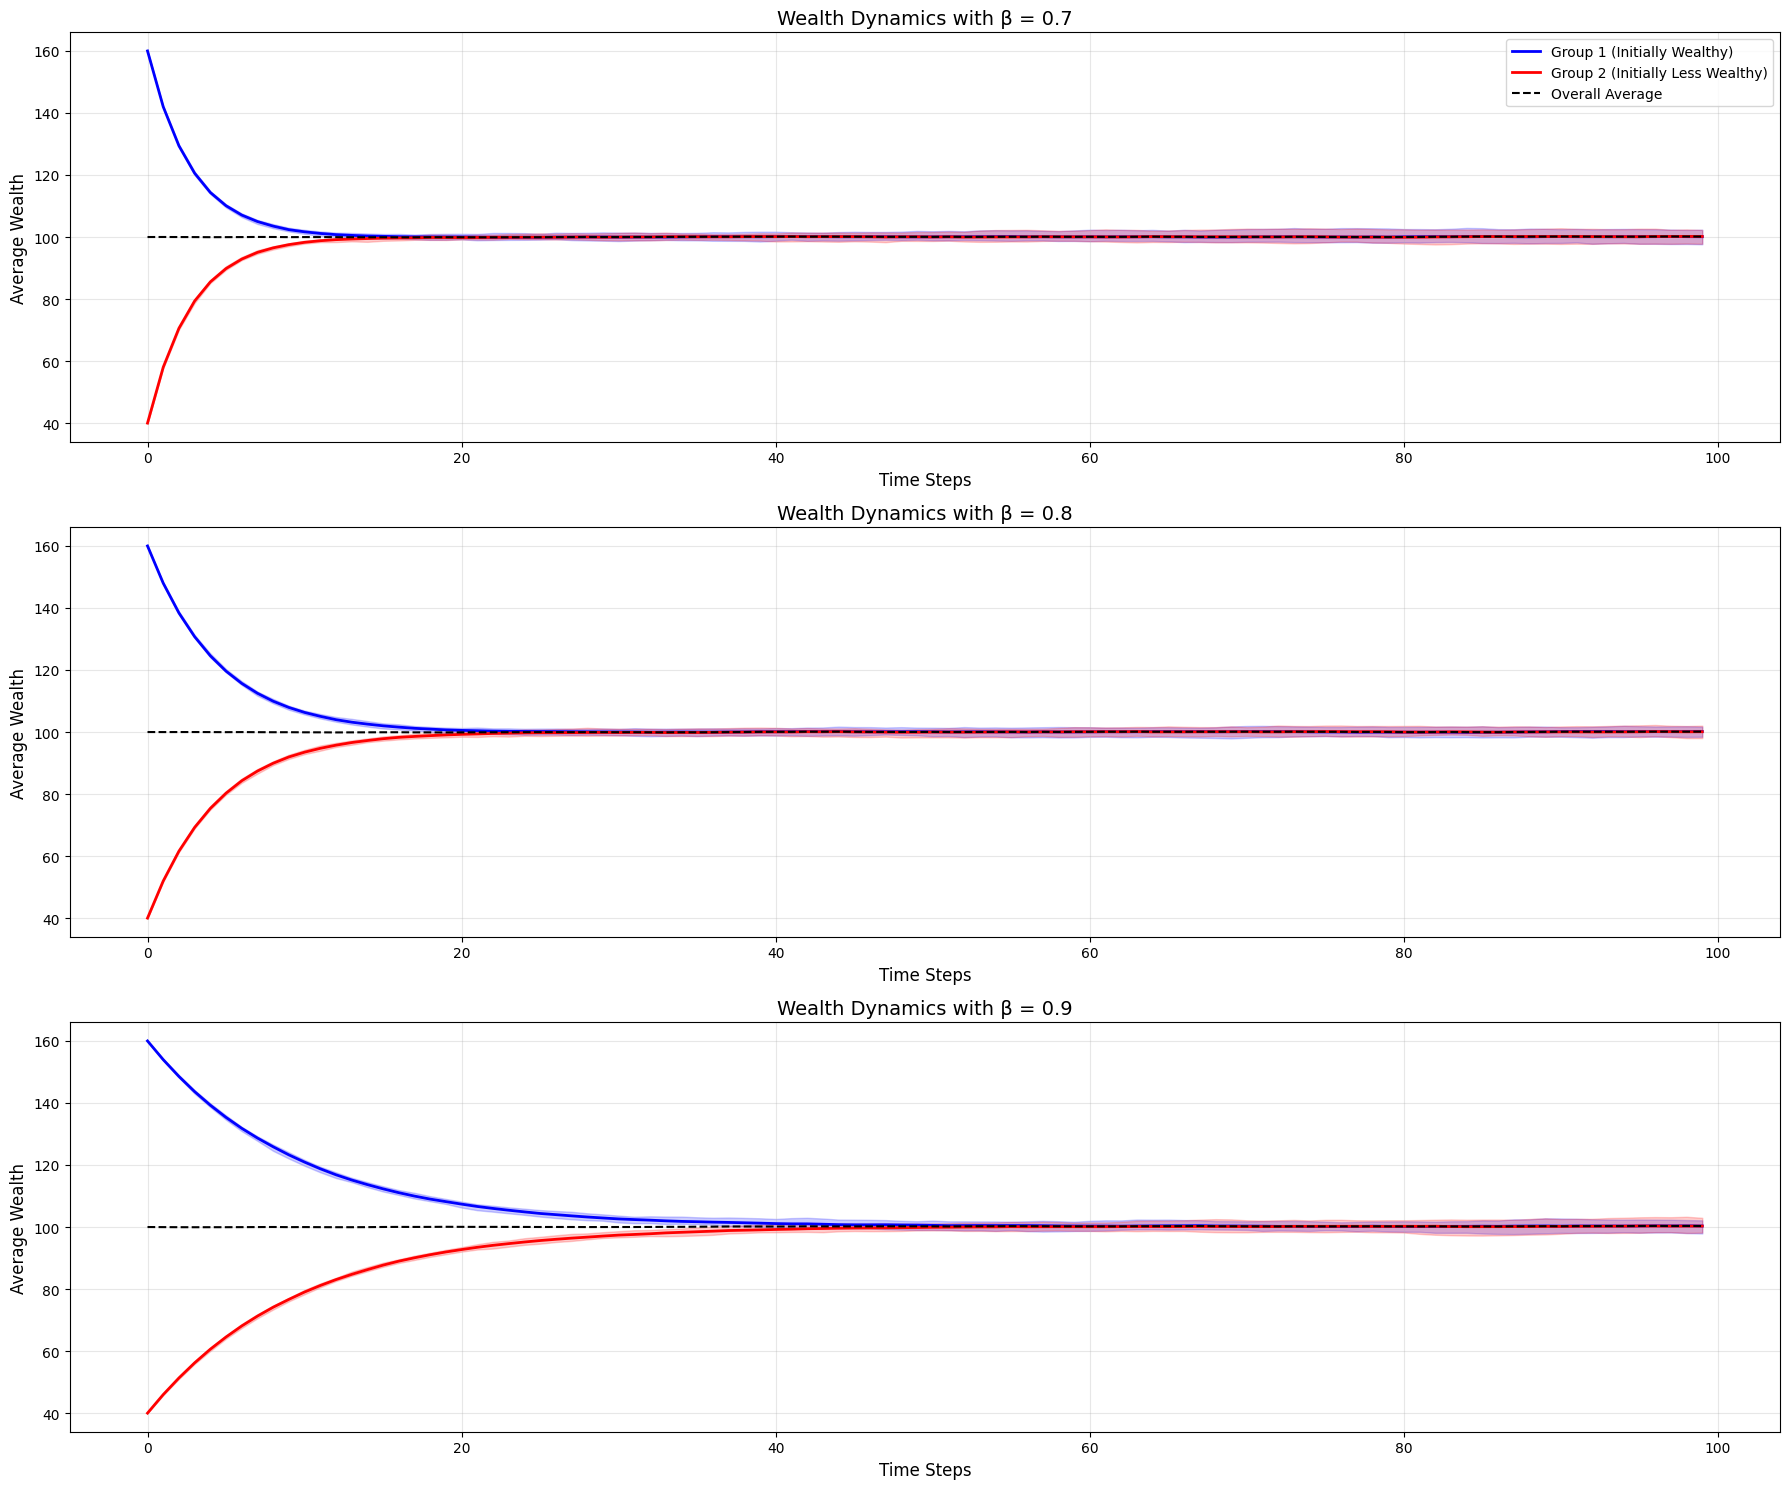

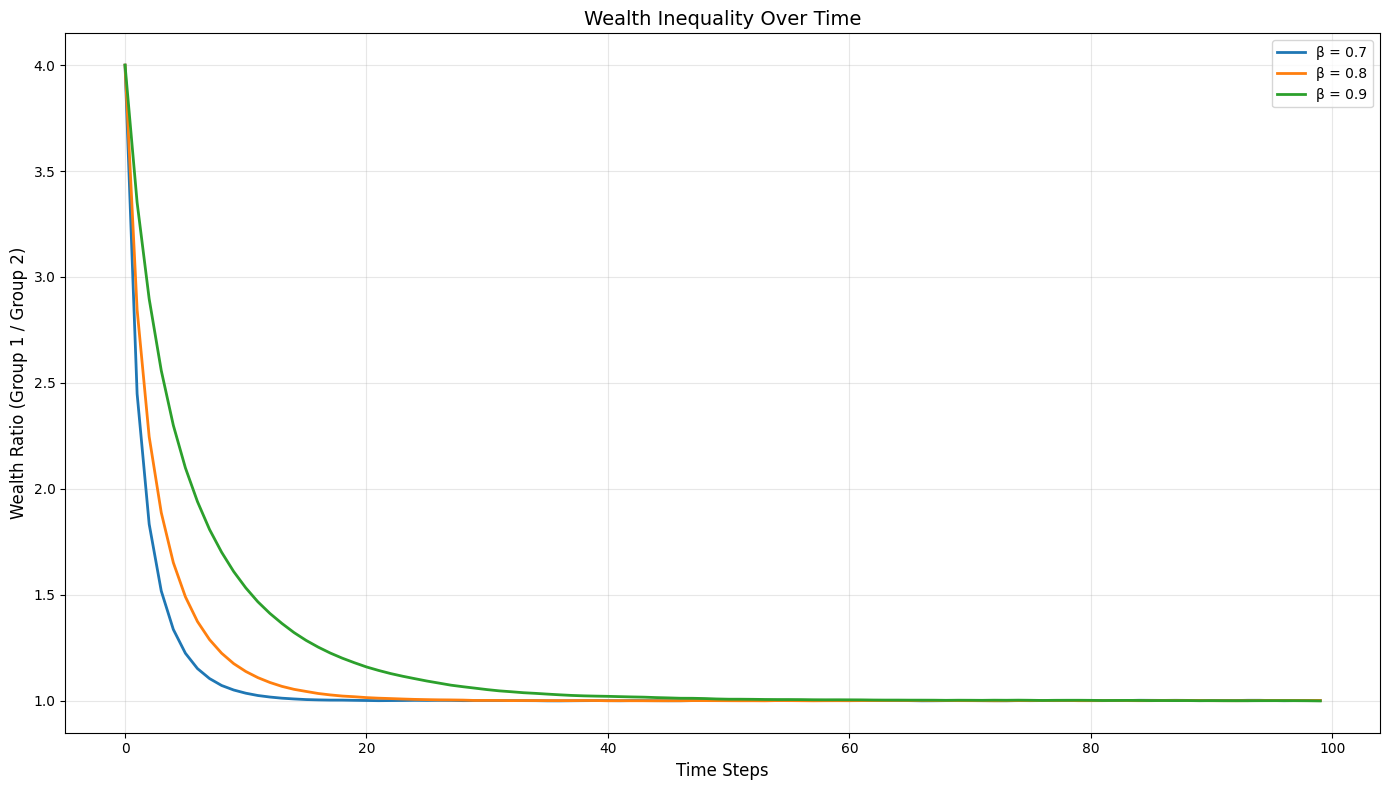

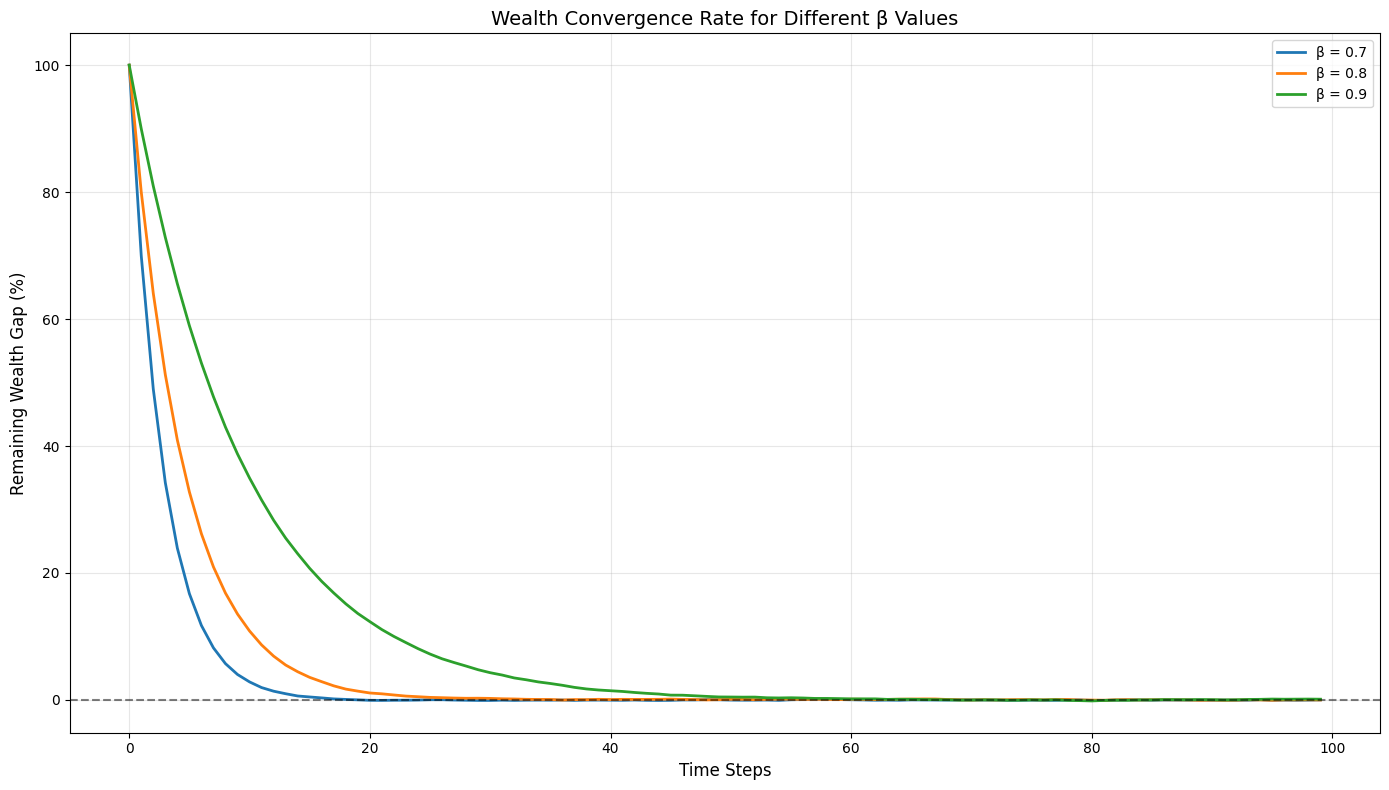

Half-life of wealth gap (time steps):
β = 0.7: 2 time steps
β = 0.8: 4 time steps
β = 0.9: 7 time steps


In [3]:
import numpy as np
import matplotlib.pyplot as plt

# Simulation parameters
n_agents = 10000  # total number of agents
n_timesteps = 100  # number of iterations
n_runs = 20  # number of simulation runs
initial_wealth_mean = 100  # average initial wealth
epsilon_sigma = 10  # standard deviation for random shocks
beta_values = [0.7, 0.8, 0.9]  # retention rates to simulate

# Function to run a single simulation with a specific beta value
def run_simulation(beta, n_runs, n_agents, n_timesteps, initial_wealth_mean, epsilon_sigma):
    # Arrays to store group wealth over time for all runs
    all_group1_wealth = np.zeros((n_runs, n_timesteps))
    all_group2_wealth = np.zeros((n_runs, n_timesteps))
    all_avg_wealth = np.zeros((n_runs, n_timesteps))
    
    for run in range(n_runs):
        # Initialize two groups with different wealth
        # Group 1: twice the average wealth
        # Group 2: half the average wealth (ensuring overall average is still 100)
        n_group1 = n_agents // 2
        n_group2 = n_agents - n_group1
        
        # Calculate initial wealth to maintain overall average of initial_wealth_mean
        # If group 1 has 2x average and group 2 has 0.5x average, with equal sizes
        # Then (2x + 0.5x)/2 = initial_wealth_mean, solving for x
        x = 2 * initial_wealth_mean / 2.5
        
        wealth = np.zeros(n_agents)
        wealth[:n_group1] = 2 * x  # Group 1: twice the reference value
        wealth[n_group1:] = 0.5 * x  # Group 2: half the reference value
        
        # Verify average is close to initial_wealth_mean
        assert abs(wealth.mean() - initial_wealth_mean) < 0.01
        
        # Keep track of original group membership for tracking
        group1_indices = np.arange(n_group1)
        group2_indices = np.arange(n_group1, n_agents)
        
        # Arrays to store group wealth over time
        group1_wealth = np.zeros(n_timesteps)
        group2_wealth = np.zeros(n_timesteps)
        avg_wealth = np.zeros(n_timesteps)
        
        for t in range(n_timesteps):
            # Record current group averages
            group1_wealth[t] = wealth[group1_indices].mean()
            group2_wealth[t] = wealth[group2_indices].mean()
            avg_wealth[t] = wealth.mean()
            
            # Generate random shocks
            epsilon = np.random.normal(0, epsilon_sigma, n_agents)
            
            # Update wealth for next time step: W_i(t+1) = β W_i(t) + (1-β) W̄_t + ε_i
            wealth = beta * wealth + (1 - beta) * avg_wealth[t] + epsilon
        
        all_group1_wealth[run] = group1_wealth
        all_group2_wealth[run] = group2_wealth
        all_avg_wealth[run] = avg_wealth
    
    return all_group1_wealth, all_group2_wealth, all_avg_wealth

# Plot the results for each beta value
plt.figure(figsize=(18, 15))

for idx, beta in enumerate(beta_values):
    # Run simulation for this beta
    all_group1_wealth, all_group2_wealth, all_avg_wealth = run_simulation(
        beta, n_runs, n_agents, n_timesteps, initial_wealth_mean, epsilon_sigma
    )
    
    # Calculate mean, min, and max for each group across all runs
    mean_group1_wealth = np.mean(all_group1_wealth, axis=0)
    min_group1_wealth = np.min(all_group1_wealth, axis=0)
    max_group1_wealth = np.max(all_group1_wealth, axis=0)
    
    mean_group2_wealth = np.mean(all_group2_wealth, axis=0)
    min_group2_wealth = np.min(all_group2_wealth, axis=0)
    max_group2_wealth = np.max(all_group2_wealth, axis=0)
    
    mean_avg_wealth = np.mean(all_avg_wealth, axis=0)
    
    # Plot results for this beta value
    plt.subplot(len(beta_values), 1, idx + 1)
    
    # Plot Group 1 (initially richer)
    plt.plot(mean_group1_wealth, 
             label='Group 1 (Initially Wealthy)', 
             color='blue', 
             linewidth=2)
    
    plt.fill_between(range(n_timesteps), 
                     min_group1_wealth, 
                     max_group1_wealth, 
                     color='blue', 
                     alpha=0.2)
    
    # Plot Group 2 (initially poorer)
    plt.plot(mean_group2_wealth, 
             label='Group 2 (Initially Less Wealthy)', 
             color='red', 
             linewidth=2)
    
    plt.fill_between(range(n_timesteps), 
                     min_group2_wealth, 
                     max_group2_wealth, 
                     color='red', 
                     alpha=0.2)
    
    # Plot average wealth
    plt.plot(mean_avg_wealth, 
             label='Overall Average', 
             color='black', 
             linestyle='--', 
             linewidth=1.5)
    
    plt.xlabel('Time Steps', fontsize=12)
    plt.ylabel('Average Wealth', fontsize=12)
    plt.title(f'Wealth Dynamics with β = {beta}', fontsize=14)
    plt.grid(True, alpha=0.3)
    
    # Only show legend on the first subplot to save space
    if idx == 0:
        plt.legend(loc='best', fontsize=10)

plt.tight_layout()
plt.savefig('wealth_dynamics_groups.png')
plt.show()

# Now create a plot showing the wealth ratio over time
plt.figure(figsize=(14, 8))

for beta in beta_values:
    all_group1_wealth, all_group2_wealth, _ = run_simulation(
        beta, n_runs, n_agents, n_timesteps, initial_wealth_mean, epsilon_sigma
    )
    
    mean_group1_wealth = np.mean(all_group1_wealth, axis=0)
    mean_group2_wealth = np.mean(all_group2_wealth, axis=0)
    
    # Calculate ratio of group 1 to group 2
    ratio = mean_group1_wealth / mean_group2_wealth
    
    plt.plot(ratio, label=f'β = {beta}', linewidth=2)

plt.xlabel('Time Steps', fontsize=12)
plt.ylabel('Wealth Ratio (Group 1 / Group 2)', fontsize=12)
plt.title('Wealth Inequality Over Time', fontsize=14)
plt.legend(loc='best', fontsize=10)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('wealth_ratio_over_time.png')
plt.show()

# Create a plot showing wealth convergence rate for different beta values
plt.figure(figsize=(14, 8))

# Calculate how quickly the groups converge for each beta value
convergence_data = []

for beta in beta_values:
    all_group1_wealth, all_group2_wealth, _ = run_simulation(
        beta, n_runs, n_agents, n_timesteps, initial_wealth_mean, epsilon_sigma
    )
    
    mean_group1_wealth = np.mean(all_group1_wealth, axis=0)
    mean_group2_wealth = np.mean(all_group2_wealth, axis=0)
    
    # Calculate percentage of initial gap that remains at each timestep
    initial_gap = mean_group1_wealth[0] - mean_group2_wealth[0]
    remaining_gap_pct = [(mean_group1_wealth[t] - mean_group2_wealth[t]) / initial_gap * 100 
                         for t in range(n_timesteps)]
    
    plt.plot(remaining_gap_pct, label=f'β = {beta}', linewidth=2)

plt.xlabel('Time Steps', fontsize=12)
plt.ylabel('Remaining Wealth Gap (%)', fontsize=12)
plt.title('Wealth Convergence Rate for Different β Values', fontsize=14)
plt.legend(loc='best', fontsize=10)
plt.grid(True, alpha=0.3)
plt.axhline(y=0, color='black', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.savefig('wealth_convergence_rate.png')
plt.show()

# Calculate and print the half-life of the wealth gap for each beta
print("Half-life of wealth gap (time steps):")
for beta in beta_values:
    all_group1_wealth, all_group2_wealth, _ = run_simulation(
        beta, 1, n_agents, n_timesteps, initial_wealth_mean, epsilon_sigma
    )
    
    initial_gap = all_group1_wealth[0, 0] - all_group2_wealth[0, 0]
    
    # Find first time when gap is less than half of initial
    for t in range(n_timesteps):
        current_gap = all_group1_wealth[0, t] - all_group2_wealth[0, t]
        if current_gap < initial_gap / 2:
            print(f"β = {beta}: {t} time steps")
            break

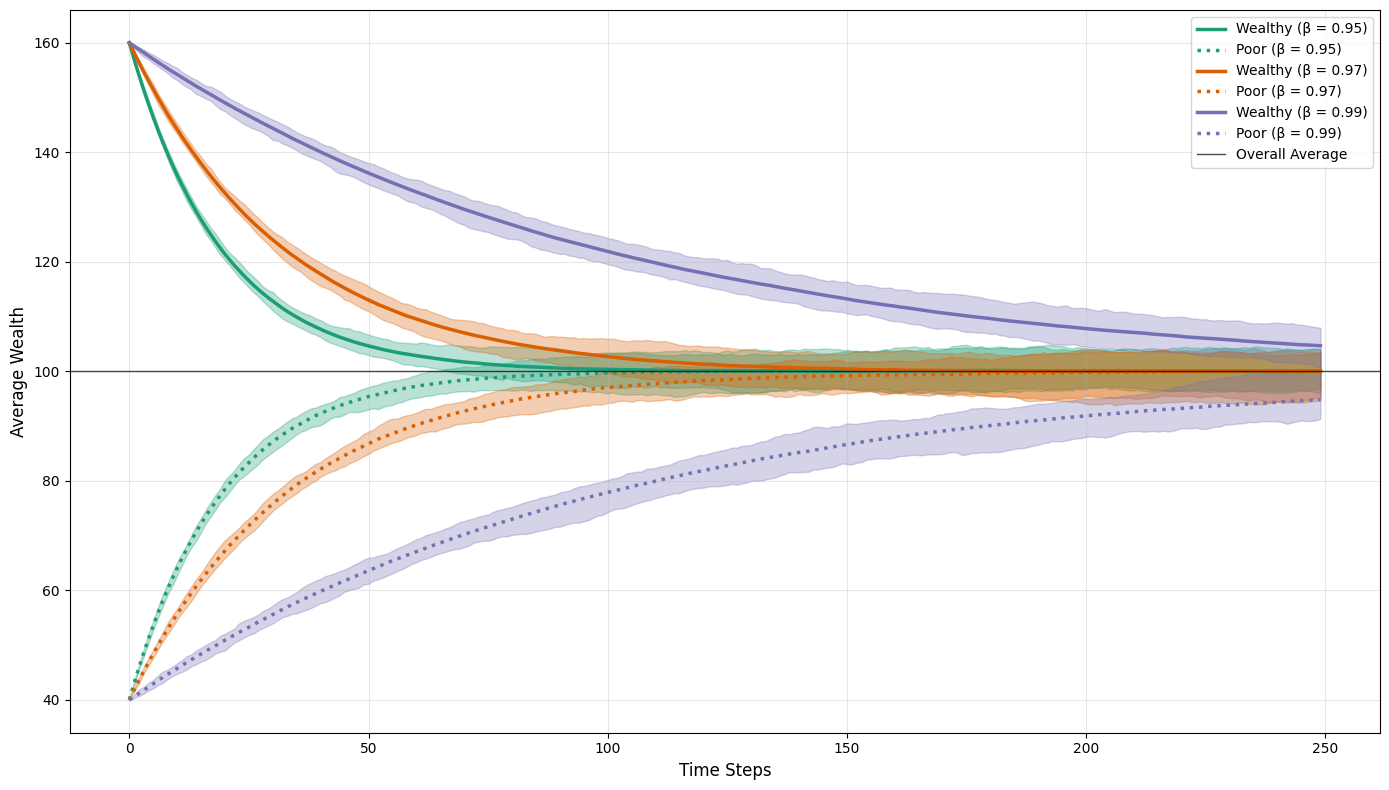

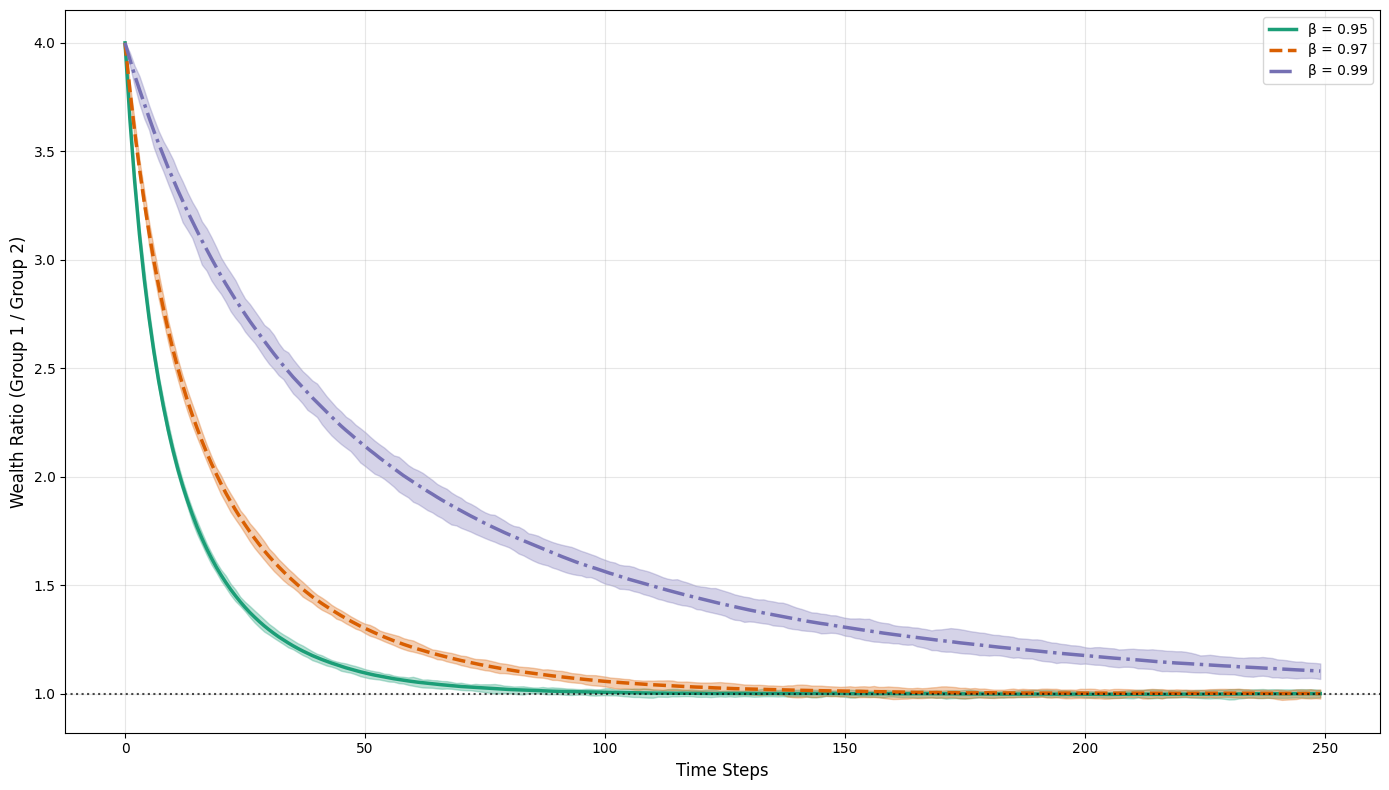

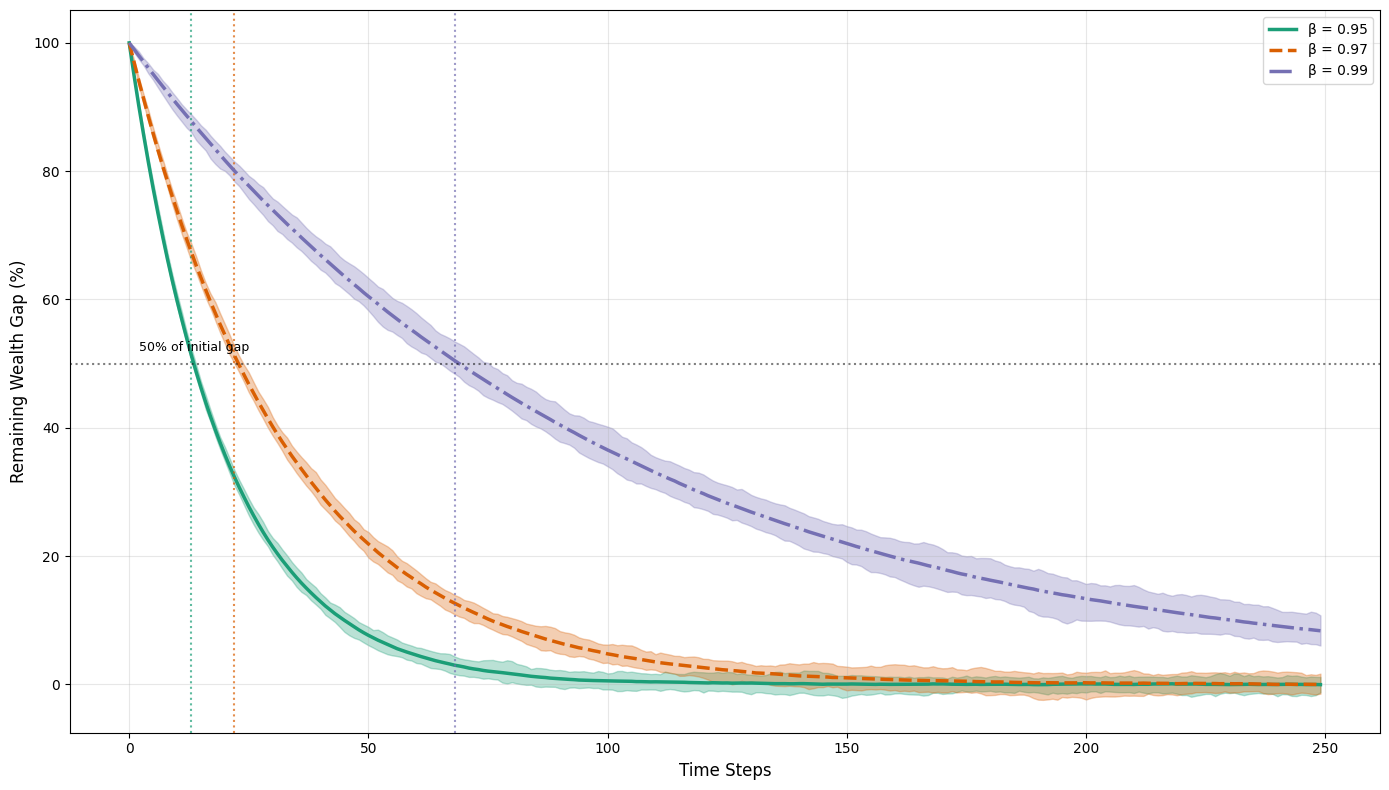

Wealth gap half-life comparison:
β	Theoretical	Observed
0.95	13.51		14
0.97	22.76		23
0.99	68.97		69


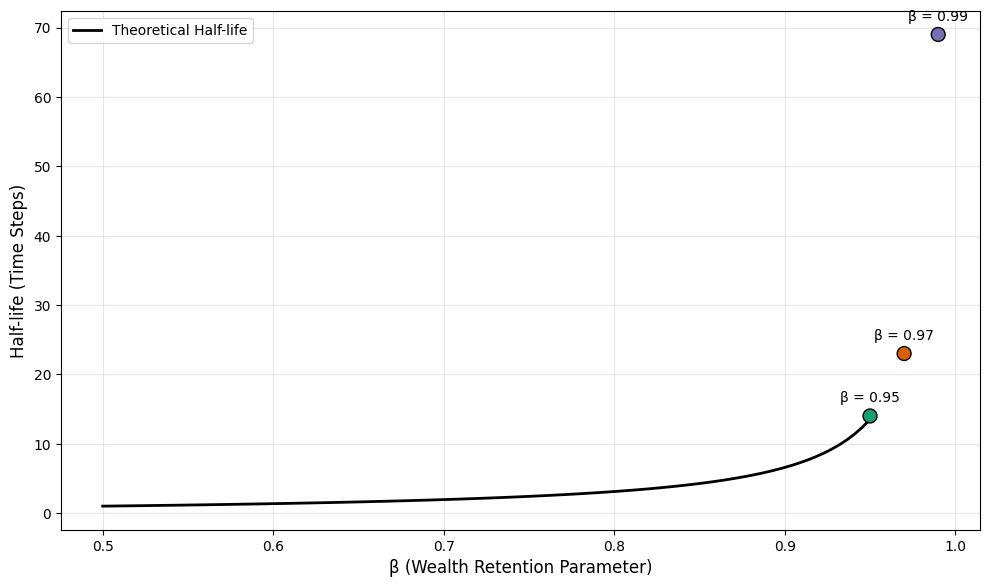

In [20]:
import numpy as np
import matplotlib.pyplot as plt

# Simulation parameters
n_agents = 10000  # total number of agents
n_timesteps = 250  # number of iterations
n_runs = 100  # number of simulation runs
initial_wealth_mean = 100  # average initial wealth
epsilon_sigma = 10  # standard deviation for random shocks
beta_values = [0.95, 0.97, .99]  # retention rates to simulate

# Function to run a single simulation with a specific beta value
def run_simulation(beta, n_runs, n_agents, n_timesteps, initial_wealth_mean, epsilon_sigma):
    # Arrays to store group wealth over time for all runs
    all_group1_wealth = np.zeros((n_runs, n_timesteps))
    all_group2_wealth = np.zeros((n_runs, n_timesteps))
    all_avg_wealth = np.zeros((n_runs, n_timesteps))
    
    for run in range(n_runs):
        # Initialize two groups with different wealth
        # Group 1: twice the average wealth
        # Group 2: half the average wealth (ensuring overall average is still 100)
        n_group1 = n_agents // 2
        n_group2 = n_agents - n_group1
        
        # Calculate initial wealth to maintain overall average of initial_wealth_mean
        # If group 1 has 2x average and group 2 has 0.5x average, with equal sizes
        # Then (2x + 0.5x)/2 = initial_wealth_mean, solving for x
        x = 2 * initial_wealth_mean / 2.5
        
        wealth = np.zeros(n_agents)
        wealth[:n_group1] = 2 * x  # Group 1: twice the reference value
        wealth[n_group1:] = 0.5 * x  # Group 2: half the reference value
        
        # Verify average is close to initial_wealth_mean
        assert abs(wealth.mean() - initial_wealth_mean) < 0.01
        
        # Keep track of original group membership for tracking
        group1_indices = np.arange(n_group1)
        group2_indices = np.arange(n_group1, n_agents)
        
        # Arrays to store group wealth over time
        group1_wealth = np.zeros(n_timesteps)
        group2_wealth = np.zeros(n_timesteps)
        avg_wealth = np.zeros(n_timesteps)
        
        for t in range(n_timesteps):
            # Record current group averages
            group1_wealth[t] = wealth[group1_indices].mean()
            group2_wealth[t] = wealth[group2_indices].mean()
            avg_wealth[t] = wealth.mean()
            
            # Generate random shocks
            epsilon = np.random.normal(0, epsilon_sigma, n_agents)
            
            # Update wealth for next time step: W_i(t+1) = β W_i(t) + (1-β) W̄_t + ε_i
            wealth = beta * wealth + (1 - beta) * avg_wealth[t] + epsilon
        
        all_group1_wealth[run] = group1_wealth
        all_group2_wealth[run] = group2_wealth
        all_avg_wealth[run] = avg_wealth
    
    return all_group1_wealth, all_group2_wealth, all_avg_wealth

# Plot the results for all beta values on a single graph
plt.figure(figsize=(14, 8))

# Define colors that work well in both color and grayscale printing
# Using blue, red, and green with different saturations for better distinction
colors = ['#1b9e77', '#d95f02', '#7570b3']  # colorblind-friendly palette

# Run simulations and plot for each beta value
for idx, beta in enumerate(beta_values):
    # Run simulation with more runs to better visualize variance
    all_group1_wealth, all_group2_wealth, all_avg_wealth = run_simulation(
        beta, n_runs, n_agents, n_timesteps, initial_wealth_mean, epsilon_sigma
    )
    
    # Calculate mean, min, and max for each group across all runs
    mean_group1_wealth = np.mean(all_group1_wealth, axis=0)
    min_group1_wealth = np.min(all_group1_wealth, axis=0)
    max_group1_wealth = np.max(all_group1_wealth, axis=0)
    
    mean_group2_wealth = np.mean(all_group2_wealth, axis=0)
    min_group2_wealth = np.min(all_group2_wealth, axis=0)
    max_group2_wealth = np.max(all_group2_wealth, axis=0)
    
    # Plot Wealthy (initially richer) with solid line
    plt.plot(mean_group1_wealth, 
             label=f'Wealthy (β = {beta})', 
             color=colors[idx],
             linestyle='-',
             linewidth=2.5)
    
    plt.fill_between(range(n_timesteps), 
                     min_group1_wealth, 
                     max_group1_wealth, 
                     color=colors[idx], 
                     alpha=0.3)
    
    # Plot Poor (initially poorer) with dotted line
    plt.plot(mean_group2_wealth, 
             label=f'Poor (β = {beta})', 
             color=colors[idx],
             linestyle=':',
             linewidth=2.5)
    
    plt.fill_between(range(n_timesteps), 
                     min_group2_wealth, 
                     max_group2_wealth, 
                     color=colors[idx], 
                     alpha=0.3)

# Plot the overall average wealth (same for all simulations)
plt.axhline(y=initial_wealth_mean, 
         label='Overall Average', 
         color='black', 
         linestyle='-', 
         linewidth=1.0,
         alpha=0.7)

plt.xlabel('Time Steps', fontsize=12)
plt.ylabel('Average Wealth', fontsize=12)
plt.grid(True, alpha=0.3)
plt.legend(loc='best', fontsize=10)
plt.tight_layout()
plt.savefig('wealth_dynamics_combined.png', dpi=300)
plt.show()

# Now create a plot showing the wealth ratio over time
plt.figure(figsize=(14, 8))

# Colorblind-friendly and print-friendly palette
colors = ['#1b9e77', '#d95f02', '#7570b3']

for idx, beta in enumerate(beta_values):
    # Run simulation with more runs to better visualize variance
    all_group1_wealth, all_group2_wealth, _ = run_simulation(
        beta, n_runs, n_agents, n_timesteps, initial_wealth_mean, epsilon_sigma
    )
    
    # Calculate ratios for each run individually to properly display variance
    all_ratios = np.zeros((n_runs, n_timesteps))
    for run in range(n_runs):
        all_ratios[run] = all_group1_wealth[run] / all_group2_wealth[run]
    
    # Calculate mean, min, and max ratios
    mean_ratio = np.mean(all_ratios, axis=0)
    min_ratio = np.min(all_ratios, axis=0)
    max_ratio = np.max(all_ratios, axis=0)
    
    # Use different line styles for different beta values
    linestyle = '-' if idx == 0 else ('--' if idx == 1 else '-.')
    
    plt.plot(mean_ratio, label=f'β = {beta}', linewidth=2.5, color=colors[idx], linestyle=linestyle)
    plt.fill_between(range(n_timesteps), min_ratio, max_ratio, color=colors[idx], alpha=0.3)

plt.xlabel('Time Steps', fontsize=12)
plt.ylabel('Wealth Ratio (Group 1 / Group 2)', fontsize=12)
plt.legend(loc='best', fontsize=10)
plt.grid(True, alpha=0.3)
plt.axhline(y=1, color='black', linestyle=':', alpha=0.7)
plt.tight_layout()
plt.savefig('wealth_ratio_over_time.png', dpi=300)
plt.show()

# Create a plot showing wealth convergence rate for different beta values
plt.figure(figsize=(14, 8))

# Colorblind-friendly and print-friendly palette
colors = ['#1b9e77', '#d95f02', '#7570b3']
line_styles = ['-', '--', '-.']

for idx, beta in enumerate(beta_values):
    all_group1_wealth, all_group2_wealth, _ = run_simulation(
        beta, n_runs, n_agents, n_timesteps, initial_wealth_mean, epsilon_sigma
    )
    
    # Calculate gap remaining for each run
    remaining_gap_pct_all_runs = []
    
    for run in range(n_runs):
        initial_gap = all_group1_wealth[run, 0] - all_group2_wealth[run, 0]
        remaining_gap_pct = [(all_group1_wealth[run, t] - all_group2_wealth[run, t]) / initial_gap * 100 
                             for t in range(n_timesteps)]
        remaining_gap_pct_all_runs.append(remaining_gap_pct)
    
    # Calculate mean, min, and max for visualization
    mean_gap_pct = np.mean(remaining_gap_pct_all_runs, axis=0)
    min_gap_pct = np.min(remaining_gap_pct_all_runs, axis=0)
    max_gap_pct = np.max(remaining_gap_pct_all_runs, axis=0)
    
    plt.plot(mean_gap_pct, 
             label=f'β = {beta}', 
             linewidth=2.5, 
             color=colors[idx], 
             linestyle=line_styles[idx])
    
    plt.fill_between(range(n_timesteps), min_gap_pct, max_gap_pct, color=colors[idx], alpha=0.3)
    
    # Add a vertical line at the theoretically expected half-life
    # For the process W_i(t+1) = β W_i(t) + (1-β) W̄_t + ε_i
    # The theoretical half-life is approximately -log(2)/log(β)
    theoretical_halflife = int(-np.log(2)/np.log(beta))
    if theoretical_halflife < n_timesteps:
        plt.axvline(x=theoretical_halflife, 
                   color=colors[idx], 
                   linestyle=':', 
                   alpha=0.7)

# Add a horizontal line at 50% to visualize half-life
plt.axhline(y=50, color='black', linestyle=':', alpha=0.5)
plt.text(2, 52, '50% of initial gap', fontsize=9, color='black')

plt.xlabel('Time Steps', fontsize=12)
plt.ylabel('Remaining Wealth Gap (%)', fontsize=12)
plt.legend(loc='upper right', fontsize=10)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('wealth_convergence_rate.png', dpi=300)
plt.show()

# Add a summary plot for theoretical vs. observed half-life
plt.figure(figsize=(10, 6))

# Colorblind-friendly and print-friendly palette
colors = ['#1b9e77', '#d95f02', '#7570b3']

# Calculate theoretical half-life for a range of beta values
beta_range = np.linspace(0.5, 0.95, 100)
theoretical_halflife = [-np.log(2)/np.log(beta) for beta in beta_range]

plt.plot(beta_range, theoretical_halflife, 'k-', label='Theoretical Half-life', linewidth=2)

# Calculate observed half-life from simulations
observed_halflife = []
theoretical_values = []

print("Wealth gap half-life comparison:")
print("β\tTheoretical\tObserved")

for i, beta in enumerate(beta_values):
    # Theoretical half-life
    theoretical = -np.log(2)/np.log(beta)
    theoretical_values.append(theoretical)
    
    # Observed half-life from simulation
    all_group1_wealth, all_group2_wealth, _ = run_simulation(
        beta, n_runs, n_agents, n_timesteps, initial_wealth_mean, epsilon_sigma
    )
    
    mean_group1_wealth = np.mean(all_group1_wealth, axis=0)
    mean_group2_wealth = np.mean(all_group2_wealth, axis=0)
    
    initial_gap = mean_group1_wealth[0] - mean_group2_wealth[0]
    
    observed = None
    # Find first time when gap is less than half of initial
    for t in range(n_timesteps):
        current_gap = mean_group1_wealth[t] - mean_group2_wealth[t]
        if current_gap < initial_gap / 2:
            observed = t
            break
    
    if observed is None:
        observed = n_timesteps  # Use max timestep if half-life not reached
        
    observed_halflife.append(observed)
    print(f"{beta}\t{theoretical:.2f}\t\t{observed}")

# Plot the observed half-life points
plt.scatter(beta_values, observed_halflife, color=colors, s=100, zorder=5, edgecolor='black')

# Add annotations for each beta value
for i, beta in enumerate(beta_values):
    plt.annotate(f'β = {beta}', 
                xy=(beta, observed_halflife[i]),
                xytext=(0, 10),
                textcoords='offset points',
                ha='center',
                fontsize=10)

plt.xlabel('β (Wealth Retention Parameter)', fontsize=12)
plt.ylabel('Half-life (Time Steps)', fontsize=12)
plt.grid(True, alpha=0.3)
plt.legend(loc='upper left')
plt.tight_layout()
plt.savefig('halflife_comparison.png', dpi=300)
plt.show()

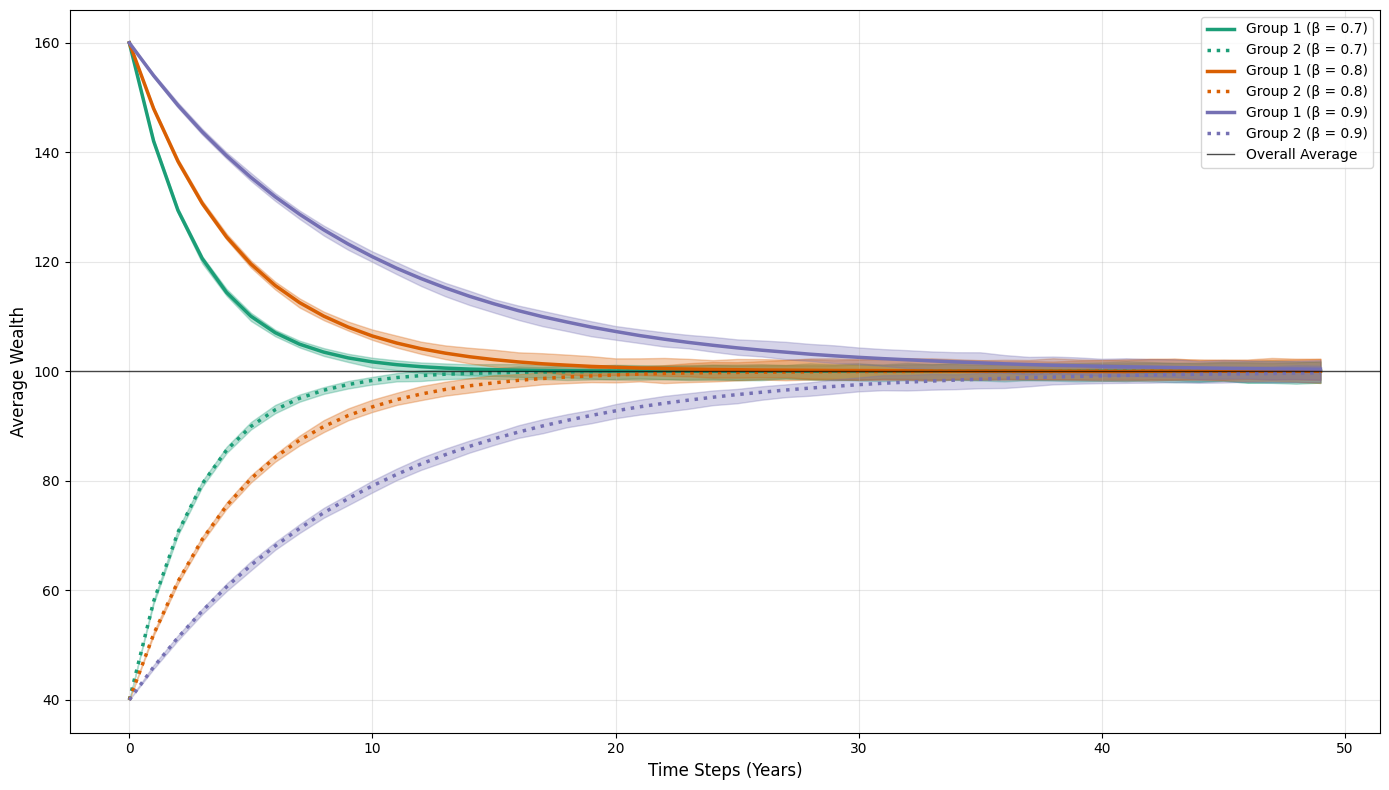

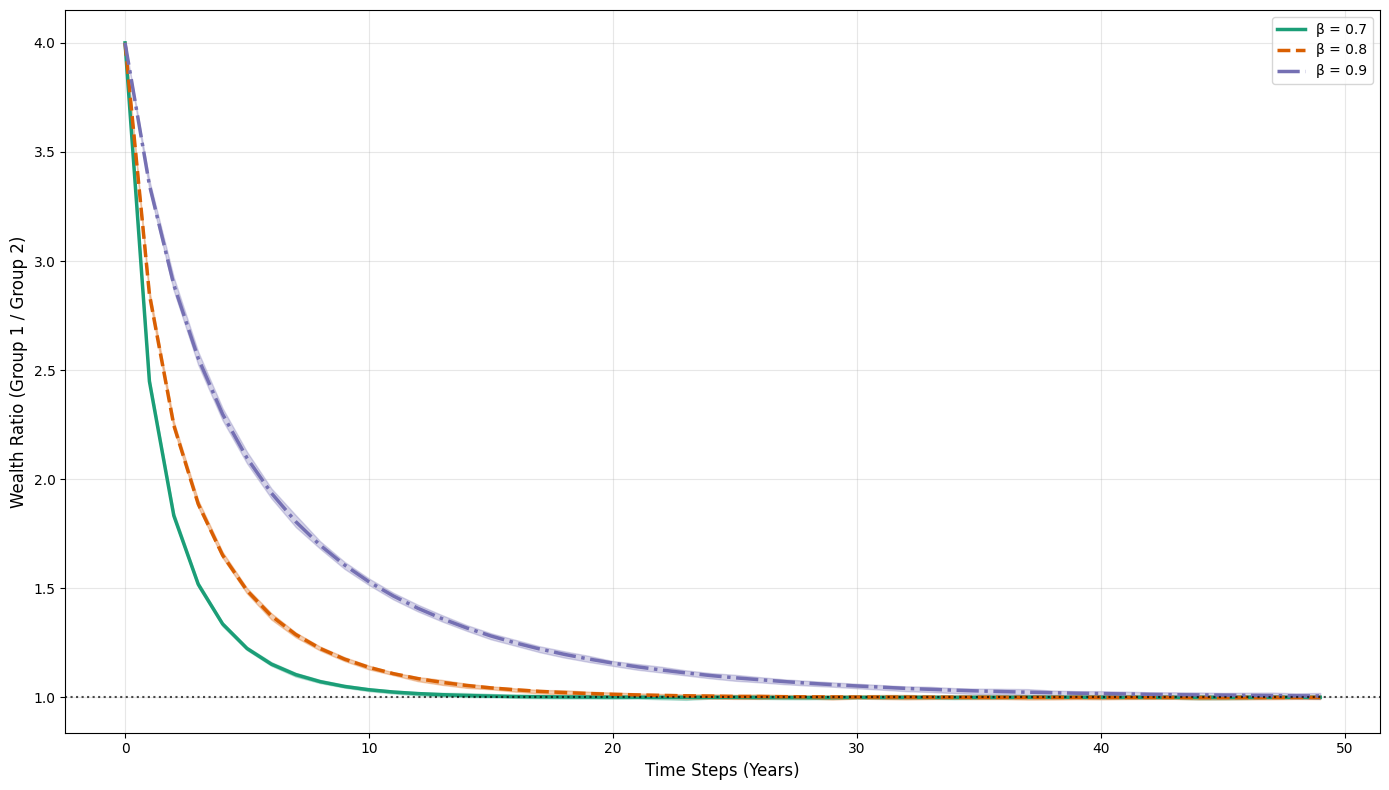

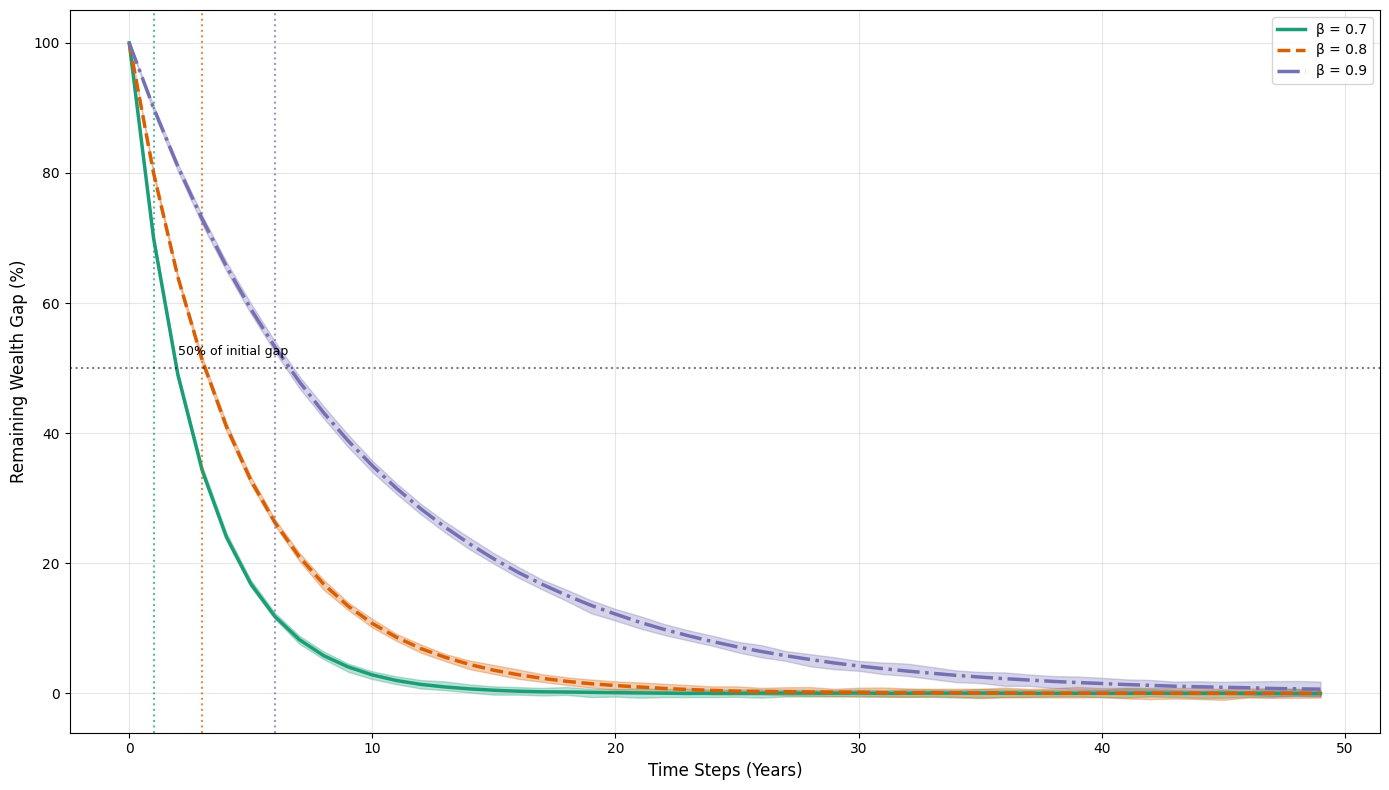

Wealth gap half-life comparison:
β	Theoretical	Observed
0.7	1.94		2
0.8	3.11		4
0.9	6.58		7


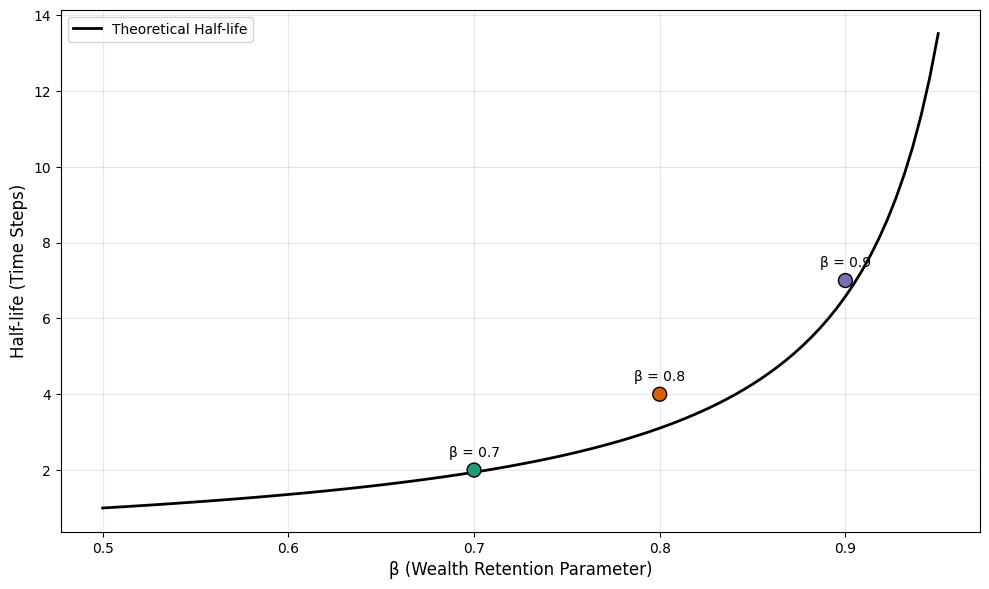

In [14]:
import numpy as np
import matplotlib.pyplot as plt

# Simulation parameters
n_agents = 10000  # total number of agents
n_timesteps = 50  # number of iterations (years)
n_runs = 100  # number of simulation runs
initial_wealth_mean = 100  # average initial wealth
epsilon_sigma = 10  # standard deviation for random shocks
beta_values = [0.7, 0.8, 0.9]  # retention rates to simulate

# Function to run a single simulation with a specific beta value
def run_simulation(beta, n_runs, n_agents, n_timesteps, initial_wealth_mean, epsilon_sigma):
    # Arrays to store group wealth over time for all runs
    all_group1_wealth = np.zeros((n_runs, n_timesteps))
    all_group2_wealth = np.zeros((n_runs, n_timesteps))
    all_avg_wealth = np.zeros((n_runs, n_timesteps))
    
    for run in range(n_runs):
        # Initialize two groups with different wealth
        # Group 1: twice the average wealth
        # Group 2: half the average wealth (ensuring overall average is still 100)
        n_group1 = n_agents // 2
        n_group2 = n_agents - n_group1
        
        # Calculate initial wealth to maintain overall average of initial_wealth_mean
        # If group 1 has 2x average and group 2 has 0.5x average, with equal sizes
        # Then (2x + 0.5x)/2 = initial_wealth_mean, solving for x
        x = 2 * initial_wealth_mean / 2.5
        
        wealth = np.zeros(n_agents)
        wealth[:n_group1] = 2 * x  # Group 1: twice the reference value
        wealth[n_group1:] = 0.5 * x  # Group 2: half the reference value
        
        # Verify average is close to initial_wealth_mean
        assert abs(wealth.mean() - initial_wealth_mean) < 0.01
        
        # Keep track of original group membership for tracking
        group1_indices = np.arange(n_group1)
        group2_indices = np.arange(n_group1, n_agents)
        
        # Arrays to store group wealth over time
        group1_wealth = np.zeros(n_timesteps)
        group2_wealth = np.zeros(n_timesteps)
        avg_wealth = np.zeros(n_timesteps)
        
        for t in range(n_timesteps):
            # Record current group averages
            group1_wealth[t] = wealth[group1_indices].mean()
            group2_wealth[t] = wealth[group2_indices].mean()
            avg_wealth[t] = wealth.mean()
            
            # Generate random shocks
            epsilon = np.random.normal(0, epsilon_sigma, n_agents)
            
            # Update wealth for next time step: W_i(t+1) = β W_i(t) + (1-β) W̄_t + ε_i
            wealth = beta * wealth + (1 - beta) * avg_wealth[t] + epsilon
        
        all_group1_wealth[run] = group1_wealth
        all_group2_wealth[run] = group2_wealth
        all_avg_wealth[run] = avg_wealth
    
    return all_group1_wealth, all_group2_wealth, all_avg_wealth

# Plot the results for all beta values on a single graph
plt.figure(figsize=(14, 8))

# Define colors that work well in both color and grayscale printing
# Using blue, red, and green with different saturations for better distinction
colors = ['#1b9e77', '#d95f02', '#7570b3']  # colorblind-friendly palette

# Run simulations and plot for each beta value
for idx, beta in enumerate(beta_values):
    # Run simulation with more runs to better visualize variance
    all_group1_wealth, all_group2_wealth, all_avg_wealth = run_simulation(
        beta, n_runs, n_agents, n_timesteps, initial_wealth_mean, epsilon_sigma
    )
    
    # Calculate mean, min, and max for each group across all runs
    mean_group1_wealth = np.mean(all_group1_wealth, axis=0)
    min_group1_wealth = np.min(all_group1_wealth, axis=0)
    max_group1_wealth = np.max(all_group1_wealth, axis=0)
    
    mean_group2_wealth = np.mean(all_group2_wealth, axis=0)
    min_group2_wealth = np.min(all_group2_wealth, axis=0)
    max_group2_wealth = np.max(all_group2_wealth, axis=0)
    
    # Plot Group 1 (initially richer) with solid line
    plt.plot(mean_group1_wealth, 
             label=f'Group 1 (β = {beta})', 
             color=colors[idx],
             linestyle='-',
             linewidth=2.5)
    
    plt.fill_between(range(n_timesteps), 
                     min_group1_wealth, 
                     max_group1_wealth, 
                     color=colors[idx], 
                     alpha=0.3)
    
    # Plot Group 2 (initially poorer) with dotted line
    plt.plot(mean_group2_wealth, 
             label=f'Group 2 (β = {beta})', 
             color=colors[idx],
             linestyle=':',
             linewidth=2.5)
    
    plt.fill_between(range(n_timesteps), 
                     min_group2_wealth, 
                     max_group2_wealth, 
                     color=colors[idx], 
                     alpha=0.3)

# Plot the overall average wealth (same for all simulations)
plt.axhline(y=initial_wealth_mean, 
         label='Overall Average', 
         color='black', 
         linestyle='-', 
         linewidth=1.0,
         alpha=0.7)

plt.xlabel('Time Steps (Years)', fontsize=12)
plt.ylabel('Average Wealth', fontsize=12)
plt.grid(True, alpha=0.3)
plt.legend(loc='best', fontsize=10)
plt.tight_layout()
plt.savefig('wealth_dynamics_combined.png', dpi=300)
plt.show()

# Now create a plot showing the wealth ratio over time
plt.figure(figsize=(14, 8))

# Colorblind-friendly and print-friendly palette
colors = ['#1b9e77', '#d95f02', '#7570b3']

for idx, beta in enumerate(beta_values):
    # Run simulation with more runs to better visualize variance
    all_group1_wealth, all_group2_wealth, _ = run_simulation(
        beta, n_runs, n_agents, n_timesteps, initial_wealth_mean, epsilon_sigma
    )
    
    # Calculate ratios for each run individually to properly display variance
    all_ratios = np.zeros((n_runs, n_timesteps))
    for run in range(n_runs):
        all_ratios[run] = all_group1_wealth[run] / all_group2_wealth[run]
    
    # Calculate mean, min, and max ratios
    mean_ratio = np.mean(all_ratios, axis=0)
    min_ratio = np.min(all_ratios, axis=0)
    max_ratio = np.max(all_ratios, axis=0)
    
    # Use different line styles for different beta values
    linestyle = '-' if idx == 0 else ('--' if idx == 1 else '-.')
    
    plt.plot(mean_ratio, label=f'β = {beta}', linewidth=2.5, color=colors[idx], linestyle=linestyle)
    plt.fill_between(range(n_timesteps), min_ratio, max_ratio, color=colors[idx], alpha=0.3)

plt.xlabel('Time Steps (Years)', fontsize=12)
plt.ylabel('Wealth Ratio (Group 1 / Group 2)', fontsize=12)
plt.legend(loc='best', fontsize=10)
plt.grid(True, alpha=0.3)
plt.axhline(y=1, color='black', linestyle=':', alpha=0.7)
plt.tight_layout()
plt.savefig('wealth_ratio_over_time.png', dpi=300)
plt.show()

# Create a plot showing wealth convergence rate for different beta values
plt.figure(figsize=(14, 8))

# Colorblind-friendly and print-friendly palette
colors = ['#1b9e77', '#d95f02', '#7570b3']
line_styles = ['-', '--', '-.']

for idx, beta in enumerate(beta_values):
    all_group1_wealth, all_group2_wealth, _ = run_simulation(
        beta, n_runs, n_agents, n_timesteps, initial_wealth_mean, epsilon_sigma
    )
    
    # Calculate gap remaining for each run
    remaining_gap_pct_all_runs = []
    
    for run in range(n_runs):
        initial_gap = all_group1_wealth[run, 0] - all_group2_wealth[run, 0]
        remaining_gap_pct = [(all_group1_wealth[run, t] - all_group2_wealth[run, t]) / initial_gap * 100 
                             for t in range(n_timesteps)]
        remaining_gap_pct_all_runs.append(remaining_gap_pct)
    
    # Calculate mean, min, and max for visualization
    mean_gap_pct = np.mean(remaining_gap_pct_all_runs, axis=0)
    min_gap_pct = np.min(remaining_gap_pct_all_runs, axis=0)
    max_gap_pct = np.max(remaining_gap_pct_all_runs, axis=0)
    
    plt.plot(mean_gap_pct, 
             label=f'β = {beta}', 
             linewidth=2.5, 
             color=colors[idx], 
             linestyle=line_styles[idx])
    
    plt.fill_between(range(n_timesteps), min_gap_pct, max_gap_pct, color=colors[idx], alpha=0.3)
    
    # Add a vertical line at the theoretically expected half-life
    # For the process W_i(t+1) = β W_i(t) + (1-β) W̄_t + ε_i
    # The theoretical half-life is approximately -log(2)/log(β)
    theoretical_halflife = int(-np.log(2)/np.log(beta))
    if theoretical_halflife < n_timesteps:
        plt.axvline(x=theoretical_halflife, 
                   color=colors[idx], 
                   linestyle=':', 
                   alpha=0.7)

# Add a horizontal line at 50% to visualize half-life
plt.axhline(y=50, color='black', linestyle=':', alpha=0.5)
plt.text(2, 52, '50% of initial gap', fontsize=9, color='black')

plt.xlabel('Time Steps (Years)', fontsize=12)
plt.ylabel('Remaining Wealth Gap (%)', fontsize=12)
plt.legend(loc='upper right', fontsize=10)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('wealth_convergence_rate.png', dpi=300)
plt.show()

# Add a summary plot for theoretical vs. observed half-life
plt.figure(figsize=(10, 6))

# Colorblind-friendly and print-friendly palette
colors = ['#1b9e77', '#d95f02', '#7570b3']

# Calculate theoretical half-life for a range of beta values
beta_range = np.linspace(0.5, 0.95, 100)
theoretical_halflife = [-np.log(2)/np.log(beta) for beta in beta_range]

plt.plot(beta_range, theoretical_halflife, 'k-', label='Theoretical Half-life', linewidth=2)

# Calculate observed half-life from simulations
observed_halflife = []
theoretical_values = []

print("Wealth gap half-life comparison:")
print("β\tTheoretical\tObserved")

for i, beta in enumerate(beta_values):
    # Theoretical half-life
    theoretical = -np.log(2)/np.log(beta)
    theoretical_values.append(theoretical)
    
    # Observed half-life from simulation
    all_group1_wealth, all_group2_wealth, _ = run_simulation(
        beta, n_runs, n_agents, n_timesteps, initial_wealth_mean, epsilon_sigma
    )
    
    mean_group1_wealth = np.mean(all_group1_wealth, axis=0)
    mean_group2_wealth = np.mean(all_group2_wealth, axis=0)
    
    initial_gap = mean_group1_wealth[0] - mean_group2_wealth[0]
    
    observed = None
    # Find first time when gap is less than half of initial
    for t in range(n_timesteps):
        current_gap = mean_group1_wealth[t] - mean_group2_wealth[t]
        if current_gap < initial_gap / 2:
            observed = t
            break
    
    if observed is None:
        observed = n_timesteps  # Use max timestep if half-life not reached
        
    observed_halflife.append(observed)
    print(f"{beta}\t{theoretical:.2f}\t\t{observed}")

# Plot the observed half-life points
plt.scatter(beta_values, observed_halflife, color=colors, s=100, zorder=5, edgecolor='black')

# Add annotations for each beta value
for i, beta in enumerate(beta_values):
    plt.annotate(f'β = {beta}', 
                xy=(beta, observed_halflife[i]),
                xytext=(0, 10),
                textcoords='offset points',
                ha='center',
                fontsize=10)

plt.xlabel('β (Wealth Retention Parameter)', fontsize=12)
plt.ylabel('Half-life (Time Steps)', fontsize=12)
plt.grid(True, alpha=0.3)
plt.legend(loc='upper left')
plt.tight_layout()
plt.savefig('halflife_comparison.png', dpi=300)
plt.show()

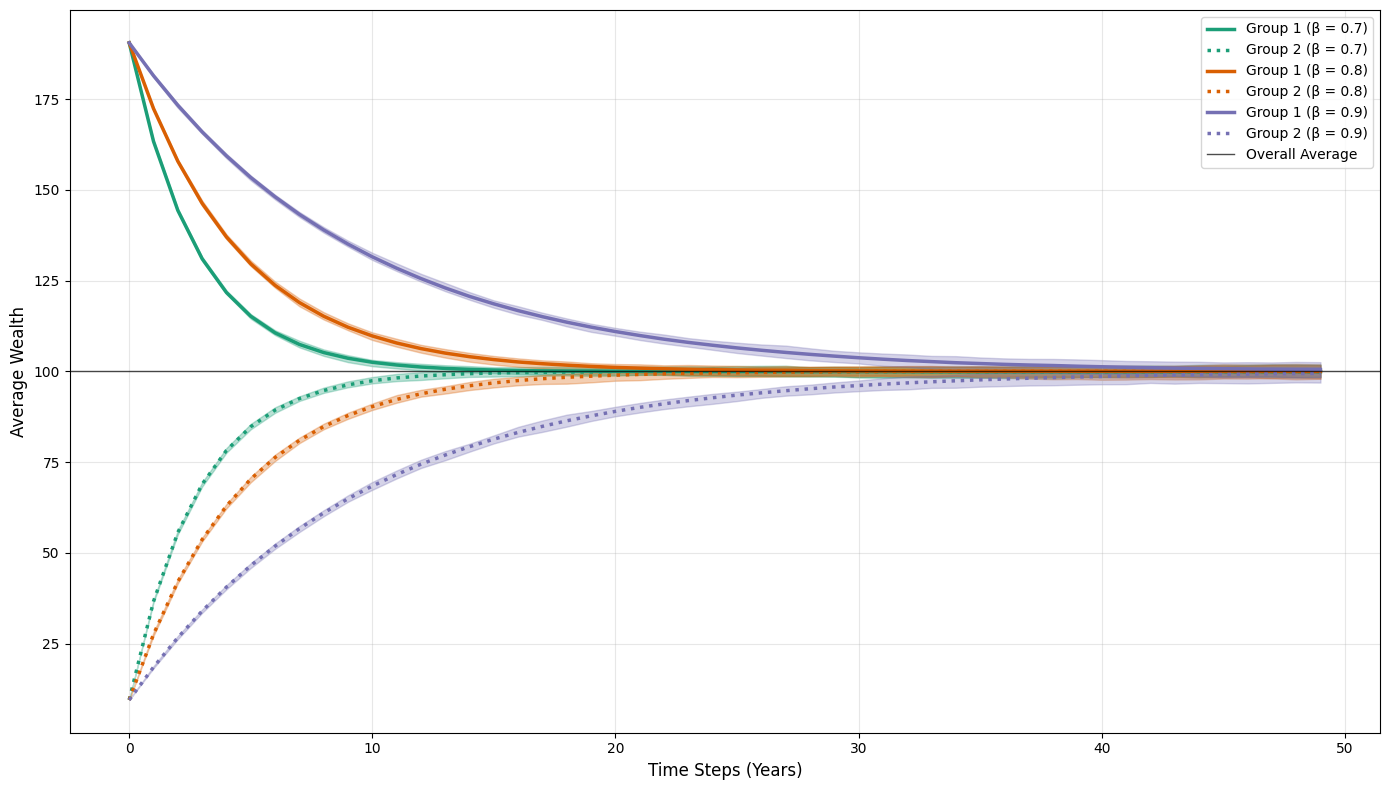

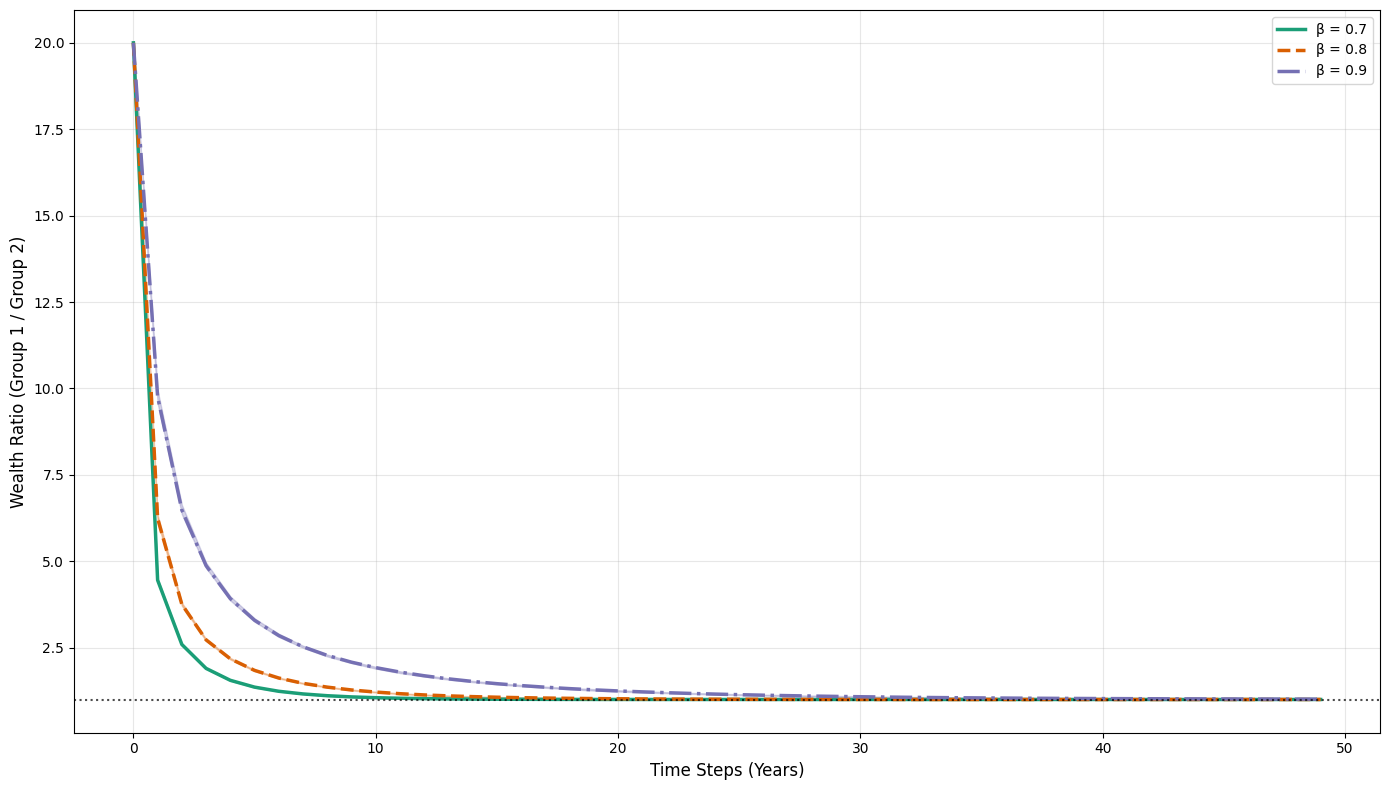

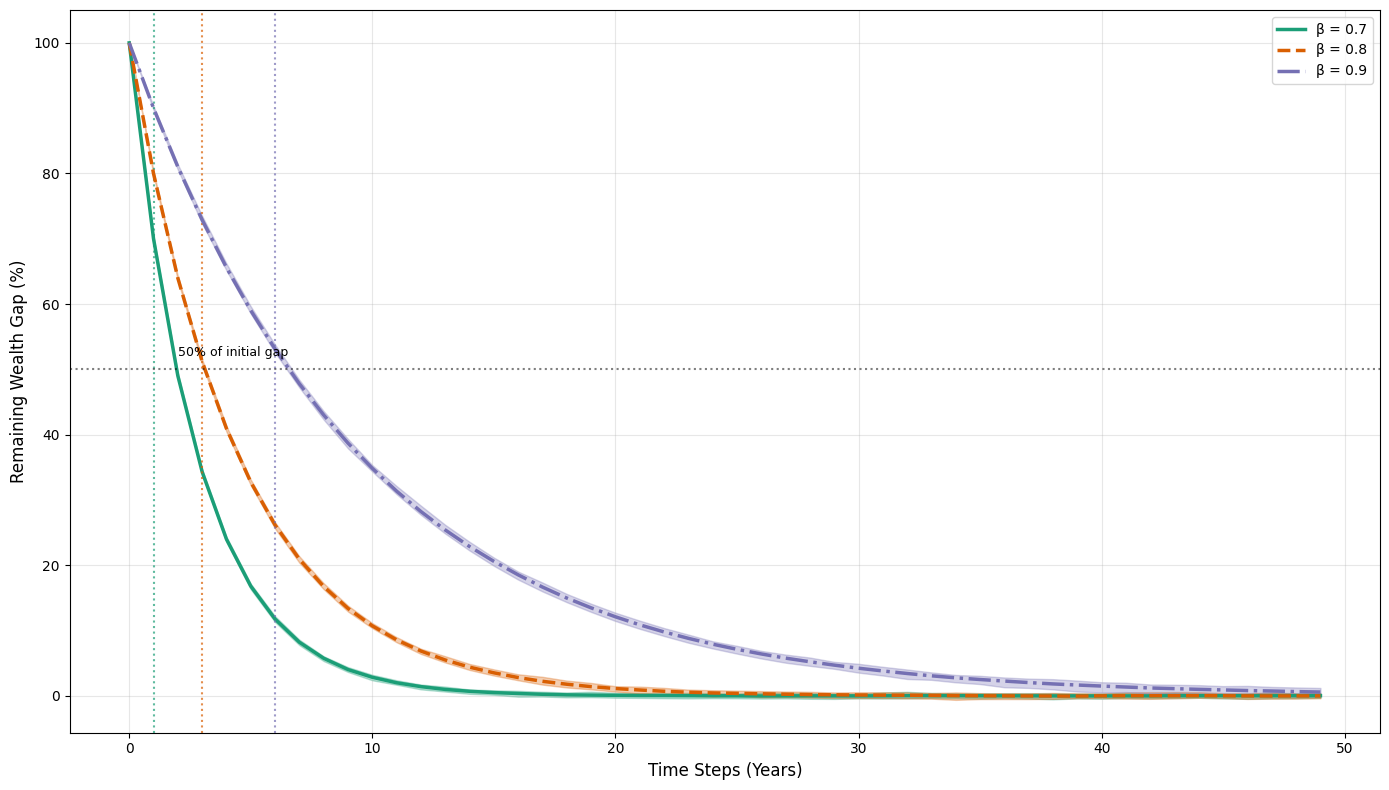

Wealth gap half-life comparison:
β	Theoretical	Observed
0.7	1.94		2
0.8	3.11		4
0.9	6.58		7


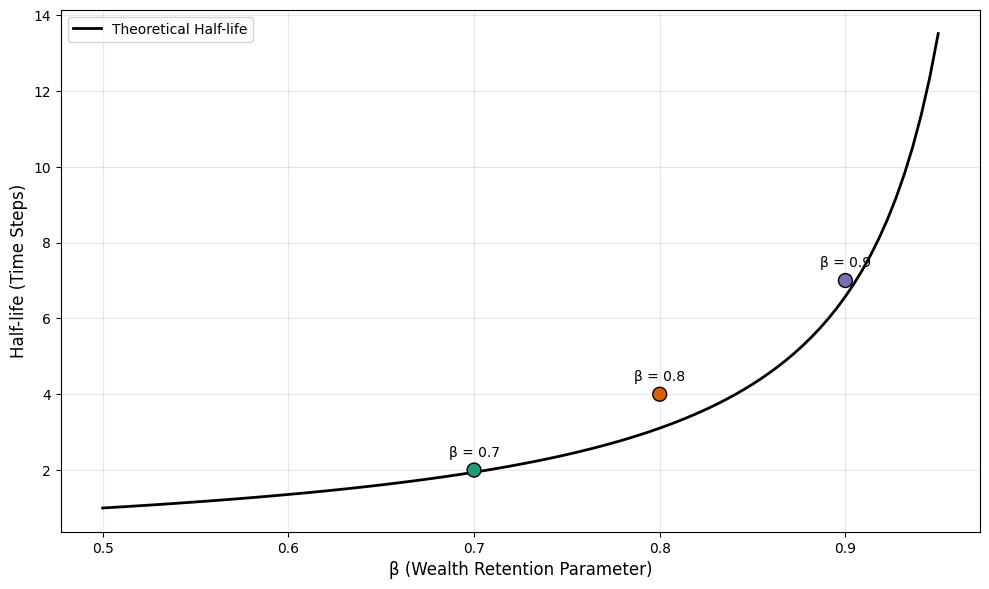

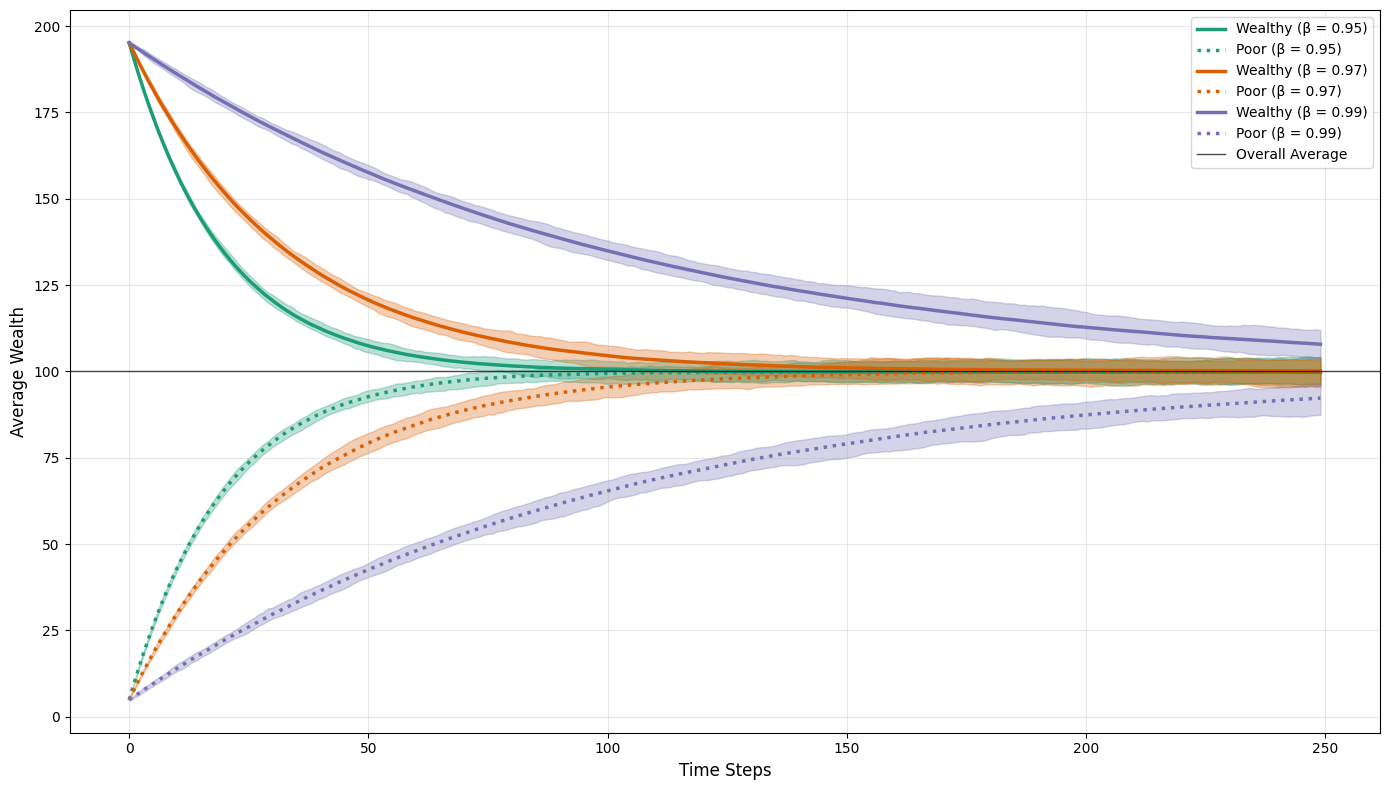

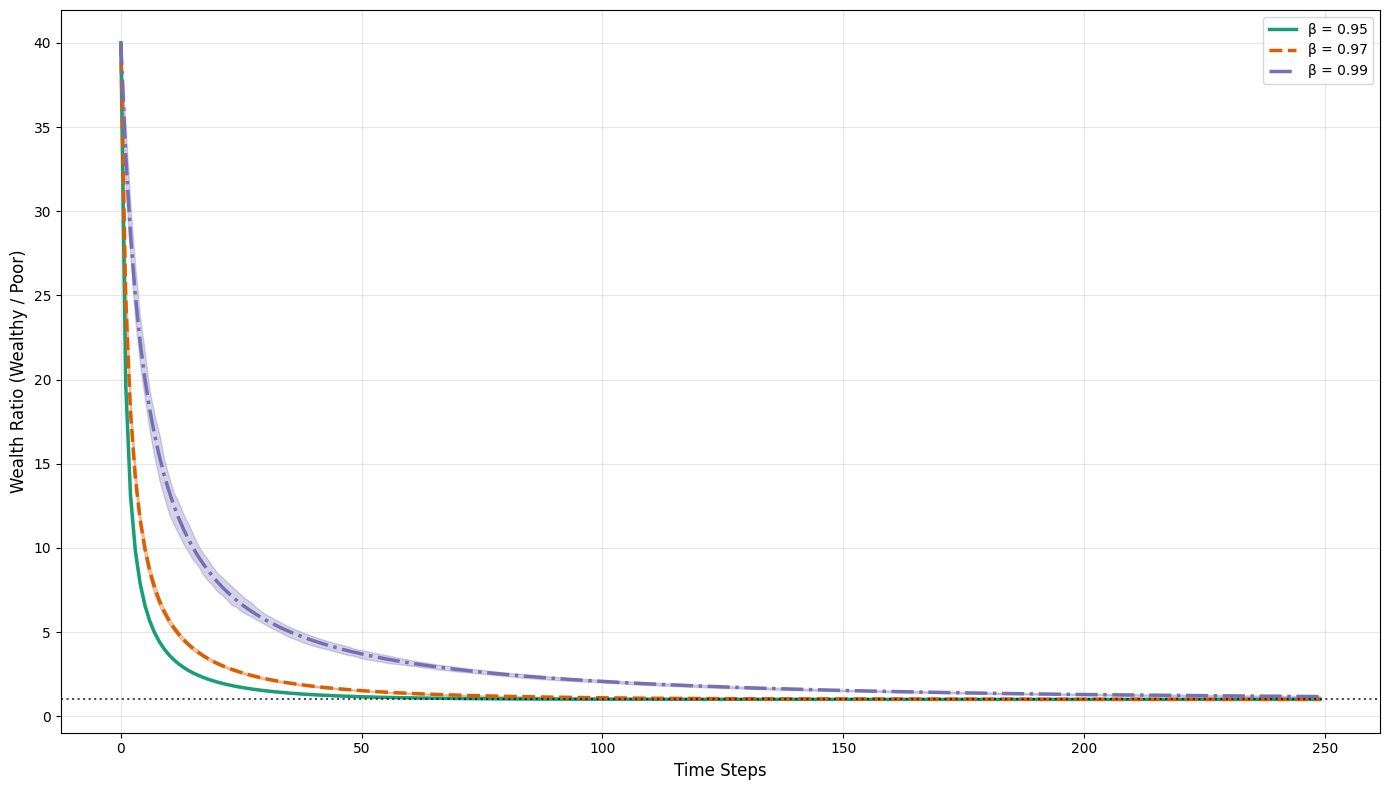

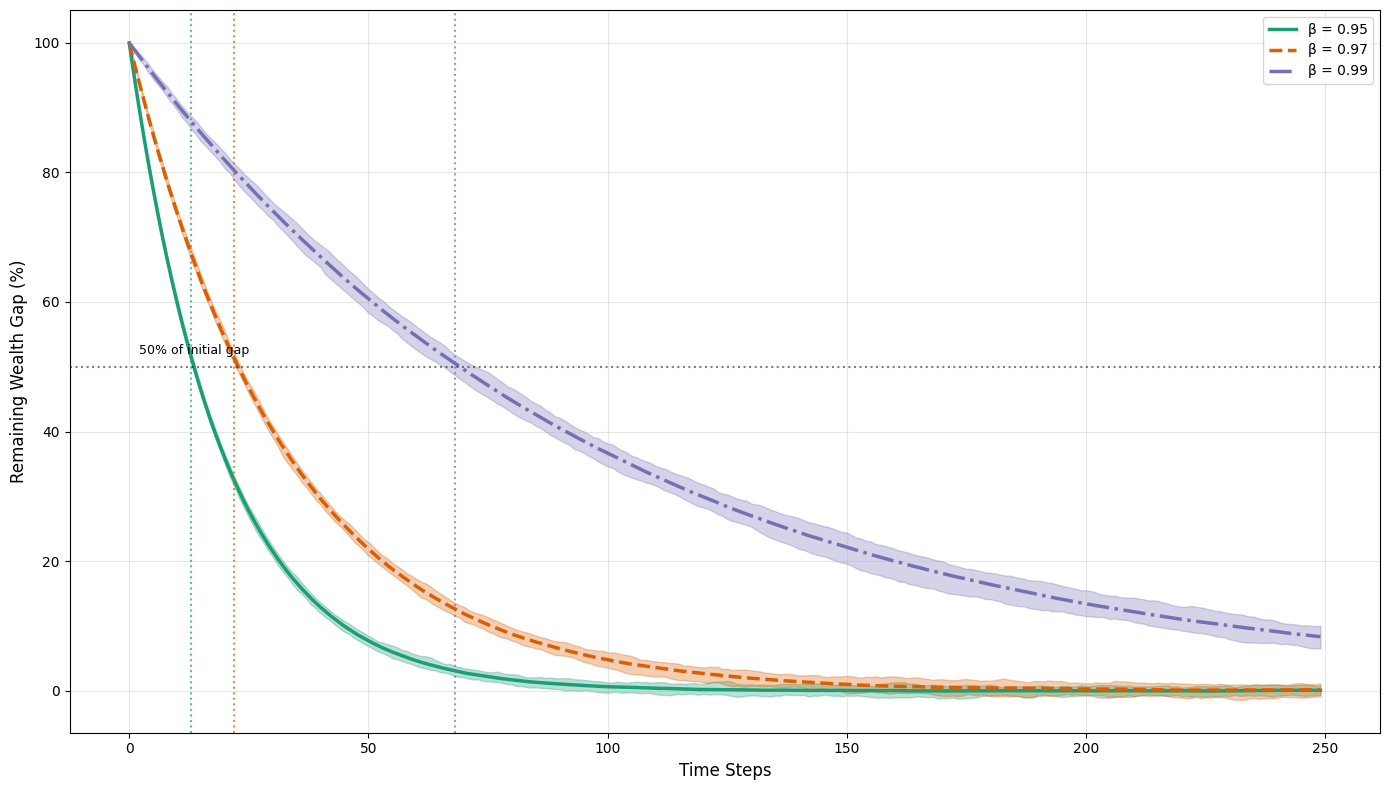

Wealth gap half-life comparison:
β	Theoretical	Observed
0.95	13.51		14
0.97	22.76		23
0.99	68.97		69


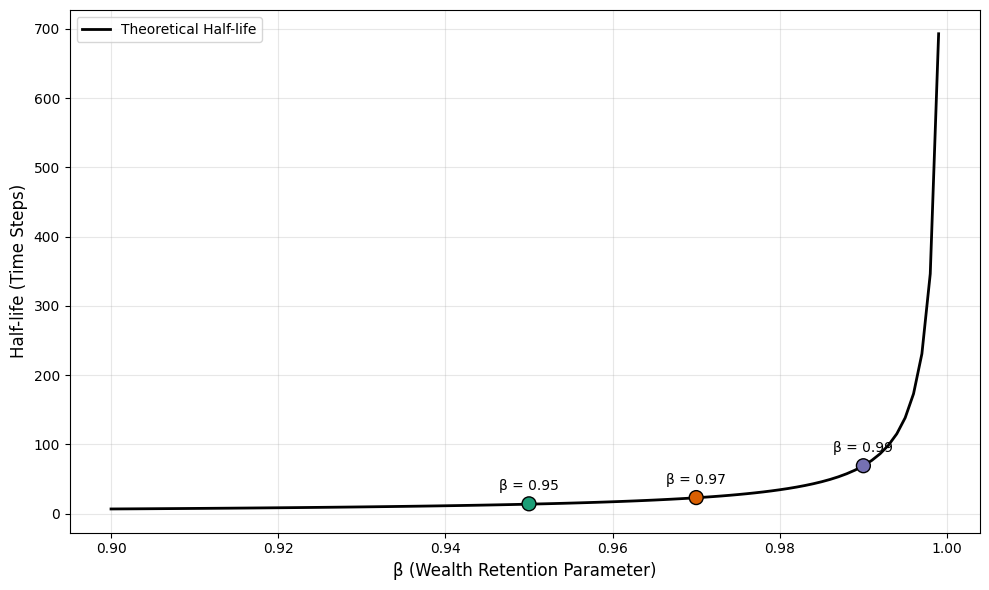

In [21]:
import numpy as np
import matplotlib.pyplot as plt

# Simulation parameters
n_agents = 10000  # total number of agents
n_timesteps = 250  # number of iterations
n_runs = 100  # number of simulation runs
initial_wealth_mean = 100  # average initial wealth
epsilon_sigma = 10  # standard deviation for random shocks
beta_values = [0.95, 0.97, .99]  # retention rates to simulate

# Function to run a single simulation with a specific beta value
def run_simulation(beta, n_runs, n_agents, n_timesteps, initial_wealth_mean, epsilon_sigma):
    # Arrays to store group wealth over time for all runs
    all_group1_wealth = np.zeros((n_runs, n_timesteps))
    all_group2_wealth = np.zeros((n_runs, n_timesteps))
    all_avg_wealth = np.zeros((n_runs, n_timesteps))
    
    for run in range(n_runs):
        # Initialize two groups with different wealth
        n_group1 = n_agents // 2
        n_group2 = n_agents - n_group1
        
        # Calculate initial wealth to maintain overall average of initial_wealth_mean
        # For a 40:1 ratio between group 1 and group 2
        # If group 1 gets 40x and group 2 gets 1x, and we want an average of initial_wealth_mean
        # With equal sizes: (40x + 1x) / 2 = initial_wealth_mean
        # Solving for x: x = 2 * initial_wealth_mean / 41
        x = 2 * initial_wealth_mean / 41
        
        # Initialize wealth array with exact values
        wealth = np.zeros(n_agents)
        wealth[:n_group1] = 40 * x  # Group 1: 40 times the reference value (wealthy)
        wealth[n_group1:] = 1 * x   # Group 2: reference value (poor)
        
        # Verify the ratio is exactly 40:1
        ratio = wealth[:n_group1].mean() / wealth[n_group1:].mean()
        assert abs(ratio - 40) < 0.0001, f"Ratio is {ratio}, not 40"
        
        # Verify average is exactly initial_wealth_mean
        assert abs(wealth.mean() - initial_wealth_mean) < 0.0001, f"Average is {wealth.mean()}, not {initial_wealth_mean}"
        
        # Keep track of original group membership for tracking
        group1_indices = np.arange(n_group1)
        group2_indices = np.arange(n_group1, n_agents)
        
        # Arrays to store group wealth over time
        group1_wealth = np.zeros(n_timesteps)
        group2_wealth = np.zeros(n_timesteps)
        avg_wealth = np.zeros(n_timesteps)
        
        for t in range(n_timesteps):
            # Record current group averages
            group1_wealth[t] = wealth[group1_indices].mean()
            group2_wealth[t] = wealth[group2_indices].mean()
            avg_wealth[t] = wealth.mean()
            
            # Generate random shocks
            epsilon = np.random.normal(0, epsilon_sigma, n_agents)
            
            # Update wealth for next time step: W_i(t+1) = β W_i(t) + (1-β) W̄_t + ε_i
            wealth = beta * wealth + (1 - beta) * avg_wealth[t] + epsilon
        
        all_group1_wealth[run] = group1_wealth
        all_group2_wealth[run] = group2_wealth
        all_avg_wealth[run] = avg_wealth
    
    return all_group1_wealth, all_group2_wealth, all_avg_wealth

# Plot the results for all beta values on a single graph
plt.figure(figsize=(14, 8))

# Define colors that work well in both color and grayscale printing
colors = ['#1b9e77', '#d95f02', '#7570b3']  # colorblind-friendly palette

# Run simulations and plot for each beta value
for idx, beta in enumerate(beta_values):
    # Run simulation with more runs to better visualize variance
    all_group1_wealth, all_group2_wealth, all_avg_wealth = run_simulation(
        beta, n_runs, n_agents, n_timesteps, initial_wealth_mean, epsilon_sigma
    )
    
    # Calculate mean, min, and max for each group across all runs
    mean_group1_wealth = np.mean(all_group1_wealth, axis=0)
    min_group1_wealth = np.min(all_group1_wealth, axis=0)
    max_group1_wealth = np.max(all_group1_wealth, axis=0)
    
    mean_group2_wealth = np.mean(all_group2_wealth, axis=0)
    min_group2_wealth = np.min(all_group2_wealth, axis=0)
    max_group2_wealth = np.max(all_group2_wealth, axis=0)
    
    # Plot Wealthy (initially richer) with solid line
    plt.plot(mean_group1_wealth, 
             label=f'Wealthy (β = {beta})', 
             color=colors[idx],
             linestyle='-',
             linewidth=2.5)
    
    plt.fill_between(range(n_timesteps), 
                     min_group1_wealth, 
                     max_group1_wealth, 
                     color=colors[idx], 
                     alpha=0.3)
    
    # Plot Poor (initially poorer) with dotted line
    plt.plot(mean_group2_wealth, 
             label=f'Poor (β = {beta})', 
             color=colors[idx],
             linestyle=':',
             linewidth=2.5)
    
    plt.fill_between(range(n_timesteps), 
                     min_group2_wealth, 
                     max_group2_wealth, 
                     color=colors[idx], 
                     alpha=0.3)

# Plot the overall average wealth (same for all simulations)
plt.axhline(y=initial_wealth_mean, 
         label='Overall Average', 
         color='black', 
         linestyle='-', 
         linewidth=1.0,
         alpha=0.7)

plt.xlabel('Time Steps', fontsize=12)
plt.ylabel('Average Wealth', fontsize=12)
plt.grid(True, alpha=0.3)
plt.legend(loc='best', fontsize=10)
plt.tight_layout()
plt.savefig('wealth_dynamics_40to1.png', dpi=300)
plt.show()

# Now create a plot showing the wealth ratio over time
plt.figure(figsize=(14, 8))

# Colorblind-friendly and print-friendly palette
colors = ['#1b9e77', '#d95f02', '#7570b3']
line_styles = ['-', '--', '-.']

for idx, beta in enumerate(beta_values):
    # Run simulation with more runs to better visualize variance
    all_group1_wealth, all_group2_wealth, _ = run_simulation(
        beta, n_runs, n_agents, n_timesteps, initial_wealth_mean, epsilon_sigma
    )
    
    # Calculate ratios for each run individually to properly display variance
    all_ratios = np.zeros((n_runs, n_timesteps))
    for run in range(n_runs):
        all_ratios[run] = all_group1_wealth[run] / all_group2_wealth[run]
    
    # Calculate mean, min, and max ratios
    mean_ratio = np.mean(all_ratios, axis=0)
    min_ratio = np.min(all_ratios, axis=0)
    max_ratio = np.max(all_ratios, axis=0)
    
    # Use different line styles for different beta values
    plt.plot(mean_ratio, label=f'β = {beta}', linewidth=2.5, color=colors[idx], linestyle=line_styles[idx])
    plt.fill_between(range(n_timesteps), min_ratio, max_ratio, color=colors[idx], alpha=0.3)

plt.xlabel('Time Steps', fontsize=12)
plt.ylabel('Wealth Ratio (Wealthy / Poor)', fontsize=12)
plt.legend(loc='best', fontsize=10)
plt.grid(True, alpha=0.3)
plt.axhline(y=1, color='black', linestyle=':', alpha=0.7)
plt.tight_layout()
plt.savefig('wealth_ratio_40to1.png', dpi=300)
plt.show()

# Create a plot showing wealth convergence rate for different beta values
plt.figure(figsize=(14, 8))

# Colorblind-friendly and print-friendly palette
colors = ['#1b9e77', '#d95f02', '#7570b3']
line_styles = ['-', '--', '-.']

for idx, beta in enumerate(beta_values):
    all_group1_wealth, all_group2_wealth, _ = run_simulation(
        beta, n_runs, n_agents, n_timesteps, initial_wealth_mean, epsilon_sigma
    )
    
    # Calculate gap remaining for each run
    remaining_gap_pct_all_runs = []
    
    for run in range(n_runs):
        initial_gap = all_group1_wealth[run, 0] - all_group2_wealth[run, 0]
        remaining_gap_pct = [(all_group1_wealth[run, t] - all_group2_wealth[run, t]) / initial_gap * 100 
                             for t in range(n_timesteps)]
        remaining_gap_pct_all_runs.append(remaining_gap_pct)
    
    # Calculate mean, min, and max for visualization
    mean_gap_pct = np.mean(remaining_gap_pct_all_runs, axis=0)
    min_gap_pct = np.min(remaining_gap_pct_all_runs, axis=0)
    max_gap_pct = np.max(remaining_gap_pct_all_runs, axis=0)
    
    plt.plot(mean_gap_pct, 
             label=f'β = {beta}', 
             linewidth=2.5, 
             color=colors[idx], 
             linestyle=line_styles[idx])
    
    plt.fill_between(range(n_timesteps), min_gap_pct, max_gap_pct, color=colors[idx], alpha=0.3)
    
    # Add a vertical line at the theoretically expected half-life
    # For the process W_i(t+1) = β W_i(t) + (1-β) W̄_t + ε_i
    # The theoretical half-life is approximately -log(2)/log(β)
    theoretical_halflife = int(-np.log(2)/np.log(beta))
    if theoretical_halflife < n_timesteps:
        plt.axvline(x=theoretical_halflife, 
                   color=colors[idx], 
                   linestyle=':', 
                   alpha=0.7)

# Add a horizontal line at 50% to visualize half-life
plt.axhline(y=50, color='black', linestyle=':', alpha=0.5)
plt.text(2, 52, '50% of initial gap', fontsize=9, color='black')

plt.xlabel('Time Steps', fontsize=12)
plt.ylabel('Remaining Wealth Gap (%)', fontsize=12)
plt.legend(loc='upper right', fontsize=10)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('wealth_convergence_40to1.png', dpi=300)
plt.show()

# Add a summary plot for theoretical vs. observed half-life
plt.figure(figsize=(10, 6))

# Calculate theoretical half-life for a range of beta values
beta_range = np.linspace(0.9, 0.999, 100)
theoretical_halflife = [-np.log(2)/np.log(beta) for beta in beta_range]

plt.plot(beta_range, theoretical_halflife, 'k-', label='Theoretical Half-life', linewidth=2)

# Calculate observed half-life from simulations
observed_halflife = []
theoretical_values = []

print("Wealth gap half-life comparison:")
print("β\tTheoretical\tObserved")

for i, beta in enumerate(beta_values):
    # Theoretical half-life
    theoretical = -np.log(2)/np.log(beta)
    theoretical_values.append(theoretical)
    
    # Observed half-life from simulation
    all_group1_wealth, all_group2_wealth, _ = run_simulation(
        beta, n_runs, n_agents, n_timesteps, initial_wealth_mean, epsilon_sigma
    )
    
    mean_group1_wealth = np.mean(all_group1_wealth, axis=0)
    mean_group2_wealth = np.mean(all_group2_wealth, axis=0)
    
    initial_gap = mean_group1_wealth[0] - mean_group2_wealth[0]
    
    observed = None
    # Find first time when gap is less than half of initial
    for t in range(n_timesteps):
        current_gap = mean_group1_wealth[t] - mean_group2_wealth[t]
        if current_gap < initial_gap / 2:
            observed = t
            break
    
    if observed is None:
        observed = n_timesteps  # Use max timestep if half-life not reached
        
    observed_halflife.append(observed)
    print(f"{beta}\t{theoretical:.2f}\t\t{observed if observed < n_timesteps else '> '+str(n_timesteps)}")

# Plot the observed half-life points
plt.scatter(beta_values, [min(oh, n_timesteps) for oh in observed_halflife], color=colors, s=100, zorder=5, edgecolor='black')

# Add annotations for each beta value
for i, beta in enumerate(beta_values):
    observed = observed_halflife[i]
    label = f'β = {beta}'
    if observed >= n_timesteps:
        label += ' (not reached)'
    
    plt.annotate(label, 
                xy=(beta, min(observed, n_timesteps)),
                xytext=(0, 10),
                textcoords='offset points',
                ha='center',
                fontsize=10)

plt.xlabel('β (Wealth Retention Parameter)', fontsize=12)
plt.ylabel('Half-life (Time Steps)', fontsize=12)
plt.grid(True, alpha=0.3)
plt.legend(loc='upper left')
plt.tight_layout()
plt.savefig('halflife_comparison_40to1.png', dpi=300)
plt.show()

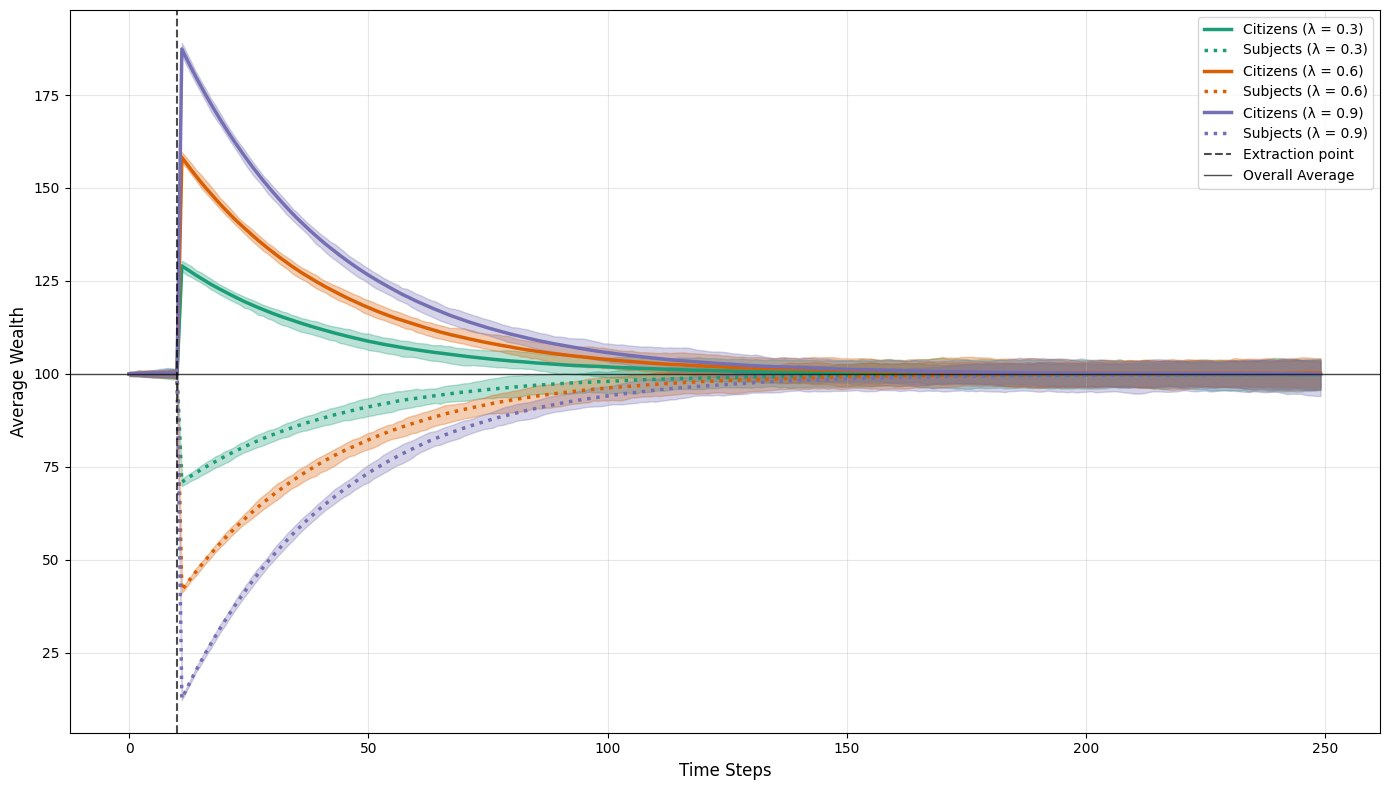

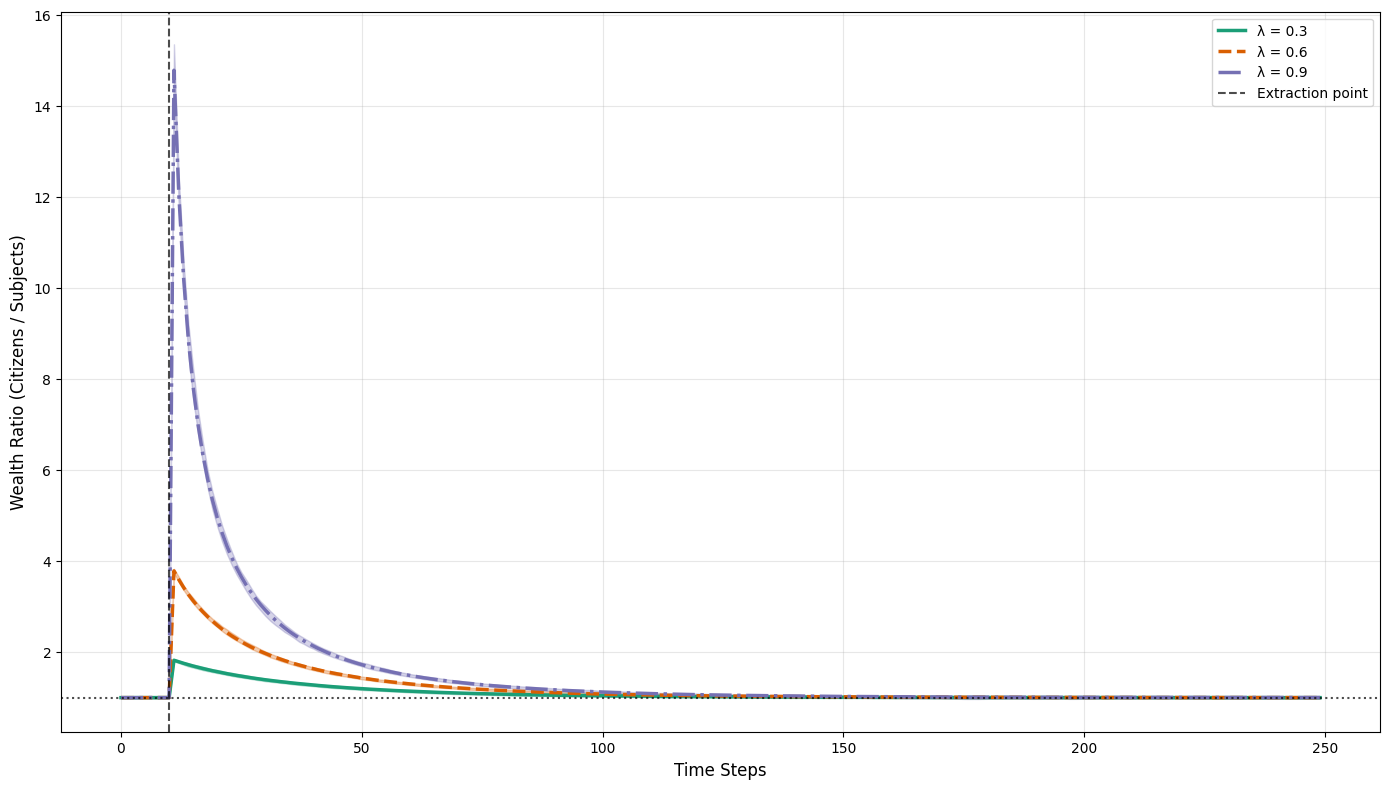

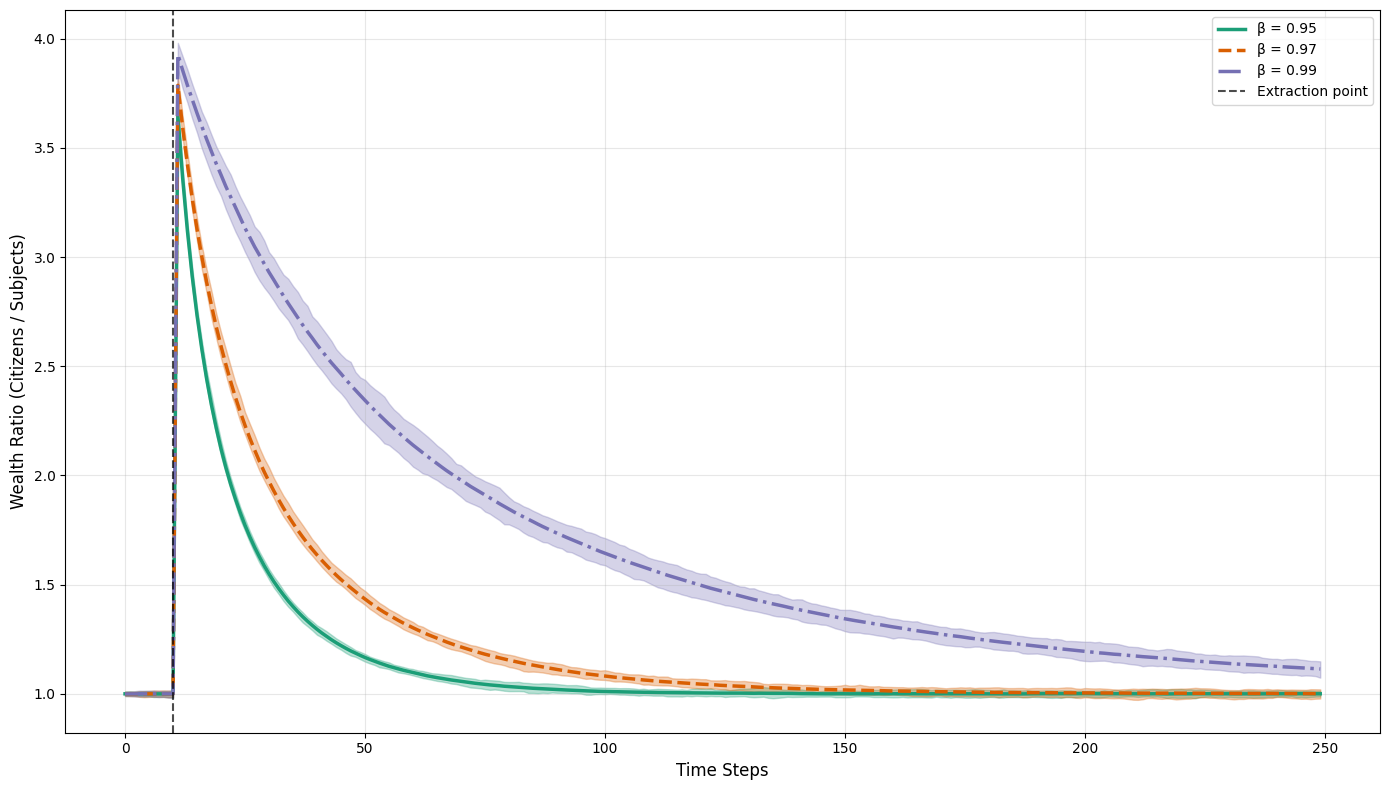

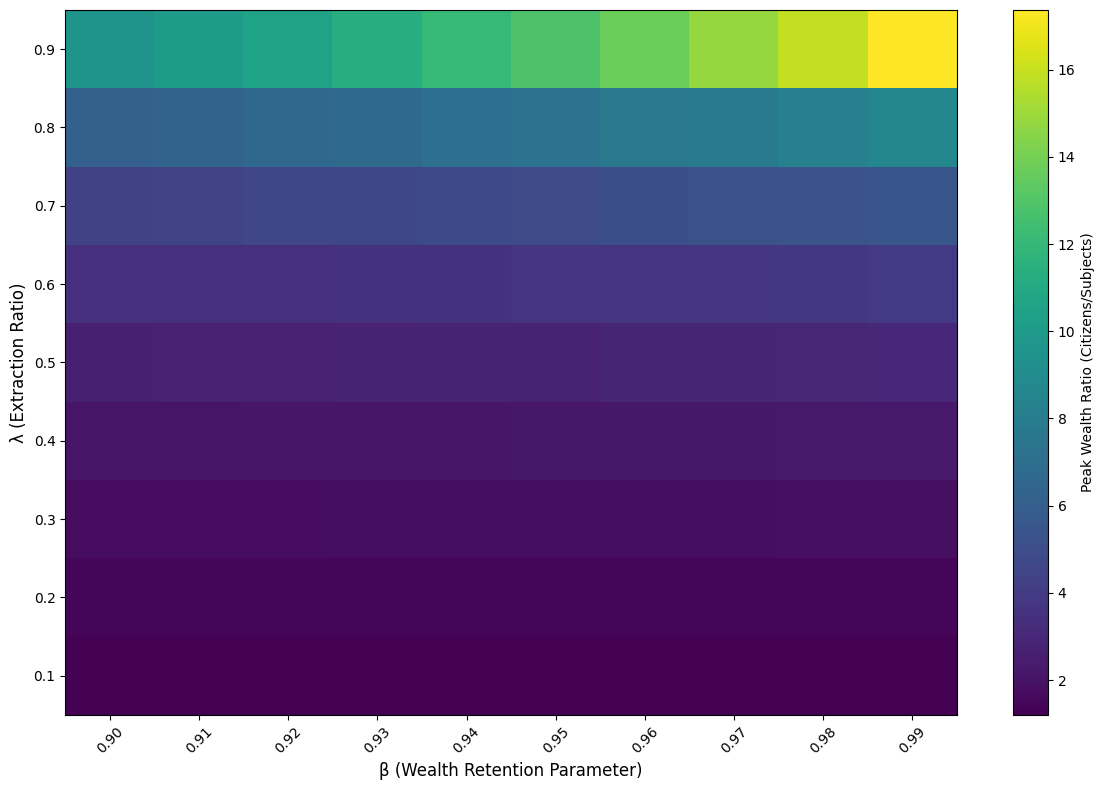

Simulation parameters:
- Number of agents: 10000
- Proportion of citizens (ρ): 0.5
- Extraction occurs at time step: 10
- Initial average wealth: 100

Peak wealth ratios after extraction:
λ = 0.3, β = 0.97:
  - Peak ratio: 1.84 (at time step 11)
  - Immediate post-extraction ratio: 1.00
  - Final ratio (t=249): 1.00
  - Theoretical immediate post-extraction ratio: 1.86

λ = 0.6, β = 0.97:
  - Peak ratio: 3.78 (at time step 11)
  - Immediate post-extraction ratio: 1.00
  - Final ratio (t=249): 1.00
  - Theoretical immediate post-extraction ratio: 4.00

λ = 0.9, β = 0.97:
  - Peak ratio: 14.88 (at time step 11)
  - Immediate post-extraction ratio: 1.00
  - Final ratio (t=249): 1.00
  - Theoretical immediate post-extraction ratio: 19.00



In [22]:
import numpy as np
import matplotlib.pyplot as plt

# Simulation parameters
n_agents = 10000  # total number of agents
n_timesteps = 250  # number of iterations
n_runs = 100  # number of simulation runs
initial_wealth_mean = 100  # average initial wealth
epsilon_sigma = 10  # standard deviation for random shocks
beta_values = [0.95, 0.97, 0.99]  # retention rates to simulate
extraction_step = 10  # time step at which extraction occurs
rho = 0.5  # proportion of citizens in the population
lambda_values = [0.3, 0.6, 0.9]  # extraction ratios to simulate

# Function to run a single simulation with specific beta and lambda values
def run_simulation(beta, lambda_extraction, n_runs, n_agents, n_timesteps, initial_wealth_mean, 
                  epsilon_sigma, extraction_step, rho):
    # Arrays to store group wealth over time for all runs
    all_citizens_wealth = np.zeros((n_runs, n_timesteps))
    all_subjects_wealth = np.zeros((n_runs, n_timesteps))
    all_avg_wealth = np.zeros((n_runs, n_timesteps))
    
    for run in range(n_runs):
        # Initialize citizens and subjects with same initial wealth distribution
        n_citizens = int(n_agents * rho)
        n_subjects = n_agents - n_citizens
        
        # Initially give everyone the same average wealth (random around mean)
        wealth = np.random.lognormal(mean=np.log(initial_wealth_mean), sigma=0.2, size=n_agents)
        
        # Normalize to ensure overall average is exactly initial_wealth_mean
        wealth = wealth * (initial_wealth_mean / wealth.mean())
        
        # Keep track of group membership
        citizens_indices = np.arange(n_citizens)
        subjects_indices = np.arange(n_citizens, n_agents)
        
        # Arrays to store group wealth over time
        citizens_wealth = np.zeros(n_timesteps)
        subjects_wealth = np.zeros(n_timesteps)
        avg_wealth = np.zeros(n_timesteps)
        
        for t in range(n_timesteps):
            # Record current group averages
            citizens_wealth[t] = wealth[citizens_indices].mean()
            subjects_wealth[t] = wealth[subjects_indices].mean()
            avg_wealth[t] = wealth.mean()
            
            # Extraction happens at the defined step
            if t == extraction_step:
                # Calculate total wealth extracted from subjects
                extracted_total = wealth[subjects_indices].sum() * lambda_extraction
                
                # Reduce subjects' wealth by extracted amount
                wealth[subjects_indices] = wealth[subjects_indices] * (1 - lambda_extraction)
                
                # Distribute extracted wealth equally among citizens
                wealth[citizens_indices] += extracted_total / n_citizens
            
            # Generate random shocks
            epsilon = np.random.normal(0, epsilon_sigma, n_agents)
            
            # Update wealth for next time step: W_i(t+1) = β W_i(t) + (1-β) W̄_t + ε_i
            # This applies after extraction has been processed for the current time step
            wealth = beta * wealth + (1 - beta) * avg_wealth[t] + epsilon
        
        all_citizens_wealth[run] = citizens_wealth
        all_subjects_wealth[run] = subjects_wealth
        all_avg_wealth[run] = avg_wealth
    
    return all_citizens_wealth, all_subjects_wealth, all_avg_wealth

# Plot wealth over time for different lambda values and fixed beta
fixed_beta = 0.97  # Choose one beta value to focus on extraction effects

plt.figure(figsize=(14, 8))

# Define colors that work well in both color and grayscale printing
colors = ['#1b9e77', '#d95f02', '#7570b3']  # colorblind-friendly palette

# Run simulations and plot for each lambda value
for idx, lambda_extraction in enumerate(lambda_values):
    # Run simulation
    all_citizens_wealth, all_subjects_wealth, all_avg_wealth = run_simulation(
        fixed_beta, lambda_extraction, n_runs, n_agents, n_timesteps, 
        initial_wealth_mean, epsilon_sigma, extraction_step, rho
    )
    
    # Calculate mean, min, and max for each group across all runs
    mean_citizens_wealth = np.mean(all_citizens_wealth, axis=0)
    min_citizens_wealth = np.min(all_citizens_wealth, axis=0)
    max_citizens_wealth = np.max(all_citizens_wealth, axis=0)
    
    mean_subjects_wealth = np.mean(all_subjects_wealth, axis=0)
    min_subjects_wealth = np.min(all_subjects_wealth, axis=0)
    max_subjects_wealth = np.max(all_subjects_wealth, axis=0)
    
    # Plot Citizens with solid line
    plt.plot(mean_citizens_wealth, 
             label=f'Citizens (λ = {lambda_extraction})', 
             color=colors[idx],
             linestyle='-',
             linewidth=2.5)
    
    plt.fill_between(range(n_timesteps), 
                     min_citizens_wealth, 
                     max_citizens_wealth, 
                     color=colors[idx], 
                     alpha=0.3)
    
    # Plot Subjects with dotted line
    plt.plot(mean_subjects_wealth, 
             label=f'Subjects (λ = {lambda_extraction})', 
             color=colors[idx],
             linestyle=':',
             linewidth=2.5)
    
    plt.fill_between(range(n_timesteps), 
                     min_subjects_wealth, 
                     max_subjects_wealth, 
                     color=colors[idx], 
                     alpha=0.3)

# Add vertical line at extraction step
plt.axvline(x=extraction_step, 
            color='black', 
            linestyle='--', 
            linewidth=1.5,
            alpha=0.7,
            label='Extraction point')

# Plot the overall average wealth
plt.axhline(y=initial_wealth_mean, 
         label='Overall Average', 
         color='black', 
         linestyle='-', 
         linewidth=1.0,
         alpha=0.7)

plt.xlabel('Time Steps', fontsize=12)
plt.ylabel('Average Wealth', fontsize=12)
plt.grid(True, alpha=0.3)
plt.legend(loc='best', fontsize=10)
plt.tight_layout()
plt.savefig('wealth_extraction_lambda.png', dpi=300)
plt.show()

# Now create a plot showing the wealth ratio over time for different lambda values
plt.figure(figsize=(14, 8))

# Colorblind-friendly and print-friendly palette
colors = ['#1b9e77', '#d95f02', '#7570b3']
line_styles = ['-', '--', '-.']

for idx, lambda_extraction in enumerate(lambda_values):
    # Run simulation
    all_citizens_wealth, all_subjects_wealth, _ = run_simulation(
        fixed_beta, lambda_extraction, n_runs, n_agents, n_timesteps, 
        initial_wealth_mean, epsilon_sigma, extraction_step, rho
    )
    
    # Calculate ratios for each run individually to properly display variance
    all_ratios = np.zeros((n_runs, n_timesteps))
    for run in range(n_runs):
        all_ratios[run] = all_citizens_wealth[run] / all_subjects_wealth[run]
    
    # Calculate mean, min, and max ratios
    mean_ratio = np.mean(all_ratios, axis=0)
    min_ratio = np.min(all_ratios, axis=0)
    max_ratio = np.max(all_ratios, axis=0)
    
    # Plot wealth ratio
    plt.plot(mean_ratio, 
             label=f'λ = {lambda_extraction}', 
             linewidth=2.5, 
             color=colors[idx], 
             linestyle=line_styles[idx])
    
    plt.fill_between(range(n_timesteps), min_ratio, max_ratio, color=colors[idx], alpha=0.3)

# Add vertical line at extraction step
plt.axvline(x=extraction_step, 
            color='black', 
            linestyle='--', 
            linewidth=1.5,
            alpha=0.7,
            label='Extraction point')

plt.xlabel('Time Steps', fontsize=12)
plt.ylabel('Wealth Ratio (Citizens / Subjects)', fontsize=12)
plt.legend(loc='best', fontsize=10)
plt.grid(True, alpha=0.3)
plt.axhline(y=1, color='black', linestyle=':', alpha=0.7)
plt.tight_layout()
plt.savefig('wealth_ratio_extraction.png', dpi=300)
plt.show()

# Plot comparing different beta values with fixed lambda
fixed_lambda = 0.6  # Choose one lambda value to focus on beta effects

plt.figure(figsize=(14, 8))

for idx, beta in enumerate(beta_values):
    # Run simulation
    all_citizens_wealth, all_subjects_wealth, all_avg_wealth = run_simulation(
        beta, fixed_lambda, n_runs, n_agents, n_timesteps, 
        initial_wealth_mean, epsilon_sigma, extraction_step, rho
    )
    
    # Calculate mean, min, and max for each group across all runs
    mean_citizens_wealth = np.mean(all_citizens_wealth, axis=0)
    mean_subjects_wealth = np.mean(all_subjects_wealth, axis=0)
    
    # Calculate ratios for each run individually to properly display variance
    all_ratios = np.zeros((n_runs, n_timesteps))
    for run in range(n_runs):
        all_ratios[run] = all_citizens_wealth[run] / all_subjects_wealth[run]
    
    # Calculate mean, min, and max ratios
    mean_ratio = np.mean(all_ratios, axis=0)
    min_ratio = np.min(all_ratios, axis=0)
    max_ratio = np.max(all_ratios, axis=0)
    
    # Plot wealth ratio
    plt.plot(mean_ratio, 
             label=f'β = {beta}', 
             linewidth=2.5, 
             color=colors[idx], 
             linestyle=line_styles[idx])
    
    plt.fill_between(range(n_timesteps), min_ratio, max_ratio, color=colors[idx], alpha=0.3)

# Add vertical line at extraction step
plt.axvline(x=extraction_step, 
            color='black', 
            linestyle='--', 
            linewidth=1.5,
            alpha=0.7,
            label='Extraction point')

plt.xlabel('Time Steps', fontsize=12)
plt.ylabel('Wealth Ratio (Citizens / Subjects)', fontsize=12)
plt.legend(loc='best', fontsize=10)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('wealth_ratio_extraction_beta.png', dpi=300)
plt.show()

# Create a heatmap showing the peak wealth ratio for different combinations of beta and lambda
beta_range = np.linspace(0.9, 0.99, 10)
lambda_range = np.linspace(0.1, 0.9, 9)
peak_ratios = np.zeros((len(lambda_range), len(beta_range)))

# Reduced number of runs for the heatmap calculation
reduced_runs = 10

for i, lambda_extraction in enumerate(lambda_range):
    for j, beta in enumerate(beta_range):
        # Run simplified simulation with fewer runs
        all_citizens_wealth, all_subjects_wealth, _ = run_simulation(
            beta, lambda_extraction, reduced_runs, n_agents, n_timesteps, 
            initial_wealth_mean, epsilon_sigma, extraction_step, rho
        )
        
        # Calculate mean ratio across runs
        mean_ratio = np.mean(all_citizens_wealth / all_subjects_wealth, axis=0)
        
        # Store peak ratio after extraction
        peak_ratios[i, j] = np.max(mean_ratio[extraction_step:])

# Plot heatmap
plt.figure(figsize=(12, 8))
plt.imshow(peak_ratios, cmap='viridis', aspect='auto', origin='lower')
plt.colorbar(label='Peak Wealth Ratio (Citizens/Subjects)')

# Set tick labels
beta_labels = [f'{beta:.2f}' for beta in beta_range]
lambda_labels = [f'{lambda_val:.1f}' for lambda_val in lambda_range]
plt.xticks(np.arange(len(beta_range)), beta_labels, rotation=45)
plt.yticks(np.arange(len(lambda_range)), lambda_labels)

plt.xlabel('β (Wealth Retention Parameter)', fontsize=12)
plt.ylabel('λ (Extraction Ratio)', fontsize=12)
plt.tight_layout()
plt.savefig('peak_ratio_heatmap.png', dpi=300)
plt.show()

# Print some key statistics
print(f"Simulation parameters:")
print(f"- Number of agents: {n_agents}")
print(f"- Proportion of citizens (ρ): {rho}")
print(f"- Extraction occurs at time step: {extraction_step}")
print(f"- Initial average wealth: {initial_wealth_mean}")
print("\nPeak wealth ratios after extraction:")

for lambda_extraction in lambda_values:
    citizens_wealth, subjects_wealth, _ = run_simulation(
        fixed_beta, lambda_extraction, 1, n_agents, n_timesteps, 
        initial_wealth_mean, epsilon_sigma, extraction_step, rho
    )
    
    ratio = citizens_wealth[0] / subjects_wealth[0]
    max_ratio = np.max(ratio[extraction_step:])
    max_ratio_time = np.argmax(ratio[extraction_step:]) + extraction_step
    
    print(f"λ = {lambda_extraction}, β = {fixed_beta}:")
    print(f"  - Peak ratio: {max_ratio:.2f} (at time step {max_ratio_time})")
    print(f"  - Immediate post-extraction ratio: {ratio[extraction_step]:.2f}")
    print(f"  - Final ratio (t={n_timesteps-1}): {ratio[-1]:.2f}")
    
    # Calculate theoretical post-extraction wealth
    pre_extraction_citizens = initial_wealth_mean
    pre_extraction_subjects = initial_wealth_mean
    
    # Each subject loses λ proportion of wealth
    post_extraction_subjects = pre_extraction_subjects * (1 - lambda_extraction)
    
    # Each citizen gains an equal share of the extracted wealth from subjects
    extracted_wealth_per_citizen = lambda_extraction * pre_extraction_subjects * (1-rho) / rho
    post_extraction_citizens = pre_extraction_citizens + extracted_wealth_per_citizen
    
    theoretical_ratio = post_extraction_citizens / post_extraction_subjects
    print(f"  - Theoretical immediate post-extraction ratio: {theoretical_ratio:.2f}")
    print()

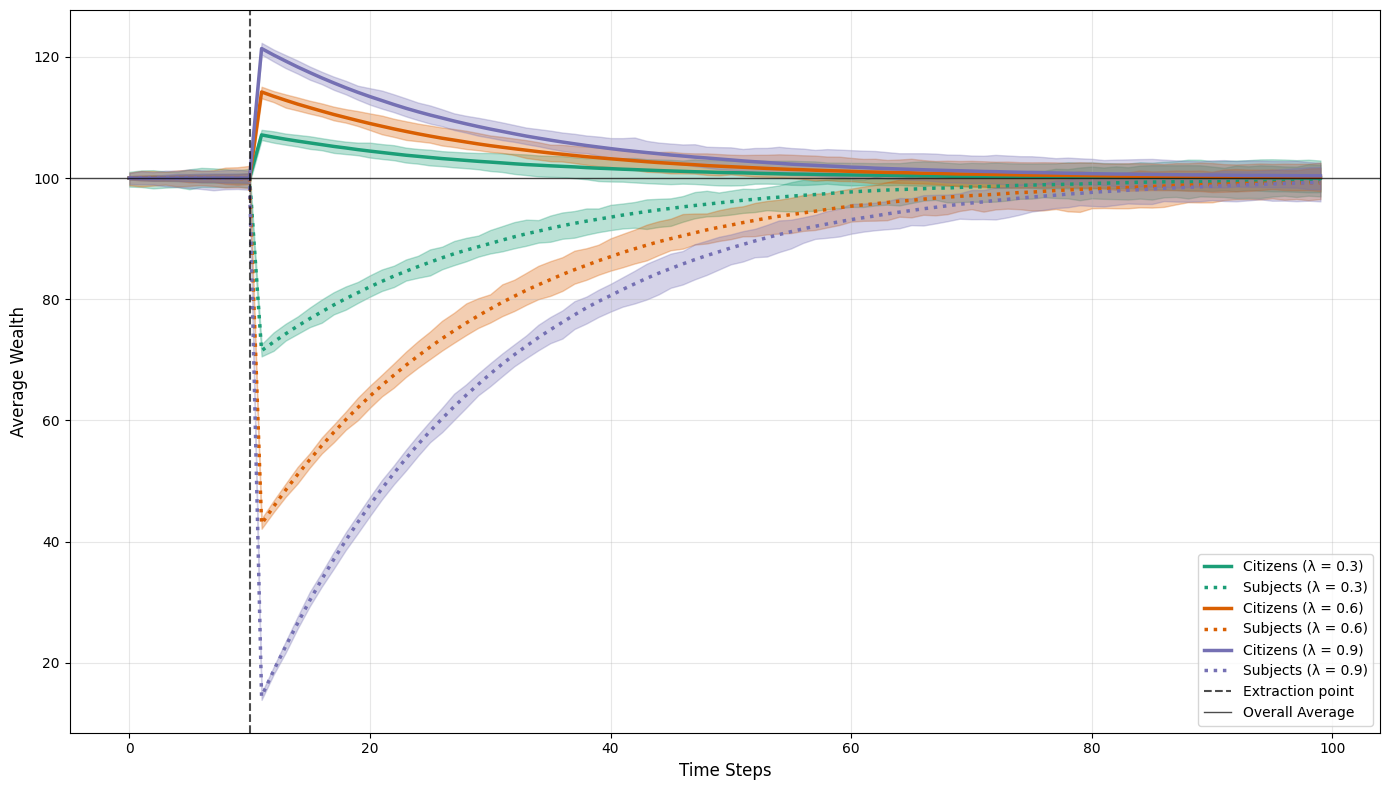

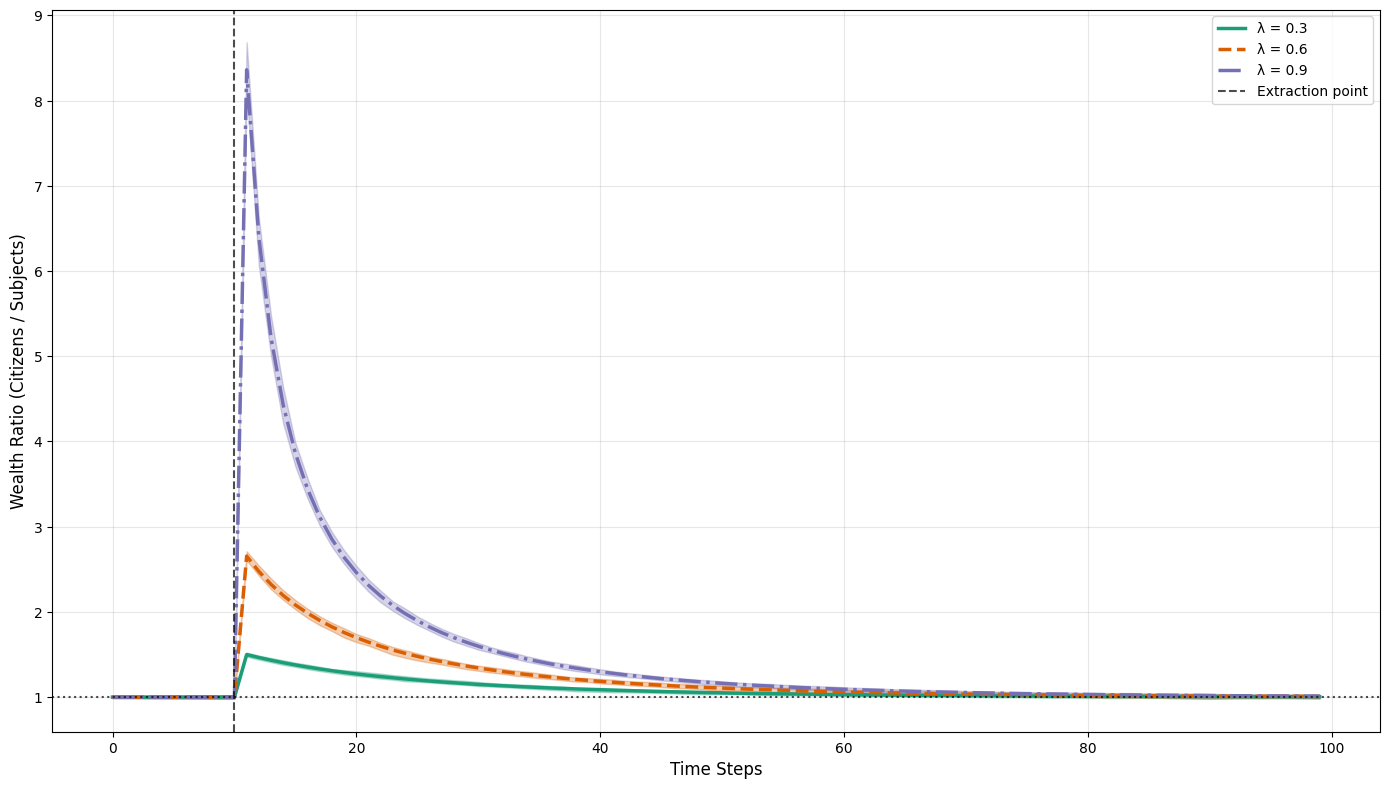

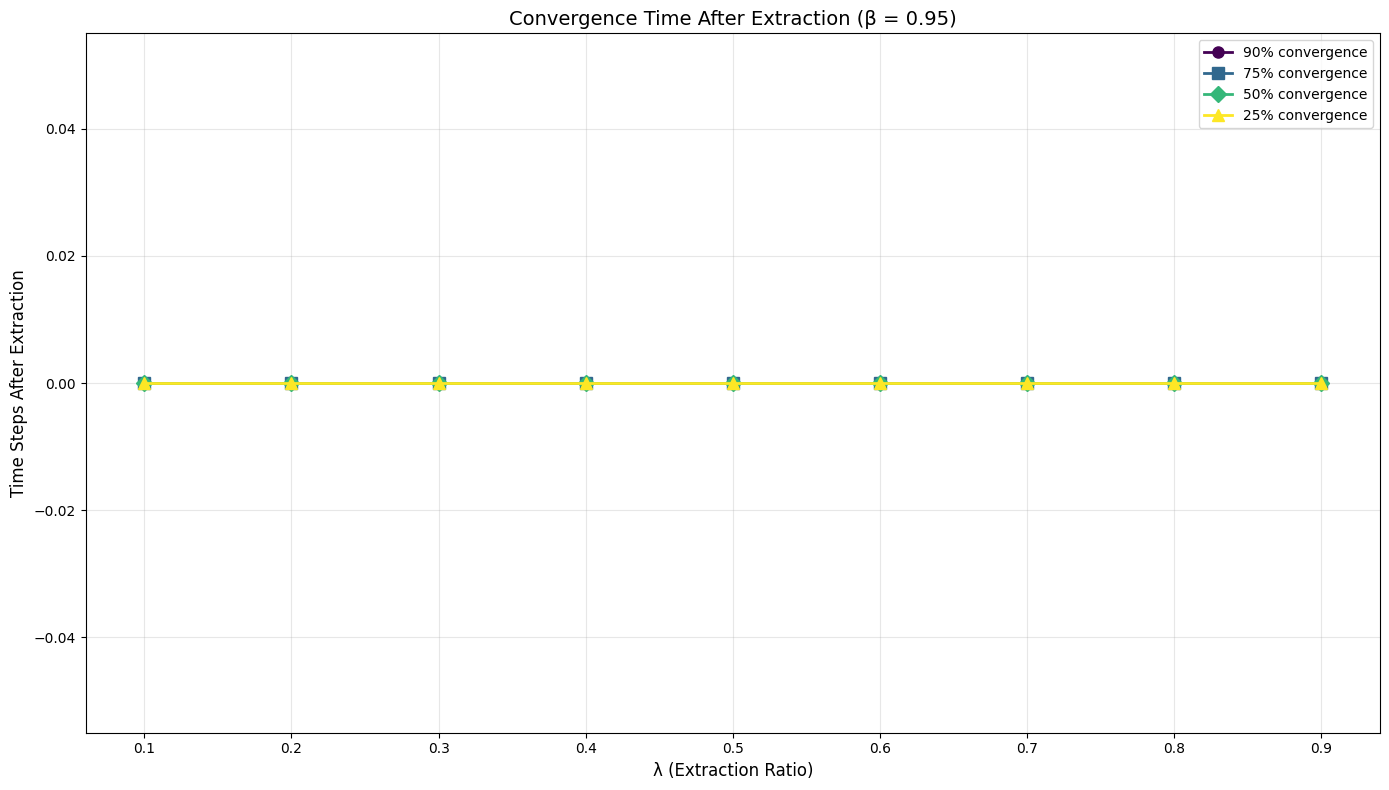

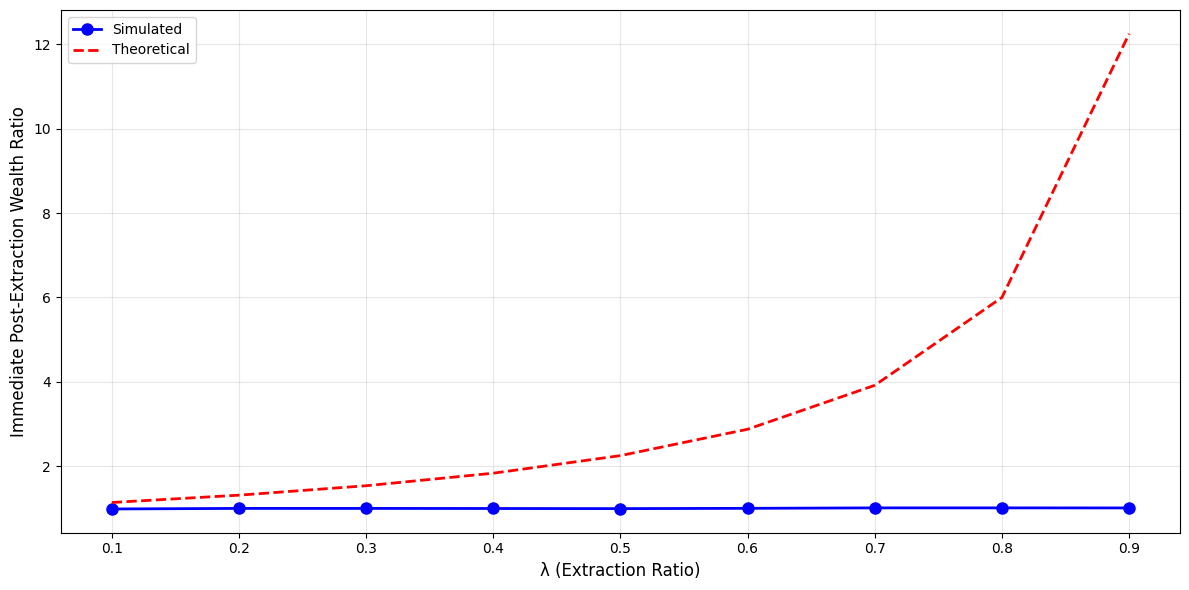

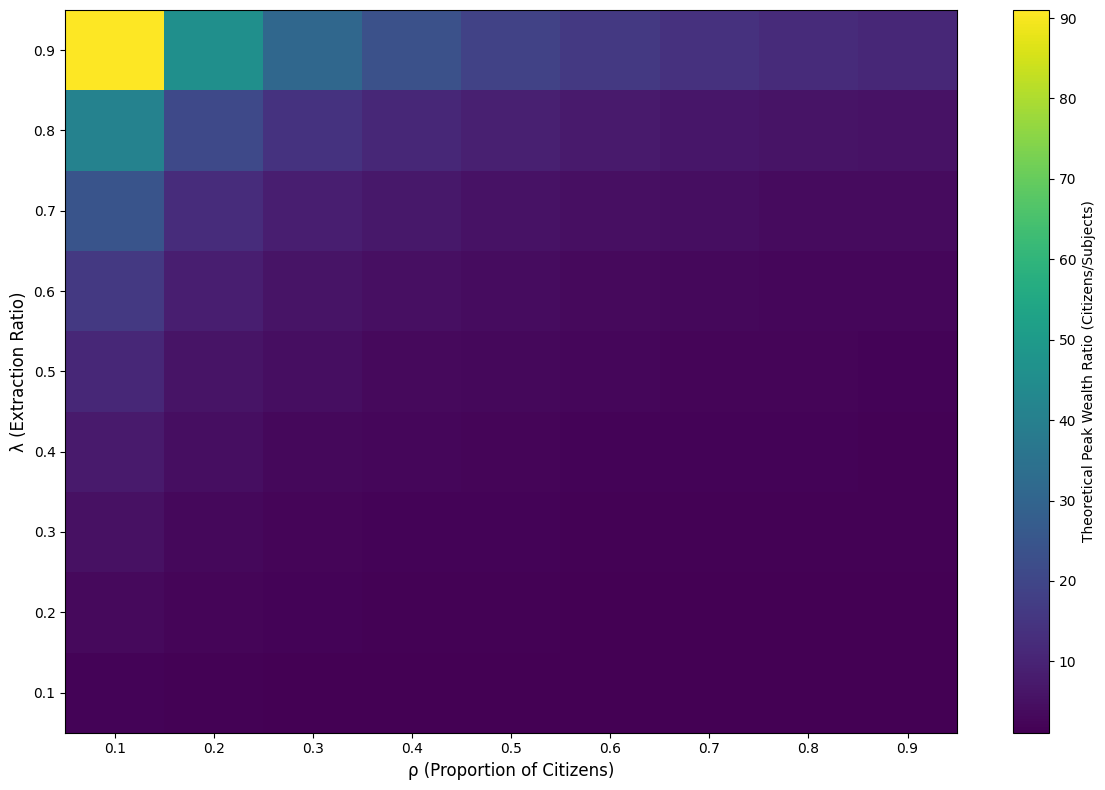

Simulation parameters:
- Number of agents: 10000
- Proportion of citizens (ρ): 0.8
- Extraction occurs at time step: 10
- Initial average wealth: 100
- β (wealth retention): 0.95

Peak wealth ratios after extraction:
λ = 0.3:
  - Peak ratio: 1.49 (at time step 11)
  - Immediate post-extraction ratio: 1.00
  - Final ratio (t=99): 1.01
  - Theoretical immediate post-extraction ratio: 1.54
  - Theoretical half-life with β = 0.95: 13.51 time steps

λ = 0.6:
  - Peak ratio: 2.68 (at time step 11)
  - Immediate post-extraction ratio: 1.01
  - Final ratio (t=99): 1.02
  - Theoretical immediate post-extraction ratio: 2.88
  - Theoretical half-life with β = 0.95: 13.51 time steps

λ = 0.9:
  - Peak ratio: 8.45 (at time step 11)
  - Immediate post-extraction ratio: 1.00
  - Final ratio (t=99): 1.00
  - Theoretical immediate post-extraction ratio: 12.25
  - Theoretical half-life with β = 0.95: 13.51 time steps



In [25]:
import numpy as np
import matplotlib.pyplot as plt

# Simulation parameters
n_agents = 10000  # total number of agents
n_timesteps = 100  # number of iterations
n_runs = 100  # number of simulation runs
initial_wealth_mean = 100  # average initial wealth
epsilon_sigma = 10  # standard deviation for random shocks
beta = 0.95  # fixed retention rate
extraction_step = 10  # time step at which extraction occurs
rho = 0.8  # proportion of citizens in the population
lambda_values = [0.3, 0.6, 0.9]  # extraction ratios to simulate

# Function to run a single simulation with specific beta and lambda values
def run_simulation(beta, lambda_extraction, n_runs, n_agents, n_timesteps, initial_wealth_mean, 
                  epsilon_sigma, extraction_step, rho):
    # Arrays to store group wealth over time for all runs
    all_citizens_wealth = np.zeros((n_runs, n_timesteps))
    all_subjects_wealth = np.zeros((n_runs, n_timesteps))
    all_avg_wealth = np.zeros((n_runs, n_timesteps))
    
    for run in range(n_runs):
        # Initialize citizens and subjects with same initial wealth distribution
        n_citizens = int(n_agents * rho)
        n_subjects = n_agents - n_citizens
        
        # Initially give everyone the same average wealth (random around mean)
        wealth = np.random.lognormal(mean=np.log(initial_wealth_mean), sigma=0.2, size=n_agents)
        
        # Normalize to ensure overall average is exactly initial_wealth_mean
        wealth = wealth * (initial_wealth_mean / wealth.mean())
        
        # Keep track of group membership
        citizens_indices = np.arange(n_citizens)
        subjects_indices = np.arange(n_citizens, n_agents)
        
        # Arrays to store group wealth over time
        citizens_wealth = np.zeros(n_timesteps)
        subjects_wealth = np.zeros(n_timesteps)
        avg_wealth = np.zeros(n_timesteps)
        
        for t in range(n_timesteps):
            # Record current group averages
            citizens_wealth[t] = wealth[citizens_indices].mean()
            subjects_wealth[t] = wealth[subjects_indices].mean()
            avg_wealth[t] = wealth.mean()
            
            # Extraction happens at the defined step
            if t == extraction_step:
                # Calculate total wealth extracted from subjects
                extracted_total = wealth[subjects_indices].sum() * lambda_extraction
                
                # Reduce subjects' wealth by extracted amount
                wealth[subjects_indices] = wealth[subjects_indices] * (1 - lambda_extraction)
                
                # Distribute extracted wealth equally among citizens
                wealth[citizens_indices] += extracted_total / n_citizens
            
            # Generate random shocks
            epsilon = np.random.normal(0, epsilon_sigma, n_agents)
            
            # Update wealth for next time step: W_i(t+1) = β W_i(t) + (1-β) W̄_t + ε_i
            # This applies after extraction has been processed for the current time step
            wealth = beta * wealth + (1 - beta) * avg_wealth[t] + epsilon
        
        all_citizens_wealth[run] = citizens_wealth
        all_subjects_wealth[run] = subjects_wealth
        all_avg_wealth[run] = avg_wealth
    
    return all_citizens_wealth, all_subjects_wealth, all_avg_wealth

# Plot wealth over time for different lambda values with fixed beta
plt.figure(figsize=(14, 8))

# Define colors that work well in both color and grayscale printing
colors = ['#1b9e77', '#d95f02', '#7570b3']  # colorblind-friendly palette

# Run simulations and plot for each lambda value
for idx, lambda_extraction in enumerate(lambda_values):
    # Run simulation
    all_citizens_wealth, all_subjects_wealth, all_avg_wealth = run_simulation(
        beta, lambda_extraction, n_runs, n_agents, n_timesteps, 
        initial_wealth_mean, epsilon_sigma, extraction_step, rho
    )
    
    # Calculate mean, min, and max for each group across all runs
    mean_citizens_wealth = np.mean(all_citizens_wealth, axis=0)
    min_citizens_wealth = np.min(all_citizens_wealth, axis=0)
    max_citizens_wealth = np.max(all_citizens_wealth, axis=0)
    
    mean_subjects_wealth = np.mean(all_subjects_wealth, axis=0)
    min_subjects_wealth = np.min(all_subjects_wealth, axis=0)
    max_subjects_wealth = np.max(all_subjects_wealth, axis=0)
    
    # Plot Citizens with solid line
    plt.plot(mean_citizens_wealth, 
             label=f'Citizens (λ = {lambda_extraction})', 
             color=colors[idx],
             linestyle='-',
             linewidth=2.5)
    
    plt.fill_between(range(n_timesteps), 
                     min_citizens_wealth, 
                     max_citizens_wealth, 
                     color=colors[idx], 
                     alpha=0.3)
    
    # Plot Subjects with dotted line
    plt.plot(mean_subjects_wealth, 
             label=f'Subjects (λ = {lambda_extraction})', 
             color=colors[idx],
             linestyle=':',
             linewidth=2.5)
    
    plt.fill_between(range(n_timesteps), 
                     min_subjects_wealth, 
                     max_subjects_wealth, 
                     color=colors[idx], 
                     alpha=0.3)

# Add vertical line at extraction step
plt.axvline(x=extraction_step, 
            color='black', 
            linestyle='--', 
            linewidth=1.5,
            alpha=0.7,
            label='Extraction point')

# Plot the overall average wealth
plt.axhline(y=initial_wealth_mean, 
         label='Overall Average', 
         color='black', 
         linestyle='-', 
         linewidth=1.0,
         alpha=0.7)

plt.xlabel('Time Steps', fontsize=12)
plt.ylabel('Average Wealth', fontsize=12)
plt.grid(True, alpha=0.3)
plt.legend(loc='best', fontsize=10)
plt.tight_layout()
plt.savefig('wealth_extraction_lambda.png', dpi=300)
plt.show()

# Now create a plot showing the wealth ratio over time for different lambda values
plt.figure(figsize=(14, 8))

# Colorblind-friendly and print-friendly palette
colors = ['#1b9e77', '#d95f02', '#7570b3']
line_styles = ['-', '--', '-.']

for idx, lambda_extraction in enumerate(lambda_values):
    # Run simulation
    all_citizens_wealth, all_subjects_wealth, _ = run_simulation(
        beta, lambda_extraction, n_runs, n_agents, n_timesteps, 
        initial_wealth_mean, epsilon_sigma, extraction_step, rho
    )
    
    # Calculate ratios for each run individually to properly display variance
    all_ratios = np.zeros((n_runs, n_timesteps))
    for run in range(n_runs):
        all_ratios[run] = all_citizens_wealth[run] / all_subjects_wealth[run]
    
    # Calculate mean, min, and max ratios
    mean_ratio = np.mean(all_ratios, axis=0)
    min_ratio = np.min(all_ratios, axis=0)
    max_ratio = np.max(all_ratios, axis=0)
    
    # Plot wealth ratio
    plt.plot(mean_ratio, 
             label=f'λ = {lambda_extraction}', 
             linewidth=2.5, 
             color=colors[idx], 
             linestyle=line_styles[idx])
    
    plt.fill_between(range(n_timesteps), min_ratio, max_ratio, color=colors[idx], alpha=0.3)

# Add vertical line at extraction step
plt.axvline(x=extraction_step, 
            color='black', 
            linestyle='--', 
            linewidth=1.5,
            alpha=0.7,
            label='Extraction point')

plt.xlabel('Time Steps', fontsize=12)
plt.ylabel('Wealth Ratio (Citizens / Subjects)', fontsize=12)
plt.legend(loc='best', fontsize=10)
plt.grid(True, alpha=0.3)
plt.axhline(y=1, color='black', linestyle=':', alpha=0.7)
plt.tight_layout()
plt.savefig('wealth_ratio_extraction.png', dpi=300)
plt.show()

# Remove the beta comparison plot and create a different visualization
# Let's focus on analyzing the convergence time after extraction

plt.figure(figsize=(14, 8))

# Run simulations for different lambda values and calculate how long it takes
# to reach different levels of convergence (90%, 75%, 50%, 25% of initial gap)
lambda_values_extended = [0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9]
convergence_levels = [0.9, 0.75, 0.5, 0.25]
convergence_times = np.zeros((len(convergence_levels), len(lambda_values_extended)))

for idx, lambda_extraction in enumerate(lambda_values_extended):
    # Run simulation with fewer runs for efficiency
    all_citizens_wealth, all_subjects_wealth, _ = run_simulation(
        beta, lambda_extraction, 10, n_agents, n_timesteps, 
        initial_wealth_mean, epsilon_sigma, extraction_step, rho
    )
    
    # Calculate average wealth ratio
    mean_citizens_wealth = np.mean(all_citizens_wealth, axis=0)
    mean_subjects_wealth = np.mean(all_subjects_wealth, axis=0)
    ratio = mean_citizens_wealth / mean_subjects_wealth
    
    # Find post-extraction peak ratio
    post_extraction_ratios = ratio[extraction_step:]
    peak_ratio = np.max(post_extraction_ratios)
    
    # Calculate initial gap after extraction
    initial_gap = peak_ratio - 1.0
    
    # Find time to reach different convergence levels
    for level_idx, level in enumerate(convergence_levels):
        target_ratio = 1.0 + initial_gap * level
        
        # Find first time gap is smaller than target
        times_below_target = np.where(post_extraction_ratios < target_ratio)[0]
        
        if len(times_below_target) > 0:
            convergence_time = times_below_target[0]
        else:
            convergence_time = n_timesteps - extraction_step  # Not reached
            
        convergence_times[level_idx, idx] = convergence_time

# Plot convergence times
colors = plt.cm.viridis(np.linspace(0, 1, len(convergence_levels)))
markers = ['o', 's', 'D', '^']

for i, level in enumerate(convergence_levels):
    plt.plot(lambda_values_extended, convergence_times[i], 
             label=f'{int(level*100)}% convergence',
             color=colors[i], 
             marker=markers[i], 
             linewidth=2, 
             markersize=8)

plt.xlabel('λ (Extraction Ratio)', fontsize=12)
plt.ylabel('Time Steps After Extraction', fontsize=12)
plt.title(f'Convergence Time After Extraction (β = {beta})', fontsize=14)
plt.grid(True, alpha=0.3)
plt.legend(loc='best', fontsize=10)
plt.tight_layout()
plt.savefig('convergence_time_lambda.png', dpi=300)
plt.show()

# Create a visualization of the immediate post-extraction wealth ratio
immediate_ratios = []
theoretical_ratios = []

for lambda_extraction in lambda_values_extended:
    # Run a single simulation
    citizens_wealth, subjects_wealth, _ = run_simulation(
        beta, lambda_extraction, 1, n_agents, n_timesteps, 
        initial_wealth_mean, epsilon_sigma, extraction_step, rho
    )
    
    # Record immediate post-extraction ratio
    immediate_ratio = citizens_wealth[0, extraction_step] / subjects_wealth[0, extraction_step]
    immediate_ratios.append(immediate_ratio)
    
    # Calculate theoretical ratio
    # Each subject loses λ proportion of wealth
    post_extraction_subjects = initial_wealth_mean * (1 - lambda_extraction)
    
    # Each citizen gains an equal share of the extracted wealth from subjects
    extracted_wealth_per_citizen = lambda_extraction * initial_wealth_mean * (1-rho) / rho
    post_extraction_citizens = initial_wealth_mean + extracted_wealth_per_citizen
    
    theoretical_ratio = post_extraction_citizens / post_extraction_subjects
    theoretical_ratios.append(theoretical_ratio)

plt.figure(figsize=(12, 6))
plt.plot(lambda_values_extended, immediate_ratios, 'bo-', linewidth=2, markersize=8, label='Simulated')
plt.plot(lambda_values_extended, theoretical_ratios, 'r--', linewidth=2, label='Theoretical')

plt.xlabel('λ (Extraction Ratio)', fontsize=12)
plt.ylabel('Immediate Post-Extraction Wealth Ratio', fontsize=12)
plt.grid(True, alpha=0.3)
plt.legend(fontsize=10)
plt.tight_layout()
plt.savefig('immediate_ratio_lambda.png', dpi=300)
plt.show()

# Create a heatmap showing the peak wealth ratio for different combinations of rho and lambda
rho_range = np.linspace(0.1, 0.9, 9)  # Proportion of citizens
lambda_range = np.linspace(0.1, 0.9, 9)  # Extraction ratio
peak_ratios = np.zeros((len(lambda_range), len(rho_range)))
theoretical_ratios = np.zeros((len(lambda_range), len(rho_range)))

# Calculate theoretical and simulated peak ratios
for i, lambda_extraction in enumerate(lambda_range):
    for j, citizen_ratio in enumerate(rho_range):
        # Calculate theoretical ratio
        post_extraction_subjects = initial_wealth_mean * (1 - lambda_extraction)
        extracted_wealth_per_citizen = lambda_extraction * initial_wealth_mean * (1-citizen_ratio) / citizen_ratio
        post_extraction_citizens = initial_wealth_mean + extracted_wealth_per_citizen
        theoretical_ratios[i, j] = post_extraction_citizens / post_extraction_subjects
        
        # Run simplified simulation with just one run
        all_citizens_wealth, all_subjects_wealth, _ = run_simulation(
            beta, lambda_extraction, 1, n_agents, n_timesteps, 
            initial_wealth_mean, epsilon_sigma, extraction_step, citizen_ratio
        )
        
        # Calculate mean ratio
        ratio = all_citizens_wealth[0] / all_subjects_wealth[0]
        
        # Store peak ratio after extraction
        peak_ratios[i, j] = np.max(ratio[extraction_step:])

# Plot heatmap of theoretical ratios
plt.figure(figsize=(12, 8))
heatmap = plt.imshow(theoretical_ratios, cmap='viridis', aspect='auto', origin='lower')
plt.colorbar(heatmap, label='Theoretical Peak Wealth Ratio (Citizens/Subjects)')

# Set tick labels
rho_labels = [f'{rho:.1f}' for rho in rho_range]
lambda_labels = [f'{lambda_val:.1f}' for lambda_val in lambda_range]
plt.xticks(np.arange(len(rho_range)), rho_labels)
plt.yticks(np.arange(len(lambda_range)), lambda_labels)

plt.xlabel('ρ (Proportion of Citizens)', fontsize=12)
plt.ylabel('λ (Extraction Ratio)', fontsize=12)
plt.tight_layout()
plt.savefig('theoretical_peak_ratio_heatmap.png', dpi=300)
plt.show()

# Print some key statistics
print(f"Simulation parameters:")
print(f"- Number of agents: {n_agents}")
print(f"- Proportion of citizens (ρ): {rho}")
print(f"- Extraction occurs at time step: {extraction_step}")
print(f"- Initial average wealth: {initial_wealth_mean}")
print(f"- β (wealth retention): {beta}")
print("\nPeak wealth ratios after extraction:")

for lambda_extraction in lambda_values:
    citizens_wealth, subjects_wealth, _ = run_simulation(
        beta, lambda_extraction, 1, n_agents, n_timesteps, 
        initial_wealth_mean, epsilon_sigma, extraction_step, rho
    )
    
    ratio = citizens_wealth[0] / subjects_wealth[0]
    max_ratio = np.max(ratio[extraction_step:])
    max_ratio_time = np.argmax(ratio[extraction_step:]) + extraction_step
    
    print(f"λ = {lambda_extraction}:")
    print(f"  - Peak ratio: {max_ratio:.2f} (at time step {max_ratio_time})")
    print(f"  - Immediate post-extraction ratio: {ratio[extraction_step]:.2f}")
    print(f"  - Final ratio (t={n_timesteps-1}): {ratio[-1]:.2f}")
    
    # Calculate theoretical post-extraction wealth
    pre_extraction_citizens = initial_wealth_mean
    pre_extraction_subjects = initial_wealth_mean
    
    # Each subject loses λ proportion of wealth
    post_extraction_subjects = pre_extraction_subjects * (1 - lambda_extraction)
    
    # Each citizen gains an equal share of the extracted wealth from subjects
    extracted_wealth_per_citizen = lambda_extraction * pre_extraction_subjects * (1-rho) / rho
    post_extraction_citizens = pre_extraction_citizens + extracted_wealth_per_citizen
    
    theoretical_ratio = post_extraction_citizens / post_extraction_subjects
    print(f"  - Theoretical immediate post-extraction ratio: {theoretical_ratio:.2f}")
    
    # Calculate theoretical half-life
    halflife = -np.log(2)/np.log(beta)
    print(f"  - Theoretical half-life with β = {beta}: {halflife:.2f} time steps")
    print()

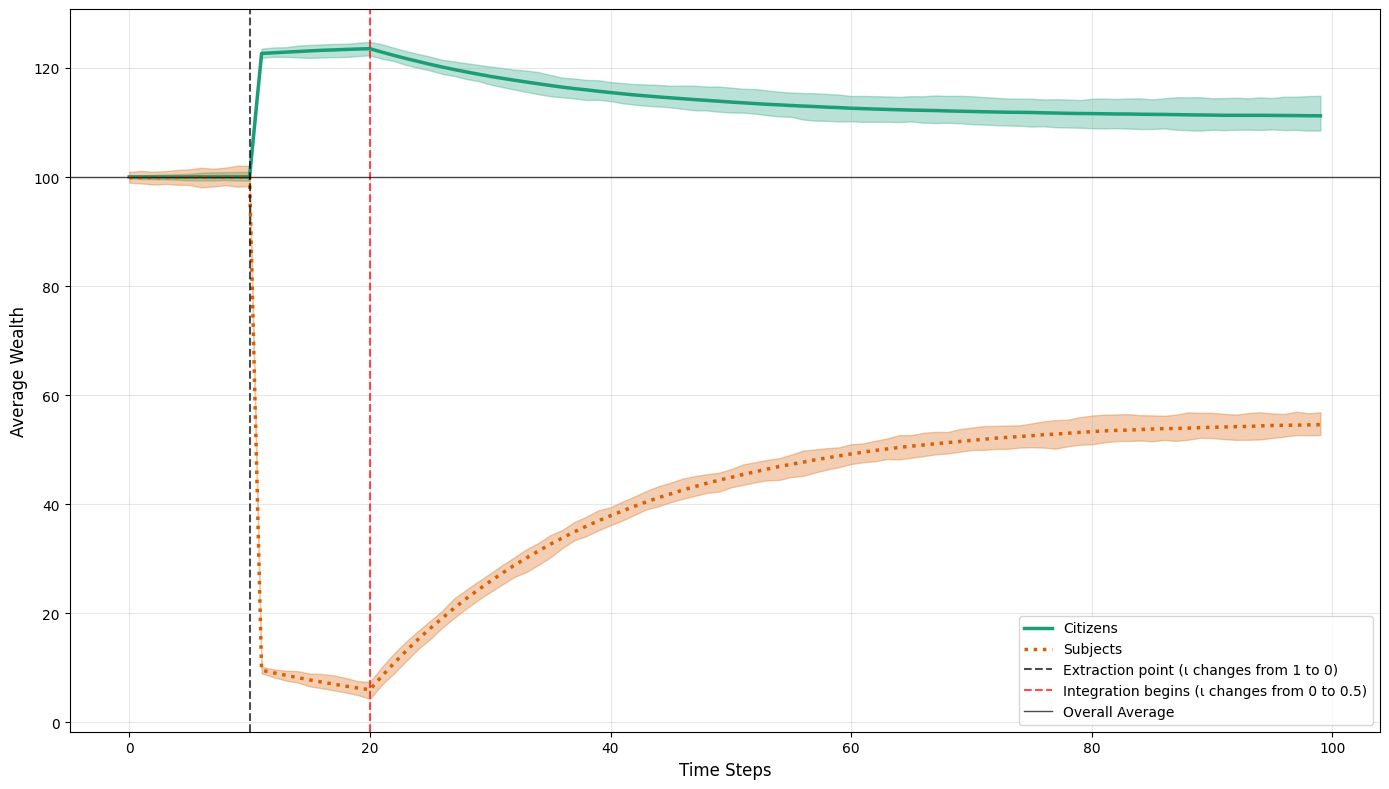

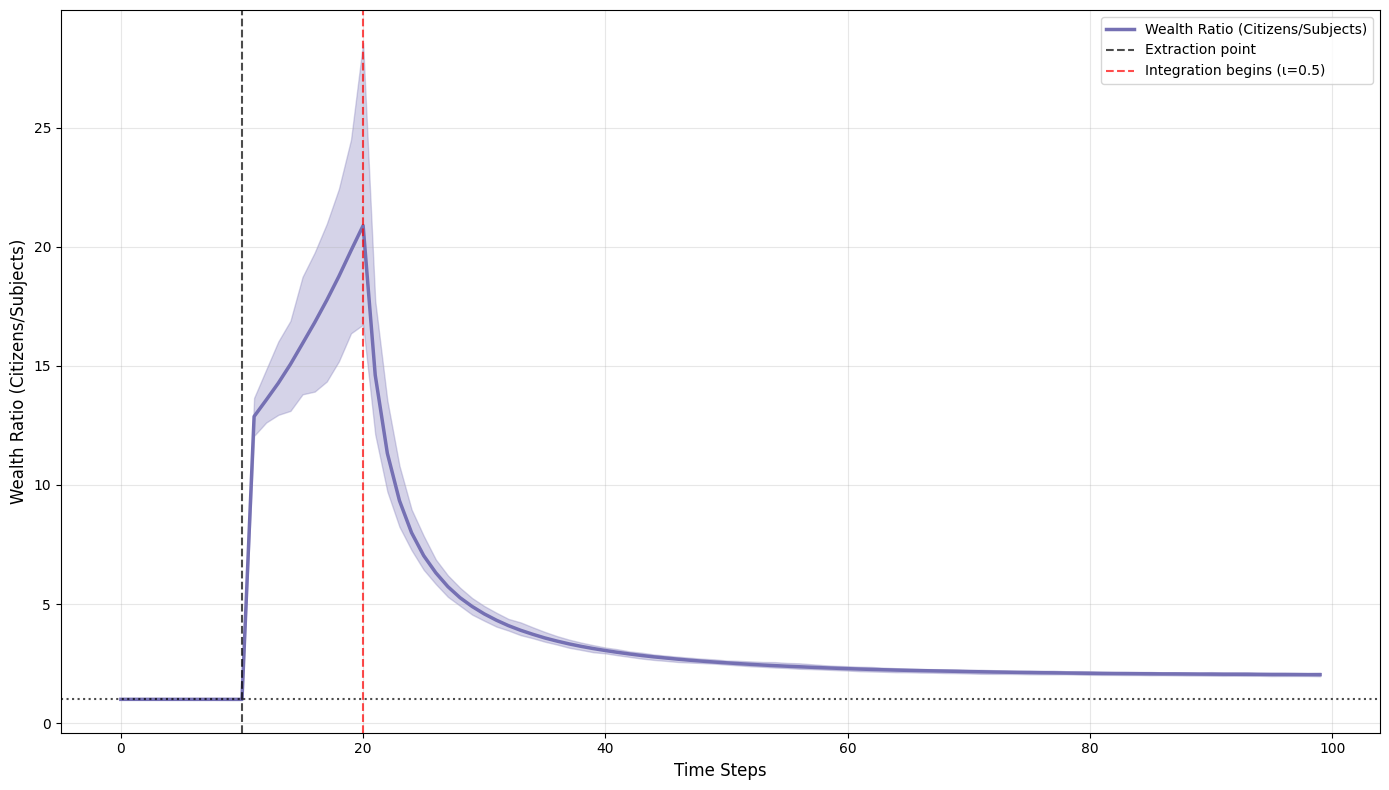

Simulation parameters:
- Number of agents: 10000
- Proportion of citizens (ρ): 0.8
- Extraction occurs at time step: 10
- Integration begins at time step: 20
- Initial average wealth: 100
- β (wealth retention): 0.95
- λ (extraction ratio): 0.9
- ι (integration parameter): 0.5

Key results:
- Theoretical immediate post-extraction ratio: 12.25
- Simulated immediate post-extraction ratio: 1.00
- Peak wealth ratio: 20.89 (at time step 20)
- Ratio at integration start: 20.89
- Final wealth ratio: 2.04


In [30]:
import numpy as np
import matplotlib.pyplot as plt

# Simulation parameters
n_agents = 10000  # total number of agents
n_timesteps = 100  # number of iterations
n_runs = 100  # number of simulation runs
initial_wealth_mean = 100  # average initial wealth
epsilon_sigma = 10  # standard deviation for random shocks
beta = 0.95  # fixed retention rate
extraction_step = 10  # time step at which extraction occurs
integration_step = 20  # time step at which integration begins (10 years after extraction)
rho = 0.8  # proportion of citizens in the population
lambda_extraction = 0.9  # extraction ratio
iota = 0.5  # integration parameter (subject share of redistributed wealth)

# Colorblind-friendly palette (same as in the provided code)
colors = ['#1b9e77', '#d95f02', '#7570b3'] 

# Function to run a single simulation with integration
def run_simulation(beta, lambda_extraction, iota, integration_step, n_runs, n_agents, 
                  n_timesteps, initial_wealth_mean, epsilon_sigma, extraction_step, rho):
    # Arrays to store group wealth over time for all runs
    all_citizens_wealth = np.zeros((n_runs, n_timesteps))
    all_subjects_wealth = np.zeros((n_runs, n_timesteps))
    all_avg_wealth = np.zeros((n_runs, n_timesteps))
    all_wealth_ratios = np.zeros((n_runs, n_timesteps))
    
    for run in range(n_runs):
        # Initialize citizens and subjects with same initial wealth distribution
        n_citizens = int(n_agents * rho)
        n_subjects = n_agents - n_citizens
        
        # Initially give everyone the same average wealth (random around mean)
        wealth = np.random.lognormal(mean=np.log(initial_wealth_mean), sigma=0.2, size=n_agents)
        
        # Normalize to ensure overall average is exactly initial_wealth_mean
        wealth = wealth * (initial_wealth_mean / wealth.mean())
        
        # Keep track of group membership
        citizens_indices = np.arange(n_citizens)
        subjects_indices = np.arange(n_citizens, n_agents)
        
        # Arrays to store group wealth over time
        citizens_wealth = np.zeros(n_timesteps)
        subjects_wealth = np.zeros(n_timesteps)
        avg_wealth = np.zeros(n_timesteps)
        wealth_ratios = np.zeros(n_timesteps)
        
        for t in range(n_timesteps):
            # Record current group averages
            citizens_wealth[t] = wealth[citizens_indices].mean()
            subjects_wealth[t] = wealth[subjects_indices].mean()
            avg_wealth[t] = wealth.mean()
            wealth_ratios[t] = citizens_wealth[t] / subjects_wealth[t]
            
            # Extraction happens at the defined step
            if t == extraction_step:
                # Calculate total wealth extracted from subjects
                extracted_total = wealth[subjects_indices].sum() * lambda_extraction
                
                # Reduce subjects' wealth by extracted amount
                wealth[subjects_indices] = wealth[subjects_indices] * (1 - lambda_extraction)
                
                # Distribute extracted wealth equally among citizens
                wealth[citizens_indices] += extracted_total / n_citizens
            
            # Generate random shocks
            epsilon = np.random.normal(0, epsilon_sigma, n_agents)
            
            # Calculate social pool as (1-beta) of everyone's wealth
            social_pool = (1 - beta) * wealth.sum()
            
            # Retain beta proportion of individual wealth
            wealth = beta * wealth
            
            # Apply random shocks
            wealth = wealth + epsilon
            
            # Redistribute social wealth based on integration parameter
            if t >= integration_step:
                # After integration begins, use iota = 0.5
                current_iota = iota
            elif t >= extraction_step:
                # After extraction but before integration, use iota = 0
                current_iota = 0
            else:
                # Before extraction, use iota = 1 (equal redistribution)
                current_iota = 1
                
            # Calculate shares based on current iota value
            total_shares = n_citizens + current_iota * n_subjects
            per_capita_citizen = social_pool / total_shares
            per_capita_subject = current_iota * (social_pool / total_shares)
            
            # Distribute social wealth
            wealth[citizens_indices] += per_capita_citizen
            wealth[subjects_indices] += per_capita_subject
        
        all_citizens_wealth[run] = citizens_wealth
        all_subjects_wealth[run] = subjects_wealth
        all_avg_wealth[run] = avg_wealth
        all_wealth_ratios[run] = wealth_ratios
    
    return all_citizens_wealth, all_subjects_wealth, all_avg_wealth, all_wealth_ratios

# Run the simulation
all_citizens_wealth, all_subjects_wealth, all_avg_wealth, all_wealth_ratios = run_simulation(
    beta, lambda_extraction, iota, integration_step, n_runs, n_agents, 
    n_timesteps, initial_wealth_mean, epsilon_sigma, extraction_step, rho
)

# Calculate mean, min, and max for each group across all runs
mean_citizens_wealth = np.mean(all_citizens_wealth, axis=0)
min_citizens_wealth = np.min(all_citizens_wealth, axis=0)
max_citizens_wealth = np.max(all_citizens_wealth, axis=0)

mean_subjects_wealth = np.mean(all_subjects_wealth, axis=0)
min_subjects_wealth = np.min(all_subjects_wealth, axis=0)
max_subjects_wealth = np.max(all_subjects_wealth, axis=0)

mean_wealth_ratio = np.mean(all_wealth_ratios, axis=0)
min_wealth_ratio = np.min(all_wealth_ratios, axis=0)
max_wealth_ratio = np.max(all_wealth_ratios, axis=0)

# Plot wealth over time
plt.figure(figsize=(14, 8))

# Plot Citizens with solid line
plt.plot(mean_citizens_wealth, 
         label='Citizens', 
         color=colors[0],
         linestyle='-',
         linewidth=2.5)

plt.fill_between(range(n_timesteps), 
                 min_citizens_wealth, 
                 max_citizens_wealth, 
                 color=colors[0], 
                 alpha=0.3)

# Plot Subjects with dotted line
plt.plot(mean_subjects_wealth, 
         label='Subjects', 
         color=colors[1],
         linestyle=':',
         linewidth=2.5)

plt.fill_between(range(n_timesteps), 
                 min_subjects_wealth, 
                 max_subjects_wealth, 
                 color=colors[1], 
                 alpha=0.3)

# Add vertical lines at key events
plt.axvline(x=extraction_step, 
            color='black', 
            linestyle='--', 
            linewidth=1.5,
            alpha=0.7,
            label='Extraction point (ι changes from 1 to 0)')

plt.axvline(x=integration_step, 
            color='red', 
            linestyle='--', 
            linewidth=1.5,
            alpha=0.7,
            label='Integration begins (ι changes from 0 to 0.5)')

# Plot the overall average wealth
plt.axhline(y=initial_wealth_mean, 
         label='Overall Average', 
         color='black', 
         linestyle='-', 
         linewidth=1.0,
         alpha=0.7)

plt.xlabel('Time Steps', fontsize=12)
plt.ylabel('Average Wealth', fontsize=12)
plt.grid(True, alpha=0.3)
plt.legend(loc='best', fontsize=10)
plt.tight_layout()
plt.show()

# Plot wealth ratio over time
plt.figure(figsize=(14, 8))

plt.plot(mean_wealth_ratio, 
         label=f'Wealth Ratio (Citizens/Subjects)', 
         color=colors[2],
         linewidth=2.5)

plt.fill_between(range(n_timesteps), 
                 min_wealth_ratio, 
                 max_wealth_ratio, 
                 color=colors[2], 
                 alpha=0.3)

# Add vertical lines at key events
plt.axvline(x=extraction_step, 
            color='black', 
            linestyle='--', 
            linewidth=1.5,
            alpha=0.7,
            label='Extraction point')

plt.axvline(x=integration_step, 
            color='red', 
            linestyle='--', 
            linewidth=1.5,
            alpha=0.7,
            label='Integration begins (ι=0.5)')

plt.xlabel('Time Steps', fontsize=12)
plt.ylabel('Wealth Ratio (Citizens/Subjects)', fontsize=12)
plt.grid(True, alpha=0.3)
plt.axhline(y=1, color='black', linestyle=':', alpha=0.7)
plt.legend(loc='best', fontsize=10)
plt.tight_layout()
plt.show()

# Calculate and print key statistics
print(f"Simulation parameters:")
print(f"- Number of agents: {n_agents}")
print(f"- Proportion of citizens (ρ): {rho}")
print(f"- Extraction occurs at time step: {extraction_step}")
print(f"- Integration begins at time step: {integration_step}")
print(f"- Initial average wealth: {initial_wealth_mean}")
print(f"- β (wealth retention): {beta}")
print(f"- λ (extraction ratio): {lambda_extraction}")
print(f"- ι (integration parameter): {iota}")

# Calculate theoretical immediate post-extraction ratio
pre_extraction_subjects = initial_wealth_mean
extracted_wealth_per_citizen = lambda_extraction * pre_extraction_subjects * (1-rho) / rho
post_extraction_citizens = initial_wealth_mean + extracted_wealth_per_citizen
post_extraction_subjects = pre_extraction_subjects * (1 - lambda_extraction)
theoretical_ratio = post_extraction_citizens / post_extraction_subjects

print("\nKey results:")
print(f"- Theoretical immediate post-extraction ratio: {theoretical_ratio:.2f}")
print(f"- Simulated immediate post-extraction ratio: {mean_wealth_ratio[extraction_step]:.2f}")
print(f"- Peak wealth ratio: {np.max(mean_wealth_ratio):.2f} (at time step {np.argmax(mean_wealth_ratio)})")
print(f"- Ratio at integration start: {mean_wealth_ratio[integration_step]:.2f}")
print(f"- Final wealth ratio: {mean_wealth_ratio[-1]:.2f}")

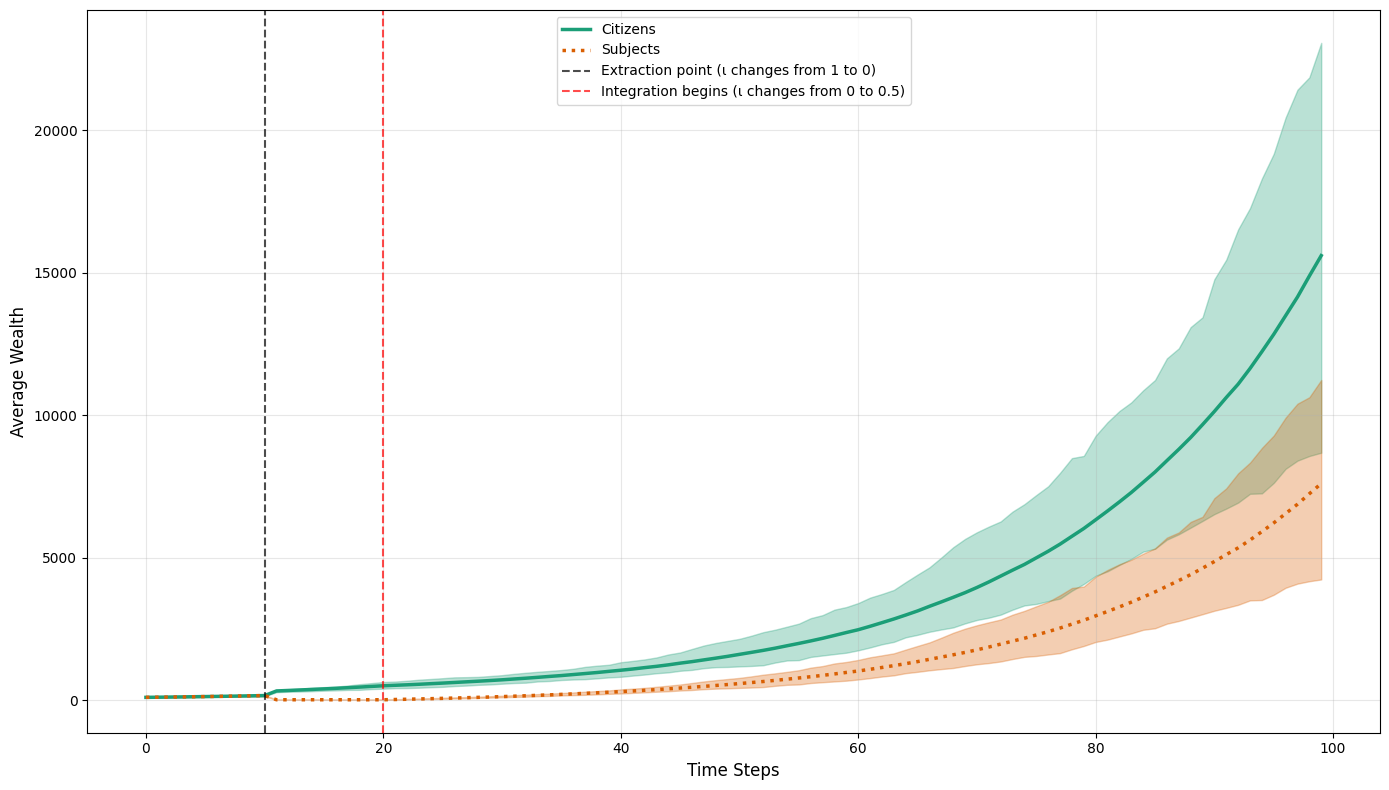

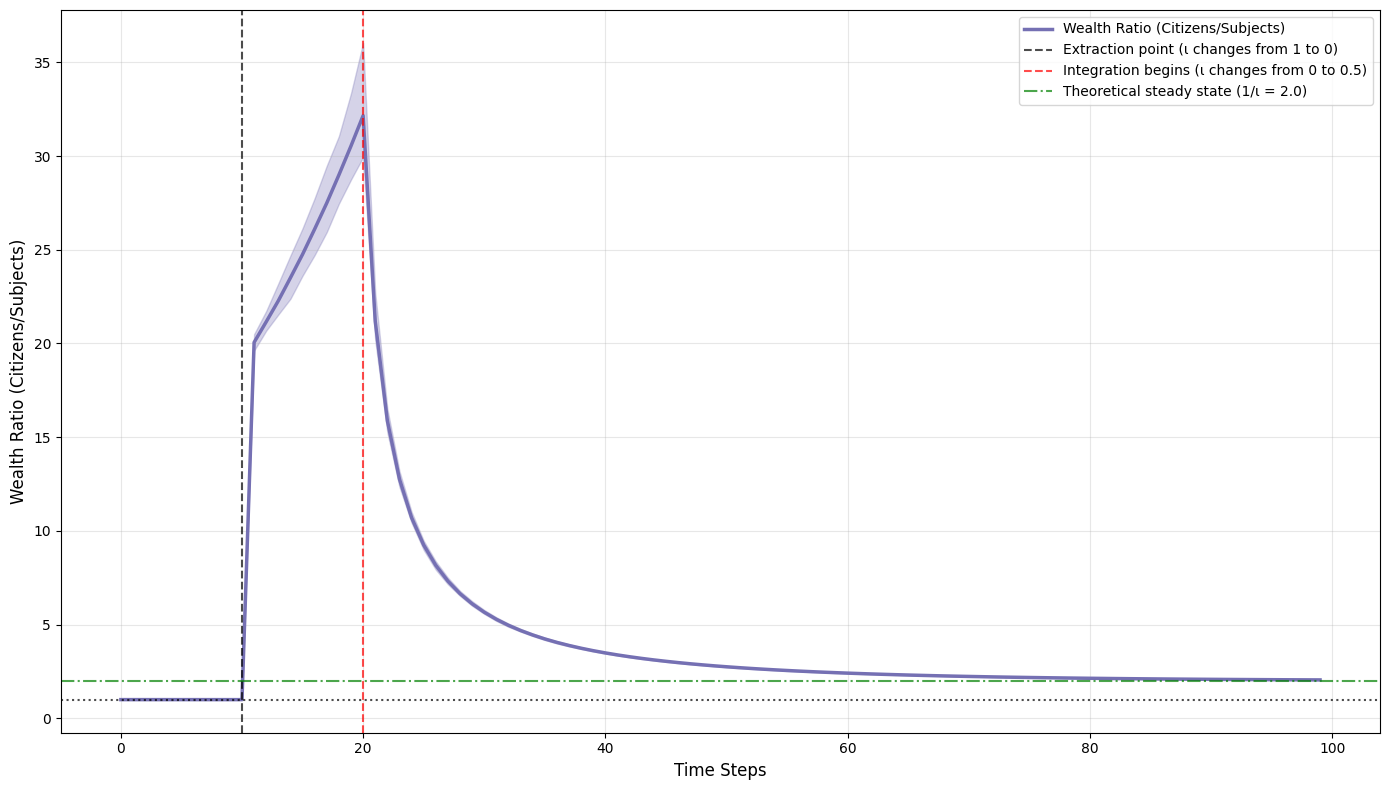

Simulation parameters:
- Number of agents: 10000
- Proportion of citizens (ρ): 0.5
- Extraction occurs at time step: 10
- Integration begins at time step: 20
- Initial average wealth: 100
- β (wealth retention): 0.95
- λ (extraction ratio): 0.9
- ι (integration parameter): 0.5
- r (return on individual wealth): mean = 0.05, std = 0.02
- g (growth of social wealth): mean = 0.03, std = 0.01

Key results:
- Theoretical immediate post-extraction ratio: 19.00
- Simulated immediate post-extraction ratio: 1.00
- Peak wealth ratio: 32.16 (at time step 20)
- Ratio at integration start: 32.16
- Final wealth ratio: 2.05
- Theoretical steady-state ratio (1/ι): 2.00
Simulation appears to have approached the theoretical steady state.


In [31]:
import numpy as np
import matplotlib.pyplot as plt

# Simulation parameters
n_agents = 10000  # total number of agents
n_timesteps = 100  # number of iterations
n_runs = 100  # number of simulation runs
initial_wealth_mean = 100  # average initial wealth
epsilon_sigma = 10  # standard deviation for random shocks
beta = 0.95  # fixed retention rate
extraction_step = 10  # time step at which extraction occurs
integration_step = 20  # time step at which integration begins (10 years after extraction)
rho = 0.5  # proportion of citizens in the population
lambda_extraction = 0.9  # extraction ratio
iota = 0.5  # integration parameter (subject share of redistributed wealth after integration)

# Growth and return parameters
r_mean = 0.05  # 5% mean return on individual wealth
r_sigma = 0.02  # standard deviation for r
g_mean = 0.03  # 3% mean growth rate for social wealth
g_sigma = 0.01  # standard deviation for g

# Colorblind-friendly palette
colors = ['#1b9e77', '#d95f02', '#7570b3'] 

# Function to run a single simulation with integration, growth, and returns
def run_simulation(beta, lambda_extraction, iota, integration_step, n_runs, n_agents, 
                  n_timesteps, initial_wealth_mean, epsilon_sigma, extraction_step, rho,
                  r_mean, r_sigma, g_mean, g_sigma):
    # Arrays to store group wealth over time for all runs
    all_citizens_wealth = np.zeros((n_runs, n_timesteps))
    all_subjects_wealth = np.zeros((n_runs, n_timesteps))
    all_avg_wealth = np.zeros((n_runs, n_timesteps))
    all_wealth_ratios = np.zeros((n_runs, n_timesteps))
    
    for run in range(n_runs):
        # Initialize citizens and subjects with same initial wealth distribution
        n_citizens = int(n_agents * rho)
        n_subjects = n_agents - n_citizens
        
        # Initially give everyone the same average wealth (random around mean)
        wealth = np.random.lognormal(mean=np.log(initial_wealth_mean), sigma=0.2, size=n_agents)
        
        # Normalize to ensure overall average is exactly initial_wealth_mean
        wealth = wealth * (initial_wealth_mean / wealth.mean())
        
        # Keep track of group membership
        citizens_indices = np.arange(n_citizens)
        subjects_indices = np.arange(n_citizens, n_agents)
        
        # Arrays to store group wealth over time
        citizens_wealth = np.zeros(n_timesteps)
        subjects_wealth = np.zeros(n_timesteps)
        avg_wealth = np.zeros(n_timesteps)
        wealth_ratios = np.zeros(n_timesteps)
        
        for t in range(n_timesteps):
            # Record current group averages
            citizens_wealth[t] = wealth[citizens_indices].mean()
            subjects_wealth[t] = wealth[subjects_indices].mean()
            avg_wealth[t] = wealth.mean()
            wealth_ratios[t] = citizens_wealth[t] / subjects_wealth[t]
            
            # Extraction happens at the defined step
            if t == extraction_step:
                # Calculate total wealth extracted from subjects
                extracted_total = wealth[subjects_indices].sum() * lambda_extraction
                
                # Reduce subjects' wealth by extracted amount
                wealth[subjects_indices] = wealth[subjects_indices] * (1 - lambda_extraction)
                
                # Distribute extracted wealth equally among citizens
                wealth[citizens_indices] += extracted_total / n_citizens
            
            # Generate random returns for individual wealth
            r = np.random.normal(r_mean, r_sigma)
            
            # Generate random growth rate for social wealth
            g = np.random.normal(g_mean, g_sigma)
            
            # Generate random shocks
            epsilon_citizens = np.random.normal(0, epsilon_sigma, n_citizens)
            epsilon_subjects = np.random.normal(0, epsilon_sigma, n_subjects)
            epsilon = np.concatenate([epsilon_citizens, epsilon_subjects])
            
            # Calculate social pool as (1-beta) of everyone's wealth
            social_pool = (1 - beta) * wealth.sum()
            
            # Grow social pool at rate g
            social_pool = social_pool * (1 + g)
            
            # Retain beta proportion of individual wealth and apply returns
            wealth = beta * wealth * (1 + r)
            
            # Apply random shocks
            wealth = wealth + epsilon
            
            # Determine integration parameter based on time period
            if t >= integration_step:
                # After integration begins, use iota = 0.5
                current_iota = iota
            elif t >= extraction_step:
                # After extraction but before integration, use iota = 0
                current_iota = 0
            else:
                # Before extraction, use iota = 1 (equal redistribution)
                current_iota = 1
                
            # Calculate shares based on current iota value
            total_shares = n_citizens + current_iota * n_subjects
            per_capita_citizen = social_pool / total_shares
            per_capita_subject = current_iota * (social_pool / total_shares)
            
            # Distribute social wealth
            wealth[citizens_indices] += per_capita_citizen
            wealth[subjects_indices] += per_capita_subject
        
        all_citizens_wealth[run] = citizens_wealth
        all_subjects_wealth[run] = subjects_wealth
        all_avg_wealth[run] = avg_wealth
        all_wealth_ratios[run] = wealth_ratios
    
    return all_citizens_wealth, all_subjects_wealth, all_avg_wealth, all_wealth_ratios

# Run the simulation
all_citizens_wealth, all_subjects_wealth, all_avg_wealth, all_wealth_ratios = run_simulation(
    beta, lambda_extraction, iota, integration_step, n_runs, n_agents, 
    n_timesteps, initial_wealth_mean, epsilon_sigma, extraction_step, rho,
    r_mean, r_sigma, g_mean, g_sigma
)

# Calculate mean, min, and max for each group across all runs
mean_citizens_wealth = np.mean(all_citizens_wealth, axis=0)
min_citizens_wealth = np.min(all_citizens_wealth, axis=0)
max_citizens_wealth = np.max(all_citizens_wealth, axis=0)

mean_subjects_wealth = np.mean(all_subjects_wealth, axis=0)
min_subjects_wealth = np.min(all_subjects_wealth, axis=0)
max_subjects_wealth = np.max(all_subjects_wealth, axis=0)

mean_wealth_ratio = np.mean(all_wealth_ratios, axis=0)
min_wealth_ratio = np.min(all_wealth_ratios, axis=0)
max_wealth_ratio = np.max(all_wealth_ratios, axis=0)

# Plot wealth over time
plt.figure(figsize=(14, 8))

# Plot Citizens with solid line
plt.plot(mean_citizens_wealth, 
         label='Citizens', 
         color=colors[0],
         linestyle='-',
         linewidth=2.5)

plt.fill_between(range(n_timesteps), 
                 min_citizens_wealth, 
                 max_citizens_wealth, 
                 color=colors[0], 
                 alpha=0.3)

# Plot Subjects with dotted line
plt.plot(mean_subjects_wealth, 
         label='Subjects', 
         color=colors[1],
         linestyle=':',
         linewidth=2.5)

plt.fill_between(range(n_timesteps), 
                 min_subjects_wealth, 
                 max_subjects_wealth, 
                 color=colors[1], 
                 alpha=0.3)

# Add vertical lines at key events
plt.axvline(x=extraction_step, 
            color='black', 
            linestyle='--', 
            linewidth=1.5,
            alpha=0.7,
            label='Extraction point (ι changes from 1 to 0)')

plt.axvline(x=integration_step, 
            color='red', 
            linestyle='--', 
            linewidth=1.5,
            alpha=0.7,
            label='Integration begins (ι changes from 0 to 0.5)')

plt.xlabel('Time Steps', fontsize=12)
plt.ylabel('Average Wealth', fontsize=12)
plt.grid(True, alpha=0.3)
plt.legend(loc='best', fontsize=10)
plt.tight_layout()
plt.show()

# Plot wealth ratio over time
plt.figure(figsize=(14, 8))

plt.plot(mean_wealth_ratio, 
         label=f'Wealth Ratio (Citizens/Subjects)', 
         color=colors[2],
         linewidth=2.5)

plt.fill_between(range(n_timesteps), 
                 min_wealth_ratio, 
                 max_wealth_ratio, 
                 color=colors[2], 
                 alpha=0.3)

# Add vertical lines at key events
plt.axvline(x=extraction_step, 
            color='black', 
            linestyle='--', 
            linewidth=1.5,
            alpha=0.7,
            label='Extraction point (ι changes from 1 to 0)')

plt.axvline(x=integration_step, 
            color='red', 
            linestyle='--', 
            linewidth=1.5,
            alpha=0.7,
            label='Integration begins (ι changes from 0 to 0.5)')

# Add horizontal line at theoretical steady-state ratio
plt.axhline(y=1/iota, color='green', linestyle='-.', alpha=0.7, 
           label=f'Theoretical steady state (1/ι = {1/iota})')

plt.xlabel('Time Steps', fontsize=12)
plt.ylabel('Wealth Ratio (Citizens/Subjects)', fontsize=12)
plt.grid(True, alpha=0.3)
plt.axhline(y=1, color='black', linestyle=':', alpha=0.7)
plt.legend(loc='best', fontsize=10)
plt.tight_layout()
plt.show()

# Calculate and print key statistics
print(f"Simulation parameters:")
print(f"- Number of agents: {n_agents}")
print(f"- Proportion of citizens (ρ): {rho}")
print(f"- Extraction occurs at time step: {extraction_step}")
print(f"- Integration begins at time step: {integration_step}")
print(f"- Initial average wealth: {initial_wealth_mean}")
print(f"- β (wealth retention): {beta}")
print(f"- λ (extraction ratio): {lambda_extraction}")
print(f"- ι (integration parameter): {iota}")
print(f"- r (return on individual wealth): mean = {r_mean}, std = {r_sigma}")
print(f"- g (growth of social wealth): mean = {g_mean}, std = {g_sigma}")

# Calculate theoretical immediate post-extraction ratio
pre_extraction_subjects = initial_wealth_mean
extracted_wealth_per_citizen = lambda_extraction * pre_extraction_subjects * (1-rho) / rho
post_extraction_citizens = initial_wealth_mean + extracted_wealth_per_citizen
post_extraction_subjects = pre_extraction_subjects * (1 - lambda_extraction)
theoretical_ratio = post_extraction_citizens / post_extraction_subjects

print("\nKey results:")
print(f"- Theoretical immediate post-extraction ratio: {theoretical_ratio:.2f}")
print(f"- Simulated immediate post-extraction ratio: {mean_wealth_ratio[extraction_step]:.2f}")
print(f"- Peak wealth ratio: {np.max(mean_wealth_ratio):.2f} (at time step {np.argmax(mean_wealth_ratio)})")
print(f"- Ratio at integration start: {mean_wealth_ratio[integration_step]:.2f}")
print(f"- Final wealth ratio: {mean_wealth_ratio[-1]:.2f}")
print(f"- Theoretical steady-state ratio (1/ι): {1/iota:.2f}")

# Check if simulation ran long enough to approach steady state
if abs(mean_wealth_ratio[-1] - 1/iota) / (1/iota) < 0.1:
    print("Simulation appears to have approached the theoretical steady state.")
else:
    print("Simulation may need more time steps to reach the theoretical steady state.")

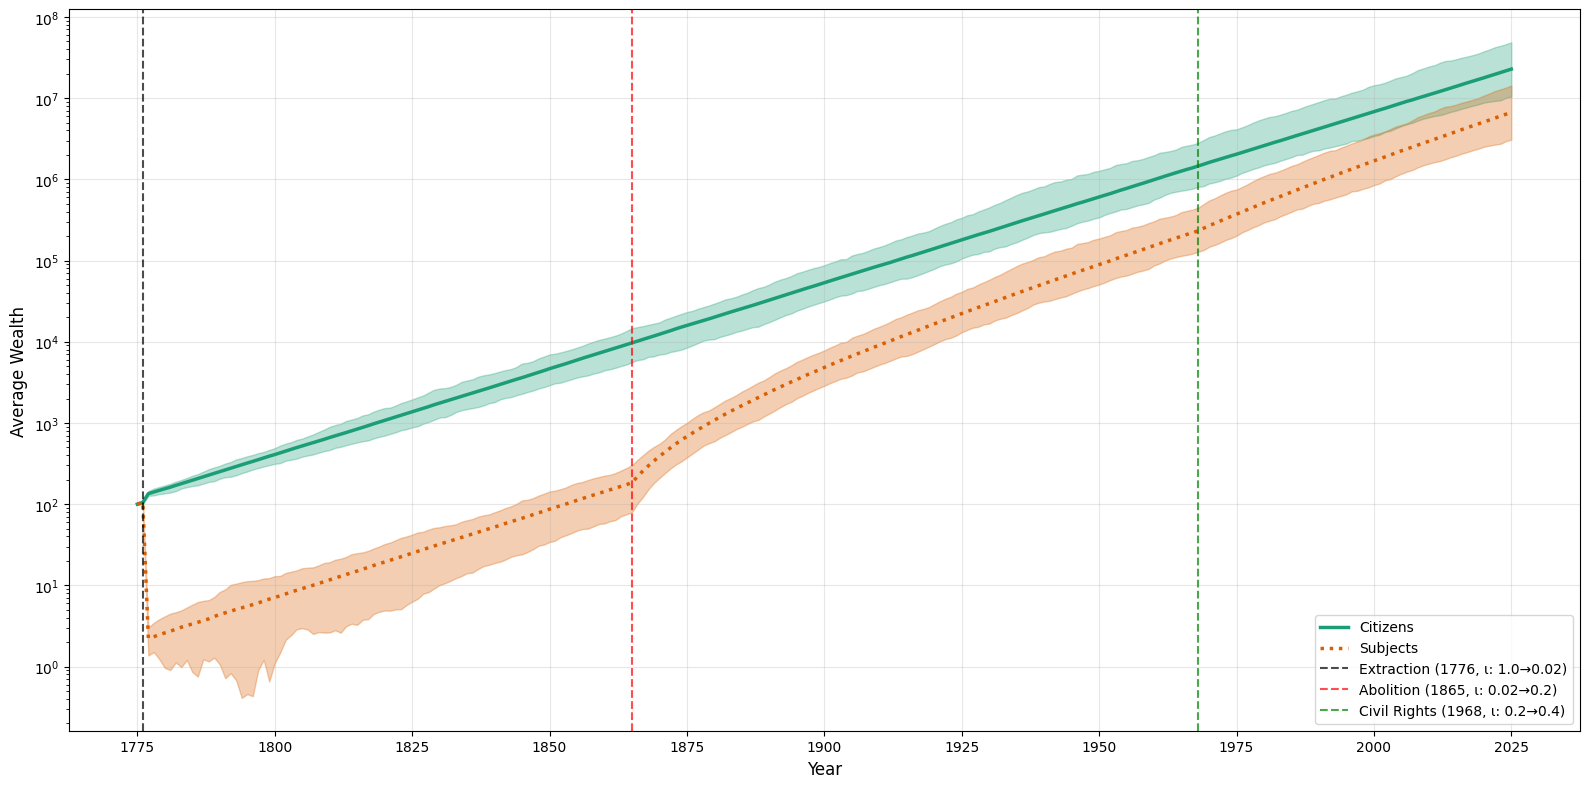

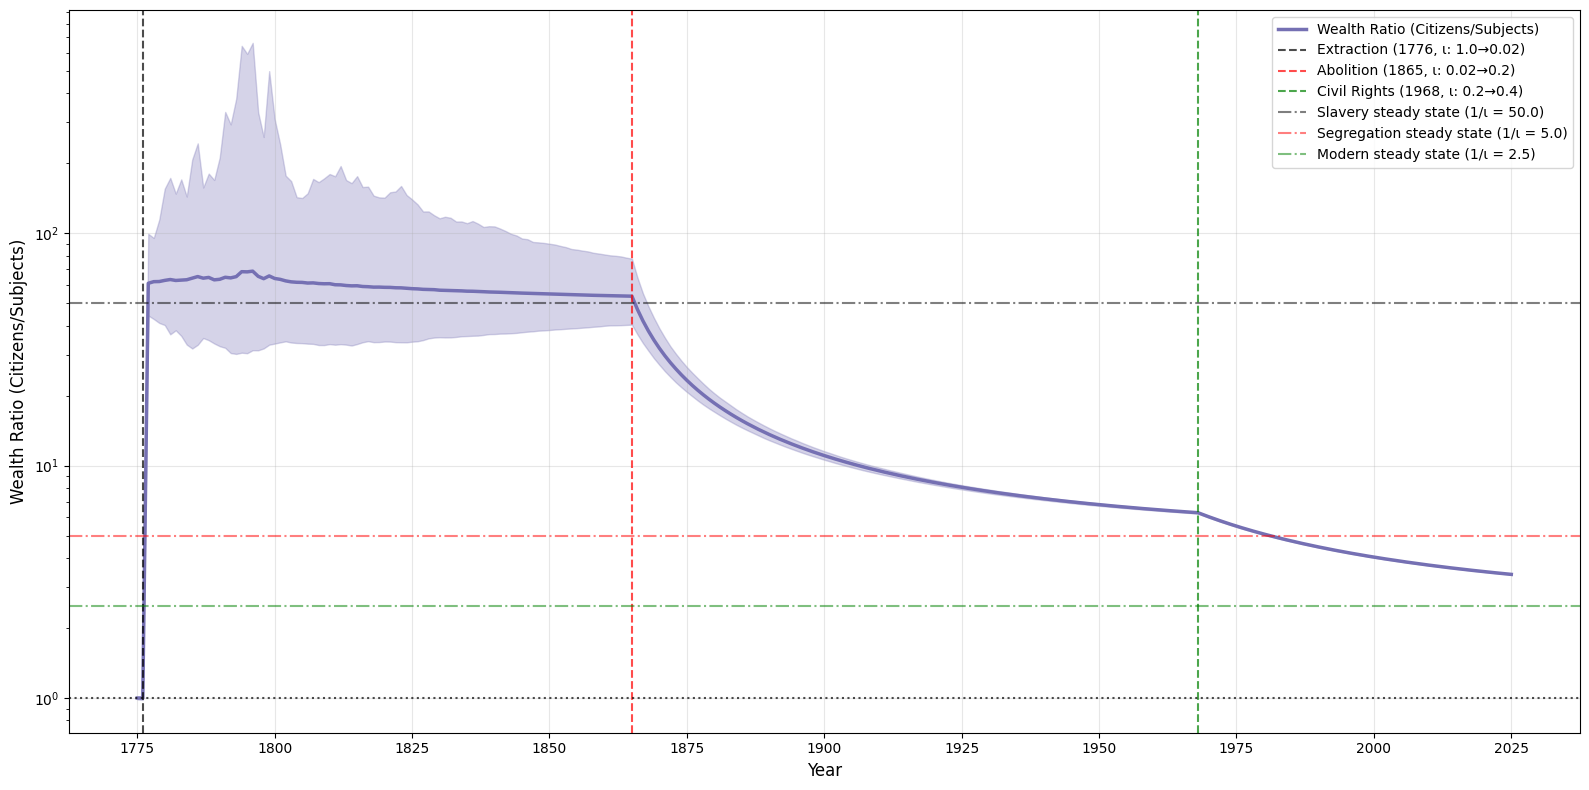

Historical Wealth Simulation (1775-2025):
- Number of agents: 10000
- Proportion of citizens (ρ): 0.82
- Extraction (1776): 98% of subjects' wealth
- Integration parameters:
  - Pre-extraction: ι = 1.0
  - Slavery (1776-1864): ι = 0.02
  - Segregation (1865-1967): ι = 0.2
  - Post-Civil Rights (1968-2025): ι = 0.4
- β (wealth retention): 0.985
- r (return on individual wealth): mean = 0.05, std = 0.02
- g (growth of social wealth): mean = 0.03, std = 0.01

Wealth Ratios at Key Points:
- 1775 (Initial): 1.00
- 1776 (Post-Extraction): 1.00
- 1865 (Abolition): 53.63
- 1968 (Civil Rights): 6.27
- 2025 (Present): 3.40

Theoretical Steady-State Ratios:
- Pre-extraction: 1/ι = 1.00
- Slavery period: 1/ι = 50.00
- Segregation period: 1/ι = 5.00
- Post-Civil Rights: 1/ι = 2.50

Convergence to Steady States:
- End of slavery period: 107.4% of theoretical
- End of segregation period: 125.9% of theoretical
- End of modern period: 136.2% of theoretical


In [33]:
import numpy as np
import matplotlib.pyplot as plt

# Historical timeline parameters
start_year = 1775
extraction_year = 1776
abolition_year = 1865
civil_rights_year = 1968
end_year = 2025

# Convert years to simulation time steps
n_timesteps = end_year - start_year + 1
extraction_step = extraction_year - start_year
abolition_step = abolition_year - start_year
civil_rights_step = civil_rights_year - start_year

# Simulation parameters
n_agents = 10000  # total number of agents
n_runs = 100  # number of simulation runs
initial_wealth_mean = 100  # average initial wealth
epsilon_sigma = 10  # standard deviation for random shocks
beta = 0.985  # fixed retention rate
rho = 0.82  # proportion of citizens in the population
lambda_extraction = 0.98  # extraction ratio (98%)

# Integration parameters for different historical periods
iota_pre_extraction = 1.0    # Before extraction (equal distribution)
iota_slavery = 0.02          # After extraction until abolition (1776-1865)
iota_segregation = 0.2       # After abolition until civil rights (1865-1968)
iota_post_civil_rights = 0.4 # After civil rights (1968-2025)

# Growth and return parameters
r_mean = 0.05  # 5% mean return on individual wealth
r_sigma = 0.02  # standard deviation for r
g_mean = 0.03  # 3% mean growth rate for social wealth
g_sigma = 0.01  # standard deviation for g

# Colorblind-friendly palette
colors = ['#1b9e77', '#d95f02', '#7570b3'] 

# Function to run a single simulation
def run_simulation(beta, lambda_extraction, n_runs, n_agents, n_timesteps,
                  initial_wealth_mean, epsilon_sigma, extraction_step, 
                  abolition_step, civil_rights_step, rho,
                  iota_pre_extraction, iota_slavery, iota_segregation, 
                  iota_post_civil_rights, r_mean, r_sigma, g_mean, g_sigma):
    # Arrays to store group wealth over time for all runs
    all_citizens_wealth = np.zeros((n_runs, n_timesteps))
    all_subjects_wealth = np.zeros((n_runs, n_timesteps))
    all_avg_wealth = np.zeros((n_runs, n_timesteps))
    all_wealth_ratios = np.zeros((n_runs, n_timesteps))
    
    for run in range(n_runs):
        # Initialize citizens and subjects with same initial wealth distribution
        n_citizens = int(n_agents * rho)
        n_subjects = n_agents - n_citizens
        
        # Initially give everyone the same average wealth (random around mean)
        wealth = np.random.lognormal(mean=np.log(initial_wealth_mean), sigma=0.2, size=n_agents)
        
        # Normalize to ensure overall average is exactly initial_wealth_mean
        wealth = wealth * (initial_wealth_mean / wealth.mean())
        
        # Keep track of group membership
        citizens_indices = np.arange(n_citizens)
        subjects_indices = np.arange(n_citizens, n_agents)
        
        # Arrays to store group wealth over time
        citizens_wealth = np.zeros(n_timesteps)
        subjects_wealth = np.zeros(n_timesteps)
        avg_wealth = np.zeros(n_timesteps)
        wealth_ratios = np.zeros(n_timesteps)
        
        for t in range(n_timesteps):
            # Record current group averages
            citizens_wealth[t] = wealth[citizens_indices].mean()
            subjects_wealth[t] = wealth[subjects_indices].mean()
            avg_wealth[t] = wealth.mean()
            wealth_ratios[t] = citizens_wealth[t] / subjects_wealth[t]
            
            # Extraction happens at the defined step
            if t == extraction_step:
                # Calculate total wealth extracted from subjects
                extracted_total = wealth[subjects_indices].sum() * lambda_extraction
                
                # Reduce subjects' wealth by extracted amount
                wealth[subjects_indices] = wealth[subjects_indices] * (1 - lambda_extraction)
                
                # Distribute extracted wealth equally among citizens
                wealth[citizens_indices] += extracted_total / n_citizens
            
            # Generate random returns for individual wealth
            r = np.random.normal(r_mean, r_sigma)
            
            # Generate random growth rate for social wealth
            g = np.random.normal(g_mean, g_sigma)
            
            # Generate random shocks
            epsilon_citizens = np.random.normal(0, epsilon_sigma, n_citizens)
            epsilon_subjects = np.random.normal(0, epsilon_sigma, n_subjects)
            epsilon = np.concatenate([epsilon_citizens, epsilon_subjects])
            
            # Calculate social pool as (1-beta) of everyone's wealth
            social_pool = (1 - beta) * wealth.sum()
            
            # Grow social pool at rate g
            social_pool = social_pool * (1 + g)
            
            # Retain beta proportion of individual wealth and apply returns
            wealth = beta * wealth * (1 + r)
            
            # Apply random shocks
            wealth = wealth + epsilon
            
            # Determine integration parameter based on historical period
            if t < extraction_step:
                current_iota = iota_pre_extraction
            elif t < abolition_step:
                current_iota = iota_slavery
            elif t < civil_rights_step:
                current_iota = iota_segregation
            else:
                current_iota = iota_post_civil_rights
                
            # Calculate shares based on current iota value
            total_shares = n_citizens + current_iota * n_subjects
            per_capita_citizen = social_pool / total_shares
            per_capita_subject = current_iota * (social_pool / total_shares)
            
            # Distribute social wealth
            wealth[citizens_indices] += per_capita_citizen
            wealth[subjects_indices] += per_capita_subject
        
        all_citizens_wealth[run] = citizens_wealth
        all_subjects_wealth[run] = subjects_wealth
        all_avg_wealth[run] = avg_wealth
        all_wealth_ratios[run] = wealth_ratios
    
    return all_citizens_wealth, all_subjects_wealth, all_avg_wealth, all_wealth_ratios

# Run the simulation
all_citizens_wealth, all_subjects_wealth, all_avg_wealth, all_wealth_ratios = run_simulation(
    beta, lambda_extraction, n_runs, n_agents, n_timesteps,
    initial_wealth_mean, epsilon_sigma, extraction_step,
    abolition_step, civil_rights_step, rho,
    iota_pre_extraction, iota_slavery, iota_segregation,
    iota_post_civil_rights, r_mean, r_sigma, g_mean, g_sigma
)

# Calculate mean, min, and max for each group across all runs
mean_citizens_wealth = np.mean(all_citizens_wealth, axis=0)
min_citizens_wealth = np.min(all_citizens_wealth, axis=0)
max_citizens_wealth = np.max(all_citizens_wealth, axis=0)

mean_subjects_wealth = np.mean(all_subjects_wealth, axis=0)
min_subjects_wealth = np.min(all_subjects_wealth, axis=0)
max_subjects_wealth = np.max(all_subjects_wealth, axis=0)

mean_wealth_ratio = np.mean(all_wealth_ratios, axis=0)
min_wealth_ratio = np.min(all_wealth_ratios, axis=0)
max_wealth_ratio = np.max(all_wealth_ratios, axis=0)

# Create year labels for x-axis (every 25 years)
years = np.arange(start_year, end_year + 1)
year_ticks = np.arange(start_year, end_year + 1, 25)
year_tick_positions = [year - start_year for year in year_ticks]

# Plot wealth over time
plt.figure(figsize=(16, 8))

# Plot Citizens with solid line
plt.plot(mean_citizens_wealth, 
         label='Citizens', 
         color=colors[0],
         linestyle='-',
         linewidth=2.5)

plt.fill_between(range(n_timesteps), 
                 min_citizens_wealth, 
                 max_citizens_wealth, 
                 color=colors[0], 
                 alpha=0.3)

# Plot Subjects with dotted line
plt.plot(mean_subjects_wealth, 
         label='Subjects', 
         color=colors[1],
         linestyle=':',
         linewidth=2.5)

plt.fill_between(range(n_timesteps), 
                 min_subjects_wealth, 
                 max_subjects_wealth, 
                 color=colors[1], 
                 alpha=0.3)

# Add vertical lines at historical events
plt.axvline(x=extraction_step, 
            color='black', 
            linestyle='--', 
            linewidth=1.5,
            alpha=0.7,
            label=f'Extraction (1776, ι: 1.0→0.02)')

plt.axvline(x=abolition_step, 
            color='red', 
            linestyle='--', 
            linewidth=1.5,
            alpha=0.7,
            label=f'Abolition (1865, ι: 0.02→0.2)')

plt.axvline(x=civil_rights_step, 
            color='green', 
            linestyle='--', 
            linewidth=1.5,
            alpha=0.7,
            label=f'Civil Rights (1968, ι: 0.2→0.4)')

# Set custom x-axis ticks to show actual years
plt.xticks(year_tick_positions, year_ticks)
plt.xlabel('Year', fontsize=12)
plt.ylabel('Average Wealth', fontsize=12)
plt.yscale('log')  # Using log scale to better show the differences
plt.grid(True, alpha=0.3)
plt.legend(loc='best', fontsize=10)
plt.tight_layout()
plt.show()

# Plot wealth ratio over time
plt.figure(figsize=(16, 8))

plt.plot(mean_wealth_ratio, 
         label=f'Wealth Ratio (Citizens/Subjects)', 
         color=colors[2],
         linewidth=2.5)

plt.fill_between(range(n_timesteps), 
                 min_wealth_ratio, 
                 max_wealth_ratio, 
                 color=colors[2], 
                 alpha=0.3)

# Add vertical lines at historical events
plt.axvline(x=extraction_step, 
            color='black', 
            linestyle='--', 
            linewidth=1.5,
            alpha=0.7,
            label=f'Extraction (1776, ι: 1.0→0.02)')

plt.axvline(x=abolition_step, 
            color='red', 
            linestyle='--', 
            linewidth=1.5,
            alpha=0.7,
            label=f'Abolition (1865, ι: 0.02→0.2)')

plt.axvline(x=civil_rights_step, 
            color='green', 
            linestyle='--', 
            linewidth=1.5,
            alpha=0.7,
            label=f'Civil Rights (1968, ι: 0.2→0.4)')

# Add horizontal lines showing theoretical steady-state ratios for each period
plt.axhline(y=1/iota_slavery, 
            color='black', 
            linestyle='-.', 
            alpha=0.5, 
            label=f'Slavery steady state (1/ι = {1/iota_slavery:.1f})')

plt.axhline(y=1/iota_segregation, 
            color='red', 
            linestyle='-.', 
            alpha=0.5, 
            label=f'Segregation steady state (1/ι = {1/iota_segregation:.1f})')

plt.axhline(y=1/iota_post_civil_rights, 
            color='green', 
            linestyle='-.', 
            alpha=0.5, 
            label=f'Modern steady state (1/ι = {1/iota_post_civil_rights:.1f})')

# Set custom x-axis ticks to show actual years
plt.xticks(year_tick_positions, year_ticks)
plt.xlabel('Year', fontsize=12)
plt.ylabel('Wealth Ratio (Citizens/Subjects)', fontsize=12)
plt.yscale('log')  # Using log scale to better show the differences
plt.grid(True, alpha=0.3)
plt.axhline(y=1, color='black', linestyle=':', alpha=0.7)
plt.legend(loc='best', fontsize=10)
plt.tight_layout()
plt.show()

# Calculate and print key statistics
print(f"Historical Wealth Simulation ({start_year}-{end_year}):")
print(f"- Number of agents: {n_agents}")
print(f"- Proportion of citizens (ρ): {rho}")
print(f"- Extraction ({extraction_year}): {lambda_extraction*100:.0f}% of subjects' wealth")
print(f"- Integration parameters:")
print(f"  - Pre-extraction: ι = {iota_pre_extraction}")
print(f"  - Slavery ({extraction_year}-{abolition_year-1}): ι = {iota_slavery}")
print(f"  - Segregation ({abolition_year}-{civil_rights_year-1}): ι = {iota_segregation}")
print(f"  - Post-Civil Rights ({civil_rights_year}-{end_year}): ι = {iota_post_civil_rights}")
print(f"- β (wealth retention): {beta}")
print(f"- r (return on individual wealth): mean = {r_mean}, std = {r_sigma}")
print(f"- g (growth of social wealth): mean = {g_mean}, std = {g_sigma}")

# Print wealth ratio at key historical points
print("\nWealth Ratios at Key Points:")
print(f"- {start_year} (Initial): {mean_wealth_ratio[0]:.2f}")
print(f"- {extraction_year} (Post-Extraction): {mean_wealth_ratio[extraction_step]:.2f}")
print(f"- {abolition_year} (Abolition): {mean_wealth_ratio[abolition_step]:.2f}")
print(f"- {civil_rights_year} (Civil Rights): {mean_wealth_ratio[civil_rights_step]:.2f}")
print(f"- {end_year} (Present): {mean_wealth_ratio[-1]:.2f}")

# Theoretical steady states
print("\nTheoretical Steady-State Ratios:")
print(f"- Pre-extraction: 1/ι = {1/iota_pre_extraction:.2f}")
print(f"- Slavery period: 1/ι = {1/iota_slavery:.2f}")
print(f"- Segregation period: 1/ι = {1/iota_segregation:.2f}")
print(f"- Post-Civil Rights: 1/ι = {1/iota_post_civil_rights:.2f}")

# Calculate convergence percentages for each period
if civil_rights_step < len(mean_wealth_ratio) - 20:  # Only if we have enough timesteps after civil rights
    # Calculate how close the end of each period got to its theoretical steady state
    slavery_end_ratio = mean_wealth_ratio[abolition_step-1]
    segregation_end_ratio = mean_wealth_ratio[civil_rights_step-1]
    modern_end_ratio = mean_wealth_ratio[-1]
    
    slavery_convergence = slavery_end_ratio / (1/iota_slavery) * 100
    segregation_convergence = segregation_end_ratio / (1/iota_segregation) * 100
    modern_convergence = modern_end_ratio / (1/iota_post_civil_rights) * 100
    
    print("\nConvergence to Steady States:")
    print(f"- End of slavery period: {slavery_convergence:.1f}% of theoretical")
    print(f"- End of segregation period: {segregation_convergence:.1f}% of theoretical")
    print(f"- End of modern period: {modern_convergence:.1f}% of theoretical")

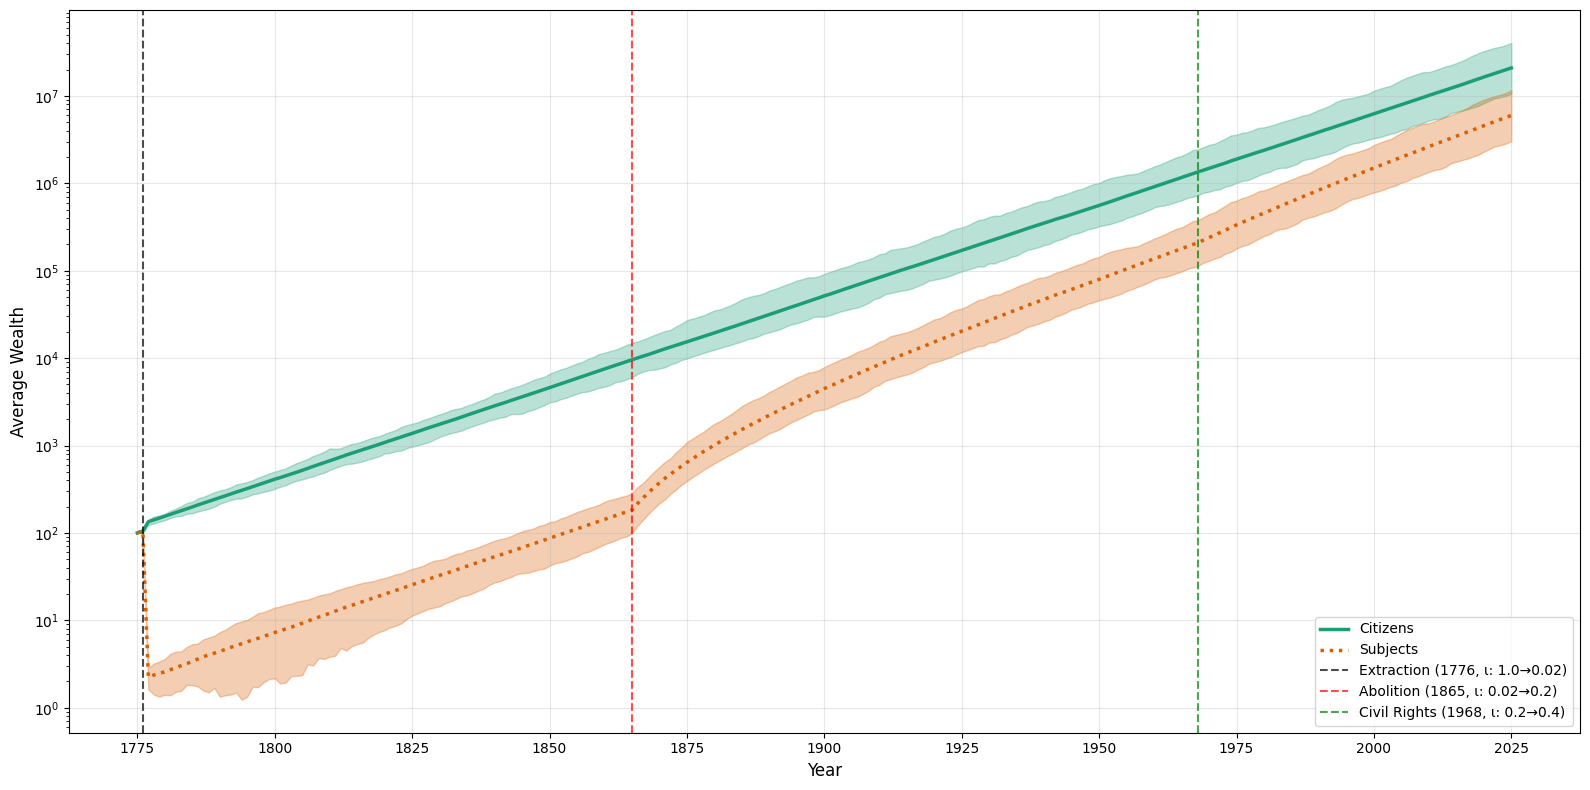

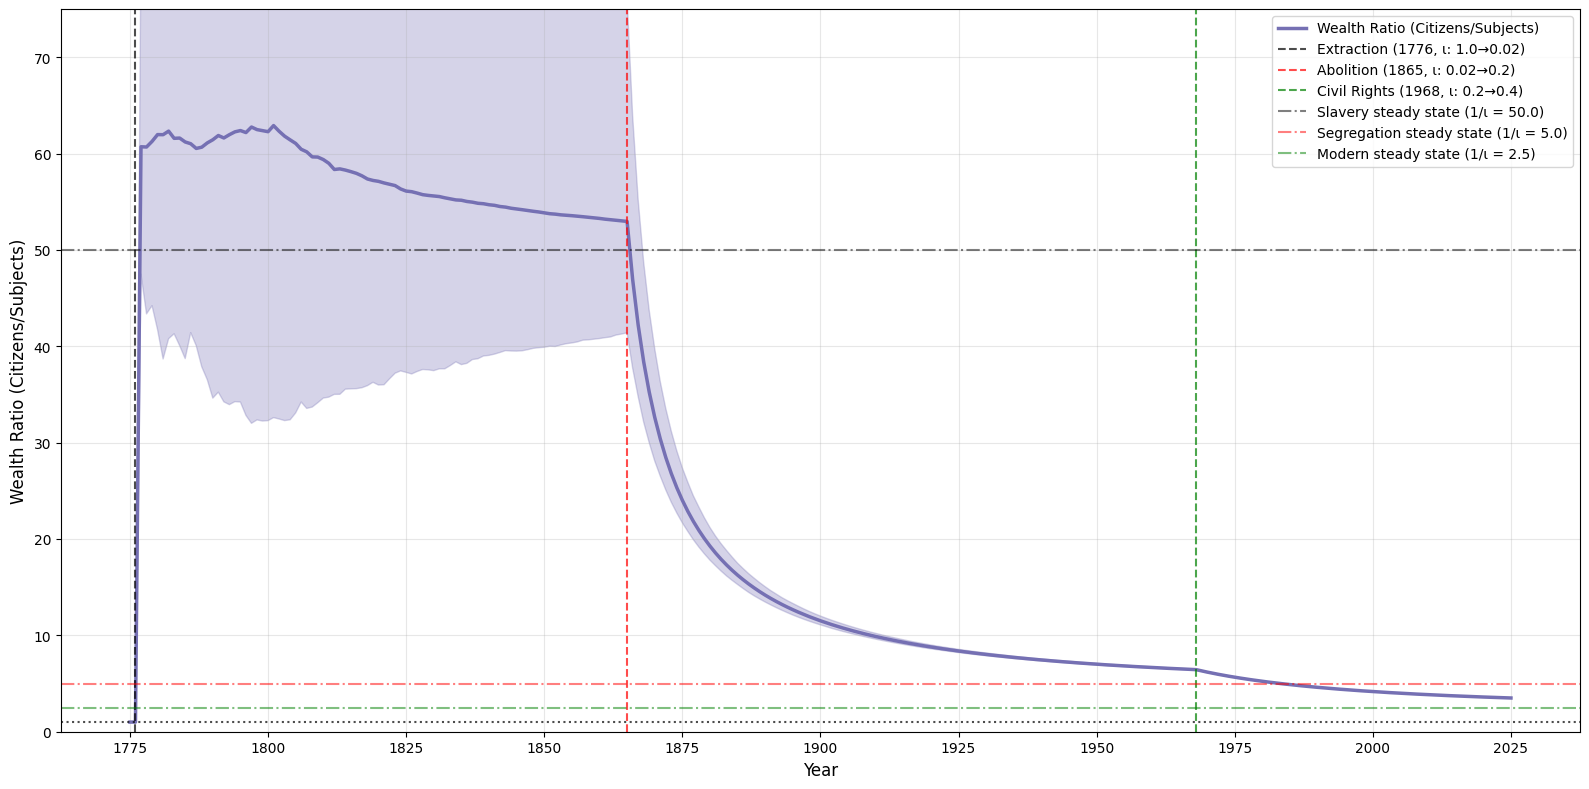

Historical Wealth Simulation (1775-2025):
- Number of agents: 10000
- Proportion of citizens (ρ): 0.82
- Extraction (1776): 98% of subjects' wealth
- Integration parameters:
  - Pre-extraction: ι = 1.0
  - Slavery (1776-1864): ι = 0.02
  - Segregation (1865-1967): ι = 0.2
  - Post-Civil Rights (1968-2025): ι = 0.4
- β (wealth retention): 0.986
- r (return on individual wealth): mean = 0.05, std = 0.02
- g (growth of social wealth): mean = 0.03, std = 0.01

Wealth Ratios at Key Points:
- 1775 (Initial): 1.00
- 1776 (Post-Extraction): 1.00
- 1865 (Abolition): 52.96
- 1968 (Civil Rights): 6.44
- 2025 (Present): 3.50

Theoretical Steady-State Ratios:
- Pre-extraction: 1/ι = 1.00
- Slavery period: 1/ι = 50.00
- Segregation period: 1/ι = 5.00
- Post-Civil Rights: 1/ι = 2.50

Convergence to Steady States:
- End of slavery period: 106.0% of theoretical
- End of segregation period: 129.4% of theoretical
- End of modern period: 140.0% of theoretical


In [37]:
import numpy as np
import matplotlib.pyplot as plt

# Historical timeline parameters
start_year = 1775
extraction_year = 1776
abolition_year = 1865
civil_rights_year = 1968
end_year = 2025

# Convert years to simulation time steps
n_timesteps = end_year - start_year + 1
extraction_step = extraction_year - start_year
abolition_step = abolition_year - start_year
civil_rights_step = civil_rights_year - start_year

# Simulation parameters
n_agents = 10000  # total number of agents
n_runs = 100  # number of simulation runs
initial_wealth_mean = 100  # average initial wealth
epsilon_sigma = 10  # standard deviation for random shocks
beta = 0.986  # fixed retention rate
rho = 0.82  # proportion of citizens in the population
lambda_extraction = 0.98  # extraction ratio (98%)

# Integration parameters for different historical periods
iota_pre_extraction = 1.0    # Before extraction (equal distribution)
iota_slavery = 0.02          # After extraction until abolition (1776-1865)
iota_segregation = 0.2       # After abolition until civil rights (1865-1968)
iota_post_civil_rights = 0.4 # After civil rights (1968-2025)

# Growth and return parameters
r_mean = 0.05  # 5% mean return on individual wealth
r_sigma = 0.02  # standard deviation for r
g_mean = 0.03  # 3% mean growth rate for social wealth
g_sigma = 0.01  # standard deviation for g

# Colorblind-friendly palette
colors = ['#1b9e77', '#d95f02', '#7570b3'] 

# Function to run a single simulation
def run_simulation(beta, lambda_extraction, n_runs, n_agents, n_timesteps,
                  initial_wealth_mean, epsilon_sigma, extraction_step, 
                  abolition_step, civil_rights_step, rho,
                  iota_pre_extraction, iota_slavery, iota_segregation, 
                  iota_post_civil_rights, r_mean, r_sigma, g_mean, g_sigma):
    # Arrays to store group wealth over time for all runs
    all_citizens_wealth = np.zeros((n_runs, n_timesteps))
    all_subjects_wealth = np.zeros((n_runs, n_timesteps))
    all_avg_wealth = np.zeros((n_runs, n_timesteps))
    all_wealth_ratios = np.zeros((n_runs, n_timesteps))
    
    for run in range(n_runs):
        # Initialize citizens and subjects with same initial wealth distribution
        n_citizens = int(n_agents * rho)
        n_subjects = n_agents - n_citizens
        
        # Initially give everyone the same average wealth (random around mean)
        wealth = np.random.lognormal(mean=np.log(initial_wealth_mean), sigma=0.2, size=n_agents)
        
        # Normalize to ensure overall average is exactly initial_wealth_mean
        wealth = wealth * (initial_wealth_mean / wealth.mean())
        
        # Keep track of group membership
        citizens_indices = np.arange(n_citizens)
        subjects_indices = np.arange(n_citizens, n_agents)
        
        # Arrays to store group wealth over time
        citizens_wealth = np.zeros(n_timesteps)
        subjects_wealth = np.zeros(n_timesteps)
        avg_wealth = np.zeros(n_timesteps)
        wealth_ratios = np.zeros(n_timesteps)
        
        for t in range(n_timesteps):
            # Record current group averages
            citizens_wealth[t] = wealth[citizens_indices].mean()
            subjects_wealth[t] = wealth[subjects_indices].mean()
            avg_wealth[t] = wealth.mean()
            wealth_ratios[t] = citizens_wealth[t] / subjects_wealth[t]
            
            # Extraction happens at the defined step
            if t == extraction_step:
                # Calculate total wealth extracted from subjects
                extracted_total = wealth[subjects_indices].sum() * lambda_extraction
                
                # Reduce subjects' wealth by extracted amount
                wealth[subjects_indices] = wealth[subjects_indices] * (1 - lambda_extraction)
                
                # Distribute extracted wealth equally among citizens
                wealth[citizens_indices] += extracted_total / n_citizens
            
            # Generate random returns for individual wealth
            r = np.random.normal(r_mean, r_sigma)
            
            # Generate random growth rate for social wealth
            g = np.random.normal(g_mean, g_sigma)
            
            # Generate random shocks
            epsilon_citizens = np.random.normal(0, epsilon_sigma, n_citizens)
            epsilon_subjects = np.random.normal(0, epsilon_sigma, n_subjects)
            epsilon = np.concatenate([epsilon_citizens, epsilon_subjects])
            
            # Calculate social pool as (1-beta) of everyone's wealth
            social_pool = (1 - beta) * wealth.sum()
            
            # Grow social pool at rate g
            social_pool = social_pool * (1 + g)
            
            # Retain beta proportion of individual wealth and apply returns
            wealth = beta * wealth * (1 + r)
            
            # Apply random shocks
            wealth = wealth + epsilon
            
            # Determine integration parameter based on historical period
            if t < extraction_step:
                current_iota = iota_pre_extraction
            elif t < abolition_step:
                current_iota = iota_slavery
            elif t < civil_rights_step:
                current_iota = iota_segregation
            else:
                current_iota = iota_post_civil_rights
                
            # Calculate shares based on current iota value
            total_shares = n_citizens + current_iota * n_subjects
            per_capita_citizen = social_pool / total_shares
            per_capita_subject = current_iota * (social_pool / total_shares)
            
            # Distribute social wealth
            wealth[citizens_indices] += per_capita_citizen
            wealth[subjects_indices] += per_capita_subject
        
        all_citizens_wealth[run] = citizens_wealth
        all_subjects_wealth[run] = subjects_wealth
        all_avg_wealth[run] = avg_wealth
        all_wealth_ratios[run] = wealth_ratios
    
    return all_citizens_wealth, all_subjects_wealth, all_avg_wealth, all_wealth_ratios

# Run the simulation
all_citizens_wealth, all_subjects_wealth, all_avg_wealth, all_wealth_ratios = run_simulation(
    beta, lambda_extraction, n_runs, n_agents, n_timesteps,
    initial_wealth_mean, epsilon_sigma, extraction_step,
    abolition_step, civil_rights_step, rho,
    iota_pre_extraction, iota_slavery, iota_segregation,
    iota_post_civil_rights, r_mean, r_sigma, g_mean, g_sigma
)

# Calculate mean, min, and max for each group across all runs
mean_citizens_wealth = np.mean(all_citizens_wealth, axis=0)
min_citizens_wealth = np.min(all_citizens_wealth, axis=0)
max_citizens_wealth = np.max(all_citizens_wealth, axis=0)

mean_subjects_wealth = np.mean(all_subjects_wealth, axis=0)
min_subjects_wealth = np.min(all_subjects_wealth, axis=0)
max_subjects_wealth = np.max(all_subjects_wealth, axis=0)

mean_wealth_ratio = np.mean(all_wealth_ratios, axis=0)
min_wealth_ratio = np.min(all_wealth_ratios, axis=0)
max_wealth_ratio = np.max(all_wealth_ratios, axis=0)

# Create year labels for x-axis (every 25 years)
years = np.arange(start_year, end_year + 1)
year_ticks = np.arange(start_year, end_year + 1, 25)
year_tick_positions = [year - start_year for year in year_ticks]

# Plot wealth over time
plt.figure(figsize=(16, 8))

# Plot Citizens with solid line
plt.plot(mean_citizens_wealth, 
         label='Citizens', 
         color=colors[0],
         linestyle='-',
         linewidth=2.5)

plt.fill_between(range(n_timesteps), 
                 min_citizens_wealth, 
                 max_citizens_wealth, 
                 color=colors[0], 
                 alpha=0.3)

# Plot Subjects with dotted line
plt.plot(mean_subjects_wealth, 
         label='Subjects', 
         color=colors[1],
         linestyle=':',
         linewidth=2.5)

plt.fill_between(range(n_timesteps), 
                 min_subjects_wealth, 
                 max_subjects_wealth, 
                 color=colors[1], 
                 alpha=0.3)

# Add vertical lines at historical events
plt.axvline(x=extraction_step, 
            color='black', 
            linestyle='--', 
            linewidth=1.5,
            alpha=0.7,
            label=f'Extraction (1776, ι: 1.0→0.02)')

plt.axvline(x=abolition_step, 
            color='red', 
            linestyle='--', 
            linewidth=1.5,
            alpha=0.7,
            label=f'Abolition (1865, ι: 0.02→0.2)')

plt.axvline(x=civil_rights_step, 
            color='green', 
            linestyle='--', 
            linewidth=1.5,
            alpha=0.7,
            label=f'Civil Rights (1968, ι: 0.2→0.4)')

# Set custom x-axis ticks to show actual years
plt.xticks(year_tick_positions, year_ticks)
plt.xlabel('Year', fontsize=12)
plt.ylabel('Average Wealth', fontsize=12)
plt.yscale('log')  # Using log scale to better show the differences
plt.grid(True, alpha=0.3)
plt.legend(loc='best', fontsize=10)
plt.tight_layout()
plt.show()

# Plot wealth ratio over time
plt.figure(figsize=(16, 8))

plt.plot(mean_wealth_ratio, 
         label=f'Wealth Ratio (Citizens/Subjects)', 
         color=colors[2],
         linewidth=2.5)

plt.fill_between(range(n_timesteps), 
                 min_wealth_ratio, 
                 max_wealth_ratio, 
                 color=colors[2], 
                 alpha=0.3)

# Add vertical lines at historical events
plt.axvline(x=extraction_step, 
            color='black', 
            linestyle='--', 
            linewidth=1.5,
            alpha=0.7,
            label=f'Extraction (1776, ι: 1.0→0.02)')

plt.axvline(x=abolition_step, 
            color='red', 
            linestyle='--', 
            linewidth=1.5,
            alpha=0.7,
            label=f'Abolition (1865, ι: 0.02→0.2)')

plt.axvline(x=civil_rights_step, 
            color='green', 
            linestyle='--', 
            linewidth=1.5,
            alpha=0.7,
            label=f'Civil Rights (1968, ι: 0.2→0.4)')

# Add horizontal lines showing theoretical steady-state ratios for each period
plt.axhline(y=1/iota_slavery, 
            color='black', 
            linestyle='-.', 
            alpha=0.5, 
            label=f'Slavery steady state (1/ι = {1/iota_slavery:.1f})')

plt.axhline(y=1/iota_segregation, 
            color='red', 
            linestyle='-.', 
            alpha=0.5, 
            label=f'Segregation steady state (1/ι = {1/iota_segregation:.1f})')

plt.axhline(y=1/iota_post_civil_rights, 
            color='green', 
            linestyle='-.', 
            alpha=0.5, 
            label=f'Modern steady state (1/ι = {1/iota_post_civil_rights:.1f})')

# Set custom x-axis ticks to show actual years
plt.xticks(year_tick_positions, year_ticks)
plt.xlabel('Year', fontsize=12)
plt.ylabel('Wealth Ratio (Citizens/Subjects)', fontsize=12)
# plt.yscale('log')  # Removing the log scale as requested
plt.ylim(0, 75)  # Setting y-axis limits from 0 to 75
plt.grid(True, alpha=0.3)
plt.axhline(y=1, color='black', linestyle=':', alpha=0.7)
plt.legend(loc='best', fontsize=10)
plt.tight_layout()
plt.show()

# Calculate and print key statistics
print(f"Historical Wealth Simulation ({start_year}-{end_year}):")
print(f"- Number of agents: {n_agents}")
print(f"- Proportion of citizens (ρ): {rho}")
print(f"- Extraction ({extraction_year}): {lambda_extraction*100:.0f}% of subjects' wealth")
print(f"- Integration parameters:")
print(f"  - Pre-extraction: ι = {iota_pre_extraction}")
print(f"  - Slavery ({extraction_year}-{abolition_year-1}): ι = {iota_slavery}")
print(f"  - Segregation ({abolition_year}-{civil_rights_year-1}): ι = {iota_segregation}")
print(f"  - Post-Civil Rights ({civil_rights_year}-{end_year}): ι = {iota_post_civil_rights}")
print(f"- β (wealth retention): {beta}")
print(f"- r (return on individual wealth): mean = {r_mean}, std = {r_sigma}")
print(f"- g (growth of social wealth): mean = {g_mean}, std = {g_sigma}")

# Print wealth ratio at key historical points
print("\nWealth Ratios at Key Points:")
print(f"- {start_year} (Initial): {mean_wealth_ratio[0]:.2f}")
print(f"- {extraction_year} (Post-Extraction): {mean_wealth_ratio[extraction_step]:.2f}")
print(f"- {abolition_year} (Abolition): {mean_wealth_ratio[abolition_step]:.2f}")
print(f"- {civil_rights_year} (Civil Rights): {mean_wealth_ratio[civil_rights_step]:.2f}")
print(f"- {end_year} (Present): {mean_wealth_ratio[-1]:.2f}")

# Theoretical steady states
print("\nTheoretical Steady-State Ratios:")
print(f"- Pre-extraction: 1/ι = {1/iota_pre_extraction:.2f}")
print(f"- Slavery period: 1/ι = {1/iota_slavery:.2f}")
print(f"- Segregation period: 1/ι = {1/iota_segregation:.2f}")
print(f"- Post-Civil Rights: 1/ι = {1/iota_post_civil_rights:.2f}")

# Calculate convergence percentages for each period
if civil_rights_step < len(mean_wealth_ratio) - 20:  # Only if we have enough timesteps after civil rights
    # Calculate how close the end of each period got to its theoretical steady state
    slavery_end_ratio = mean_wealth_ratio[abolition_step-1]
    segregation_end_ratio = mean_wealth_ratio[civil_rights_step-1]
    modern_end_ratio = mean_wealth_ratio[-1]
    
    slavery_convergence = slavery_end_ratio / (1/iota_slavery) * 100
    segregation_convergence = segregation_end_ratio / (1/iota_segregation) * 100
    modern_convergence = modern_end_ratio / (1/iota_post_civil_rights) * 100
    
    print("\nConvergence to Steady States:")
    print(f"- End of slavery period: {slavery_convergence:.1f}% of theoretical")
    print(f"- End of segregation period: {segregation_convergence:.1f}% of theoretical")
    print(f"- End of modern period: {modern_convergence:.1f}% of theoretical")